# Probabilistic and Structured Surrogates for Cell Migration

This notebook develops and evaluates probabilistic neural surrogates for a phenotype-aware mechanistic model of cell migration under interstitial flow. It contains a probabilistic multilayer perceptron, a structured phenotype-transition model, a history-based transformer, a learned short-range pair-force model, and a physics-constrained hybrid model for stable long rollouts.

**Scientific scope.** Training and trajectory-level validation use synthetic data generated by the mechanistic simulator. Published aggregate experimental observables motivate and calibrate the underlying mechanistic model; the original experimental trajectories are not used here.

**Recommended use.** The probabilistic MLP is used for one-step prediction, the transformer for history-based forecasting, and the structured hybrid model for recursive colony simulation. The unconstrained MLP is not recommended for long rollouts because small velocity bias compounds over time.


In [1]:
# Phenotype-Aware Probabilistic Surrogate Model
#
# Stage 1: Probabilistic MLP surrogate
# Stage 2: Mechanistic-versus-surrogate validation
# Stage 3: Transformer surrogate

import numpy as np
import matplotlib.pyplot as plt
import time

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

# Reproducibility
np.random.seed(51000)
torch.manual_seed(51000)

# Use GPU when available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("NumPy version:", np.__version__)
print("PyTorch version:", torch.__version__)
print("Device:", device)

NumPy version: 1.26.4
PyTorch version: 2.2.2
Device: cpu


In [2]:
# Frozen mechanistic-model parameters

dt = 0.05
D = 0.25

# Phenotype-dependent persistence times
tau_amoeboid = 0.50
tau_mesenchymal = 12.0

# Mesenchymal speed scale
v_mesenchymal = 1.0

# Amoeboid cells move faster
amoeboid_speed_multiplier = 2.20
v_amoeboid = (
    amoeboid_speed_multiplier * v_mesenchymal
)

# Phenotype-switching rates
# A = amoeboid, M = mesenchymal

k_am_no_flow = 0.14653923223001136
k_ma_no_flow = 0.10346076776998864

k_am_flow = 0.06759328680181888
k_ma_flow = 0.18240671319818114

print("dt:", dt)
print("D:", D)

print(
    "Persistence times:",
    tau_amoeboid,
    tau_mesenchymal
)

print(
    "Speed scales:",
    v_amoeboid,
    v_mesenchymal
)

print(
    "No-flow equilibrium mesenchymal fraction:",
    k_am_no_flow
    / (k_am_no_flow + k_ma_no_flow)
)

print(
    "Flow equilibrium mesenchymal fraction:",
    k_am_flow
    / (k_am_flow + k_ma_flow)
)

dt: 0.05
D: 0.25
Persistence times: 0.5 12.0
Speed scales: 2.2 1.0
No-flow equilibrium mesenchymal fraction: 0.5861569289200455
Flow equilibrium mesenchymal fraction: 0.2703731472072755


In [3]:
def mechanistic_transition(
    velocity,
    phenotype,
    flow_condition,
    rng
):
    """
    Advance one cell by one time step.

    Parameters
    ----------
    velocity : array with shape (2,)
        Current [vx, vy].

    phenotype : int
        0 = amoeboid
        1 = mesenchymal

    flow_condition : int
        0 = no flow
        1 = flow

    rng : NumPy random generator

    Returns
    -------
    displacement : array with shape (2,)
        Position change during one time step.

    next_velocity : array with shape (2,)
        Active velocity after one time step.

    next_phenotype : int
        Phenotype after stochastic switching.
    """

    velocity = np.asarray(
        velocity,
        dtype=float
    )

    # Select phenotype-switching rates
    if flow_condition == 0:
        k_am = k_am_no_flow
        k_ma = k_ma_no_flow
    else:
        k_am = k_am_flow
        k_ma = k_ma_flow

    # Stochastic phenotype transition
    next_phenotype = int(phenotype)

    if phenotype == 0:
        # Amoeboid -> mesenchymal
        if rng.random() < k_am * dt:
            next_phenotype = 1
    else:
        # Mesenchymal -> amoeboid
        if rng.random() < k_ma * dt:
            next_phenotype = 0

    # Use the phenotype present during the new interval
    if next_phenotype == 0:
        tau = tau_amoeboid
        speed = v_amoeboid
    else:
        tau = tau_mesenchymal
        speed = v_mesenchymal

    # Active velocity noise
    velocity_noise = rng.normal(size=2)

    next_velocity = (
        velocity
        - (velocity / tau) * dt
        + speed
        * np.sqrt(2.0 * dt / tau)
        * velocity_noise
    )

    # Independent translational noise
    position_noise = rng.normal(size=2)

    displacement = (
        next_velocity * dt
        + np.sqrt(2.0 * D * dt)
        * position_noise
    )

    return (
        displacement,
        next_velocity,
        next_phenotype
    )

In [4]:
test_rng = np.random.default_rng(51001)

test_velocity = np.array([1.0, -0.5])

for phenotype in [0, 1]:
    for flow_condition in [0, 1]:

        displacement, next_velocity, next_phenotype = (
            mechanistic_transition(
                velocity=test_velocity,
                phenotype=phenotype,
                flow_condition=flow_condition,
                rng=test_rng
            )
        )

        print(
            "Phenotype:",
            phenotype,
            "| Flow:",
            flow_condition
        )

        print("Displacement:", displacement)
        print("Next velocity:", next_velocity)
        print("Next phenotype:", next_phenotype)
        print()

Phenotype: 0 | Flow: 0
Displacement: [-0.11809609 -0.02814791]
Next velocity: [0.60996193 0.70671746]
Next phenotype: 0

Phenotype: 0 | Flow: 1
Displacement: [-0.12814548 -0.13802985]
Next velocity: [ 0.50543342 -2.25687811]
Next phenotype: 0

Phenotype: 1 | Flow: 0
Displacement: [0.04780995 0.07186412]
Next velocity: [ 0.8251279  -0.43981258]
Next phenotype: 1

Phenotype: 1 | Flow: 1
Displacement: [-0.10426099  0.20158888]
Next velocity: [ 0.9966536  -0.41699424]
Next phenotype: 1



In [5]:
def generate_surrogate_dataset(
    n_trajectories,
    steps_per_trajectory,
    seed
):
    rng = np.random.default_rng(seed)

    all_inputs = []
    all_targets = []
    all_next_phenotypes = []
    all_trajectory_ids = []

    for trajectory_id in range(n_trajectories):

        # Assign one flow condition to the complete trajectory
        flow_condition = int(
            rng.integers(0, 2)
        )

        # Balanced initial phenotype
        phenotype = int(
            rng.integers(0, 2)
        )

        # Random initial active velocity
        velocity = rng.normal(
            loc=0.0,
            scale=1.5,
            size=2
        )

        for step in range(steps_per_trajectory):

            current_velocity = velocity.copy()
            current_phenotype = phenotype

            (
                displacement,
                next_velocity,
                next_phenotype
            ) = mechanistic_transition(
                velocity=current_velocity,
                phenotype=current_phenotype,
                flow_condition=flow_condition,
                rng=rng
            )

            # MLP inputs:
            # vx, vy, phenotype, flow condition
            model_input = np.array([
                current_velocity[0],
                current_velocity[1],
                current_phenotype,
                flow_condition
            ])

            # Continuous targets:
            # dx, dy, next vx, next vy
            model_target = np.array([
                displacement[0],
                displacement[1],
                next_velocity[0],
                next_velocity[1]
            ])

            all_inputs.append(model_input)
            all_targets.append(model_target)
            all_next_phenotypes.append(
                next_phenotype
            )
            all_trajectory_ids.append(
                trajectory_id
            )

            # Continue the trajectory
            velocity = next_velocity
            phenotype = next_phenotype

    return (
        np.asarray(all_inputs, dtype=np.float32),
        np.asarray(all_targets, dtype=np.float32),
        np.asarray(
            all_next_phenotypes,
            dtype=np.int64
        ),
        np.asarray(
            all_trajectory_ids,
            dtype=np.int64
        )
    )

In [6]:
(
    surrogate_inputs,
    surrogate_targets,
    surrogate_next_phenotypes,
    surrogate_trajectory_ids
) = generate_surrogate_dataset(
    n_trajectories=600,
    steps_per_trajectory=100,
    seed=51002
)

print(
    "Input shape:",
    surrogate_inputs.shape
)

print(
    "Continuous-target shape:",
    surrogate_targets.shape
)

print(
    "Phenotype-target shape:",
    surrogate_next_phenotypes.shape
)

print(
    "Number of trajectories:",
    len(np.unique(surrogate_trajectory_ids))
)

print(
    "No-flow transitions:",
    np.sum(surrogate_inputs[:, 3] == 0)
)

print(
    "Flow transitions:",
    np.sum(surrogate_inputs[:, 3] == 1)
)

print(
    "Amoeboid input states:",
    np.sum(surrogate_inputs[:, 2] == 0)
)

print(
    "Mesenchymal input states:",
    np.sum(surrogate_inputs[:, 2] == 1)
)

print(
    "All values finite:",
    np.isfinite(surrogate_inputs).all()
    and np.isfinite(surrogate_targets).all()
)

Input shape: (60000, 4)
Continuous-target shape: (60000, 4)
Phenotype-target shape: (60000,)
Number of trajectories: 600
No-flow transitions: 29900
Flow transitions: 30100
Amoeboid input states: 30575
Mesenchymal input states: 29425
All values finite: True


In [7]:
# Split complete trajectories, not individual rows

split_rng = np.random.default_rng(51003)

unique_trajectory_ids = np.unique(
    surrogate_trajectory_ids
)

split_rng.shuffle(unique_trajectory_ids)

n_total_trajectories = len(
    unique_trajectory_ids
)

n_train_trajectories = int(
    0.70 * n_total_trajectories
)

n_validation_trajectories = int(
    0.15 * n_total_trajectories
)

train_trajectory_ids = unique_trajectory_ids[
    :n_train_trajectories
]

validation_trajectory_ids = unique_trajectory_ids[
    n_train_trajectories:
    n_train_trajectories
    + n_validation_trajectories
]

test_trajectory_ids = unique_trajectory_ids[
    n_train_trajectories
    + n_validation_trajectories:
]

train_mask = np.isin(
    surrogate_trajectory_ids,
    train_trajectory_ids
)

validation_mask = np.isin(
    surrogate_trajectory_ids,
    validation_trajectory_ids
)

test_mask = np.isin(
    surrogate_trajectory_ids,
    test_trajectory_ids
)

X_train = surrogate_inputs[train_mask]
Y_train = surrogate_targets[train_mask]

X_validation = surrogate_inputs[validation_mask]
Y_validation = surrogate_targets[validation_mask]

X_test = surrogate_inputs[test_mask]
Y_test = surrogate_targets[test_mask]

phenotype_train = (
    surrogate_next_phenotypes[train_mask]
)

phenotype_validation = (
    surrogate_next_phenotypes[validation_mask]
)

phenotype_test = (
    surrogate_next_phenotypes[test_mask]
)

print("Train trajectories:", len(train_trajectory_ids))
print(
    "Validation trajectories:",
    len(validation_trajectory_ids)
)
print("Test trajectories:", len(test_trajectory_ids))

print("Training samples:", X_train.shape)
print("Validation samples:", X_validation.shape)
print("Test samples:", X_test.shape)

print(
    "Trajectory overlap:",
    len(
        set(train_trajectory_ids)
        & set(validation_trajectory_ids)
    ),
    len(
        set(train_trajectory_ids)
        & set(test_trajectory_ids)
    ),
    len(
        set(validation_trajectory_ids)
        & set(test_trajectory_ids)
    )
)

Train trajectories: 420
Validation trajectories: 90
Test trajectories: 90
Training samples: (42000, 4)
Validation samples: (9000, 4)
Test samples: (9000, 4)
Trajectory overlap: 0 0 0


In [8]:
velocity_input_mean = X_train[:, :2].mean(axis=0)

In [10]:
# Calculate normalization statistics from training data only

velocity_input_mean = X_train[:, :2].mean(axis=0)
velocity_input_std = X_train[:, :2].std(axis=0)

velocity_input_std = np.maximum(
    velocity_input_std,
    1e-6
)

target_mean = Y_train.mean(axis=0)
target_std = Y_train.std(axis=0)

target_std = np.maximum(
    target_std,
    1e-6
)


def normalize_inputs(X):
    X_normalized = X.copy()

    X_normalized[:, :2] = (
        X_normalized[:, :2]
        - velocity_input_mean
    ) / velocity_input_std

    # Columns 2 and 3 remain binary:
    # phenotype and flow condition
    return X_normalized


def normalize_targets(Y):
    return (
        Y - target_mean
    ) / target_std


# Apply normalization

X_train_normalized = normalize_inputs(
    X_train
)

X_validation_normalized = normalize_inputs(
    X_validation
)

X_test_normalized = normalize_inputs(
    X_test
)

Y_train_normalized = normalize_targets(
    Y_train
)

Y_validation_normalized = normalize_targets(
    Y_validation
)

Y_test_normalized = normalize_targets(
    Y_test
)


# Check the results

print(
    "Velocity input mean:",
    velocity_input_mean
)

print(
    "Velocity input SD:",
    velocity_input_std
)

print(
    "Target mean:",
    target_mean
)

print(
    "Target SD:",
    target_std
)

print(
    "Normalized training-input velocity mean:",
    X_train_normalized[:, :2].mean(axis=0)
)

print(
    "Normalized training-target mean:",
    Y_train_normalized.mean(axis=0)
)

print(
    "Normalized training-target SD:",
    Y_train_normalized.std(axis=0)
)

Velocity input mean: [ 0.027452   -0.05324797]
Velocity input SD: [1.8636626 1.8978474]
Target mean: [ 0.00091075 -0.0034418   0.02838788 -0.05247756]
Target SD: [0.18275255 0.1844954  1.8677152  1.9022957 ]
Normalized training-input velocity mean: [3.6675306e-08 5.7271549e-08]
Normalized training-target mean: [-3.9848366e-08 -9.2018215e-09  7.6388766e-08  9.5094954e-08]
Normalized training-target SD: [1.0000001 1.0000012 1.0000011 1.0000007]


In [11]:
class TransitionDataset(Dataset):

    def __init__(
        self,
        inputs,
        targets,
        next_phenotypes
    ):
        self.inputs = torch.tensor(
            inputs,
            dtype=torch.float32
        )

        self.targets = torch.tensor(
            targets,
            dtype=torch.float32
        )

        self.next_phenotypes = torch.tensor(
            next_phenotypes,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, index):
        return (
            self.inputs[index],
            self.targets[index],
            self.next_phenotypes[index]
        )

In [12]:
train_dataset = TransitionDataset(
    X_train_normalized,
    Y_train_normalized,
    phenotype_train
)

validation_dataset = TransitionDataset(
    X_validation_normalized,
    Y_validation_normalized,
    phenotype_validation
)

test_dataset = TransitionDataset(
    X_test_normalized,
    Y_test_normalized,
    phenotype_test
)

In [13]:
batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [14]:
batch_inputs, batch_targets, batch_phenotypes = (
    next(iter(train_loader))
)

print("Batch input shape:", batch_inputs.shape)
print("Batch target shape:", batch_targets.shape)

print(
    "Batch phenotype shape:",
    batch_phenotypes.shape
)

print(
    "First normalized input:",
    batch_inputs[0]
)

print(
    "First normalized target:",
    batch_targets[0]
)

print(
    "First next-phenotype target:",
    batch_phenotypes[0]
)

Batch input shape: torch.Size([256, 4])
Batch target shape: torch.Size([256, 4])
Batch phenotype shape: torch.Size([256])
First normalized input: tensor([-1.2617,  0.7270,  1.0000,  1.0000])
First normalized target: tensor([-0.7950, -0.6133, -1.2689,  0.6807])
First next-phenotype target: tensor(1.)


In [15]:
class ProbabilisticSurrogateMLP(nn.Module):

    def __init__(
        self,
        input_dimension=4,
        hidden_dimension=64,
        output_dimension=4
    ):
        super().__init__()

        self.shared_network = nn.Sequential(
            nn.Linear(
                input_dimension,
                hidden_dimension
            ),
            nn.SiLU(),

            nn.Linear(
                hidden_dimension,
                hidden_dimension
            ),
            nn.SiLU()
        )

        # Mean of:
        # dx, dy, next vx, next vy
        self.mean_head = nn.Linear(
            hidden_dimension,
            output_dimension
        )

        # Log variance of the same four outputs
        self.log_variance_head = nn.Linear(
            hidden_dimension,
            output_dimension
        )

        # Probability that the next phenotype is mesenchymal
        self.phenotype_head = nn.Linear(
            hidden_dimension,
            1
        )

    def forward(self, model_input):

        hidden_state = self.shared_network(
            model_input
        )

        predicted_mean = self.mean_head(
            hidden_state
        )

        predicted_log_variance = (
            self.log_variance_head(
                hidden_state
            )
        )

        # Prevent numerical instability
        predicted_log_variance = torch.clamp(
            predicted_log_variance,
            min=-6.0,
            max=3.0
        )

        phenotype_logit = (
            self.phenotype_head(
                hidden_state
            ).squeeze(-1)
        )

        return (
            predicted_mean,
            predicted_log_variance,
            phenotype_logit
        )

In [16]:
surrogate_model = (
    ProbabilisticSurrogateMLP()
    .to(device)
)

print(surrogate_model)

number_of_parameters = sum(
    parameter.numel()
    for parameter in surrogate_model.parameters()
)

print(
    "Number of trainable parameters:",
    number_of_parameters
)

ProbabilisticSurrogateMLP(
  (shared_network): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): SiLU()
  )
  (mean_head): Linear(in_features=64, out_features=4, bias=True)
  (log_variance_head): Linear(in_features=64, out_features=4, bias=True)
  (phenotype_head): Linear(in_features=64, out_features=1, bias=True)
)
Number of trainable parameters: 5065


In [17]:
with torch.no_grad():

    (
        test_mean,
        test_log_variance,
        test_phenotype_logit
    ) = surrogate_model(
        batch_inputs.to(device)
    )

print(
    "Predicted mean shape:",
    test_mean.shape
)

print(
    "Predicted log-variance shape:",
    test_log_variance.shape
)

print(
    "Phenotype-logit shape:",
    test_phenotype_logit.shape
)

print(
    "First predicted variance:",
    torch.exp(
        test_log_variance[0]
    )
)

Predicted mean shape: torch.Size([256, 4])
Predicted log-variance shape: torch.Size([256, 4])
Phenotype-logit shape: torch.Size([256])
First predicted variance: tensor([1.1620, 0.9058, 1.1274, 0.9113])


In [18]:
def gaussian_negative_log_likelihood(
    target,
    predicted_mean,
    predicted_log_variance
):
    inverse_variance = torch.exp(
        -predicted_log_variance
    )

    elementwise_loss = 0.5 * (
        predicted_log_variance
        + (
            target - predicted_mean
        ) ** 2
        * inverse_variance
    )

    return elementwise_loss.mean()


phenotype_loss_function = (
    nn.BCEWithLogitsLoss()
)

In [19]:
import copy

optimizer = torch.optim.Adam(
    surrogate_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

maximum_epochs = 50
early_stopping_patience = 8

training_loss_history = []
validation_loss_history = []

best_validation_loss = np.inf
best_model_state = None
epochs_without_improvement = 0


def evaluate_surrogate_loss(
    model,
    data_loader
):
    model.eval()

    accumulated_loss = 0.0
    accumulated_samples = 0

    with torch.no_grad():

        for (
            model_inputs,
            continuous_targets,
            phenotype_targets
        ) in data_loader:

            model_inputs = model_inputs.to(device)

            continuous_targets = (
                continuous_targets.to(device)
            )

            phenotype_targets = (
                phenotype_targets.to(device)
            )

            (
                predicted_mean,
                predicted_log_variance,
                phenotype_logit
            ) = model(model_inputs)

            continuous_loss = (
                gaussian_negative_log_likelihood(
                    continuous_targets,
                    predicted_mean,
                    predicted_log_variance
                )
            )

            phenotype_loss = (
                phenotype_loss_function(
                    phenotype_logit,
                    phenotype_targets
                )
            )

            total_loss = (
                continuous_loss
                + 0.20 * phenotype_loss
            )

            batch_sample_count = len(
                model_inputs
            )

            accumulated_loss += (
                total_loss.item()
                * batch_sample_count
            )

            accumulated_samples += (
                batch_sample_count
            )

    return (
        accumulated_loss
        / accumulated_samples
    )


for epoch in range(1, maximum_epochs + 1):

    surrogate_model.train()

    accumulated_training_loss = 0.0
    accumulated_training_samples = 0

    for (
        model_inputs,
        continuous_targets,
        phenotype_targets
    ) in train_loader:

        model_inputs = model_inputs.to(device)

        continuous_targets = (
            continuous_targets.to(device)
        )

        phenotype_targets = (
            phenotype_targets.to(device)
        )

        optimizer.zero_grad()

        (
            predicted_mean,
            predicted_log_variance,
            phenotype_logit
        ) = surrogate_model(model_inputs)

        continuous_loss = (
            gaussian_negative_log_likelihood(
                continuous_targets,
                predicted_mean,
                predicted_log_variance
            )
        )

        phenotype_loss = (
            phenotype_loss_function(
                phenotype_logit,
                phenotype_targets
            )
        )

        total_loss = (
            continuous_loss
            + 0.20 * phenotype_loss
        )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            surrogate_model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        batch_sample_count = len(
            model_inputs
        )

        accumulated_training_loss += (
            total_loss.item()
            * batch_sample_count
        )

        accumulated_training_samples += (
            batch_sample_count
        )

    mean_training_loss = (
        accumulated_training_loss
        / accumulated_training_samples
    )

    mean_validation_loss = (
        evaluate_surrogate_loss(
            surrogate_model,
            validation_loader
        )
    )

    training_loss_history.append(
        mean_training_loss
    )

    validation_loss_history.append(
        mean_validation_loss
    )

    if mean_validation_loss < best_validation_loss:

        best_validation_loss = (
            mean_validation_loss
        )

        best_model_state = copy.deepcopy(
            surrogate_model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0:

        print(
            f"Epoch {epoch:2d} | "
            f"train loss = "
            f"{mean_training_loss:.4f} | "
            f"validation loss = "
            f"{mean_validation_loss:.4f}"
        )

    if (
        epochs_without_improvement
        >= early_stopping_patience
    ):
        print(
            "Early stopping at epoch:",
            epoch
        )
        break


# Restore the best validation model

surrogate_model.load_state_dict(
    best_model_state
)

print(
    "Best validation loss:",
    best_validation_loss
)

Epoch  1 | train loss = 0.0176 | validation loss = -0.3038
Epoch  5 | train loss = -0.3853 | validation loss = -0.3615
Epoch 10 | train loss = -0.3889 | validation loss = -0.3595
Early stopping at epoch: 14
Best validation loss: -0.37030795719888476


In [20]:
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss
)

surrogate_model.eval()

predicted_mean_batches = []
predicted_log_variance_batches = []
predicted_phenotype_probability_batches = []

with torch.no_grad():

    for (
        model_inputs,
        continuous_targets,
        phenotype_targets
    ) in test_loader:

        model_inputs = model_inputs.to(device)

        (
            predicted_mean,
            predicted_log_variance,
            phenotype_logit
        ) = surrogate_model(model_inputs)

        phenotype_probability = torch.sigmoid(
            phenotype_logit
        )

        predicted_mean_batches.append(
            predicted_mean.cpu().numpy()
        )

        predicted_log_variance_batches.append(
            predicted_log_variance.cpu().numpy()
        )

        predicted_phenotype_probability_batches.append(
            phenotype_probability.cpu().numpy()
        )


predicted_mean_normalized = np.concatenate(
    predicted_mean_batches,
    axis=0
)

predicted_log_variance_normalized = np.concatenate(
    predicted_log_variance_batches,
    axis=0
)

predicted_phenotype_probability = np.concatenate(
    predicted_phenotype_probability_batches,
    axis=0
)

In [21]:
predicted_mean_physical = (
    predicted_mean_normalized
    * target_std
    + target_mean
)

predicted_variance_physical = (
    np.exp(
        predicted_log_variance_normalized
    )
    * target_std**2
)

predicted_standard_deviation_physical = (
    np.sqrt(predicted_variance_physical)
)

In [22]:
target_names = [
    "dx",
    "dy",
    "next vx",
    "next vy"
]

one_step_rmse = np.sqrt(
    np.mean(
        (
            predicted_mean_physical
            - Y_test
        ) ** 2,
        axis=0
    )
)

lower_95 = (
    predicted_mean_physical
    - 1.96
    * predicted_standard_deviation_physical
)

upper_95 = (
    predicted_mean_physical
    + 1.96
    * predicted_standard_deviation_physical
)

coverage_95 = np.mean(
    (Y_test >= lower_95)
    & (Y_test <= upper_95),
    axis=0
)

mean_interval_width = np.mean(
    upper_95 - lower_95,
    axis=0
)

for target_index, target_name in enumerate(
    target_names
):
    print(
        f"{target_name:8s} | "
        f"RMSE = "
        f"{one_step_rmse[target_index]:.4f} | "
        f"coverage = "
        f"{coverage_95[target_index]:.4f} | "
        f"width = "
        f"{mean_interval_width[target_index]:.4f}"
    )

dx       | RMSE = 0.1615 | coverage = 0.9552 | width = 0.6448
dy       | RMSE = 0.1634 | coverage = 0.9492 | width = 0.6351
next vx  | RMSE = 0.7066 | coverage = 0.9659 | width = 2.1713
next vy  | RMSE = 0.6990 | coverage = 0.9678 | width = 2.2221


In [23]:
phenotype_auc = roc_auc_score(
    phenotype_test,
    predicted_phenotype_probability
)

phenotype_brier = brier_score_loss(
    phenotype_test,
    predicted_phenotype_probability
)

predicted_phenotype_class = (
    predicted_phenotype_probability >= 0.5
).astype(int)

phenotype_accuracy = np.mean(
    predicted_phenotype_class
    == phenotype_test
)

print()
print(
    "Next-phenotype accuracy:",
    phenotype_accuracy
)

print(
    "Next-phenotype ROC AUC:",
    phenotype_auc
)

print(
    "Next-phenotype Brier score:",
    phenotype_brier
)

print(
    "Mean predicted mesenchymal probability:",
    predicted_phenotype_probability.mean()
)

print(
    "Observed mesenchymal fraction:",
    phenotype_test.mean()
)


Next-phenotype accuracy: 0.9925555555555555
Next-phenotype ROC AUC: 0.9942172429200951
Next-phenotype Brier score: 0.007675205188175495
Mean predicted mesenchymal probability: 0.49702364
Observed mesenchymal fraction: 0.49733333333333335


In [24]:
for target_index, target_name in enumerate(
    target_names
):
    print(
        f"{target_name:8s} | "
        f"RMSE = "
        f"{one_step_rmse[target_index]:.4f} | "
        f"coverage = "
        f"{coverage_95[target_index]:.4f} | "
        f"width = "
        f"{mean_interval_width[target_index]:.4f}"
    )

dx       | RMSE = 0.1615 | coverage = 0.9552 | width = 0.6448
dy       | RMSE = 0.1634 | coverage = 0.9492 | width = 0.6351
next vx  | RMSE = 0.7066 | coverage = 0.9659 | width = 2.1713
next vy  | RMSE = 0.6990 | coverage = 0.9678 | width = 2.2221


In [25]:
def mechanistic_conditional_mean(
    model_inputs
):
    """
    Exact conditional mean of the one-step
    mechanistic transition, averaged over:
    - phenotype switching
    - velocity noise
    - positional noise
    """

    current_velocity = model_inputs[:, :2]
    current_phenotype = (
        model_inputs[:, 2].astype(int)
    )
    flow_condition = (
        model_inputs[:, 3].astype(int)
    )

    expected_next_velocity = np.zeros_like(
        current_velocity
    )

    for sample_index in range(
        len(model_inputs)
    ):
        velocity = current_velocity[
            sample_index
        ]

        phenotype = current_phenotype[
            sample_index
        ]

        flow = flow_condition[
            sample_index
        ]

        if flow == 0:
            k_am = k_am_no_flow
            k_ma = k_ma_no_flow
        else:
            k_am = k_am_flow
            k_ma = k_ma_flow

        if phenotype == 0:

            switching_probability = (
                k_am * dt
            )

            amoeboid_coefficient = (
                1.0
                - dt / tau_amoeboid
            )

            mesenchymal_coefficient = (
                1.0
                - dt / tau_mesenchymal
            )

            expected_coefficient = (
                (1.0 - switching_probability)
                * amoeboid_coefficient
                + switching_probability
                * mesenchymal_coefficient
            )

        else:

            switching_probability = (
                k_ma * dt
            )

            mesenchymal_coefficient = (
                1.0
                - dt / tau_mesenchymal
            )

            amoeboid_coefficient = (
                1.0
                - dt / tau_amoeboid
            )

            expected_coefficient = (
                (1.0 - switching_probability)
                * mesenchymal_coefficient
                + switching_probability
                * amoeboid_coefficient
            )

        expected_next_velocity[
            sample_index
        ] = (
            expected_coefficient
            * velocity
        )

    expected_displacement = (
        expected_next_velocity * dt
    )

    return np.concatenate(
        [
            expected_displacement,
            expected_next_velocity
        ],
        axis=1
    )

In [26]:
mechanistic_mean_prediction = (
    mechanistic_conditional_mean(
        X_test
    )
)

# Simple baseline:
# velocity remains unchanged
# displacement = current velocity times dt

persistence_baseline_prediction = np.concatenate(
    [
        X_test[:, :2] * dt,
        X_test[:, :2]
    ],
    axis=1
)

In [27]:
def component_rmse(
    prediction,
    target
):
    return np.sqrt(
        np.mean(
            (prediction - target) ** 2,
            axis=0
        )
    )


surrogate_component_rmse = component_rmse(
    predicted_mean_physical,
    Y_test
)

mechanistic_component_rmse = component_rmse(
    mechanistic_mean_prediction,
    Y_test
)

baseline_component_rmse = component_rmse(
    persistence_baseline_prediction,
    Y_test
)


print(
    "Target   | Surrogate | "
    "Mechanistic mean | Persistence baseline"
)

for target_index, target_name in enumerate(
    target_names
):
    print(
        f"{target_name:8s} | "
        f"{surrogate_component_rmse[target_index]:9.4f} | "
        f"{mechanistic_component_rmse[target_index]:16.4f} | "
        f"{baseline_component_rmse[target_index]:20.4f}"
    )

Target   | Surrogate | Mechanistic mean | Persistence baseline
dx       |    0.1615 |           0.1613 |               0.1614
dy       |    0.1634 |           0.1633 |               0.1636
next vx  |    0.7066 |           0.7053 |               0.7213
next vy  |    0.6990 |           0.6982 |               0.7145


In [28]:
def surrogate_transition_batch(
    velocities,
    phenotypes,
    flow_conditions,
    model,
    rng
):
    """
    Sample one stochastic transition from the
    probabilistic MLP for a batch of cells.
    """

    velocities = np.asarray(
        velocities,
        dtype=np.float32
    )

    phenotypes = np.asarray(
        phenotypes,
        dtype=np.float32
    )

    flow_conditions = np.asarray(
        flow_conditions,
        dtype=np.float32
    )

    model_inputs = np.column_stack([
        velocities,
        phenotypes,
        flow_conditions
    ]).astype(np.float32)

    normalized_inputs = normalize_inputs(
        model_inputs
    )

    input_tensor = torch.tensor(
        normalized_inputs,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():

        (
            predicted_mean_normalized,
            predicted_log_variance_normalized,
            phenotype_logit
        ) = model(input_tensor)

        predicted_mean_normalized = (
            predicted_mean_normalized
            .cpu()
            .numpy()
        )

        predicted_log_variance_normalized = (
            predicted_log_variance_normalized
            .cpu()
            .numpy()
        )

        phenotype_probability = (
            torch.sigmoid(
                phenotype_logit
            )
            .cpu()
            .numpy()
        )

    # Convert mean to physical units
    predicted_mean = (
        predicted_mean_normalized
        * target_std
        + target_mean
    )

    # Convert SD to physical units
    predicted_standard_deviation = (
        np.exp(
            0.5
            * predicted_log_variance_normalized
        )
        * target_std
    )

    # Draw stochastic continuous outputs
    sampled_outputs = (
        predicted_mean
        + predicted_standard_deviation
        * rng.normal(
            size=predicted_mean.shape
        )
    )

    sampled_displacements = (
        sampled_outputs[:, :2]
    )

    sampled_next_velocities = (
        sampled_outputs[:, 2:]
    )

    # Draw the next phenotype
    sampled_next_phenotypes = (
        rng.random(
            len(phenotype_probability)
        )
        < phenotype_probability
    ).astype(np.int64)

    return (
        sampled_displacements,
        sampled_next_velocities,
        sampled_next_phenotypes,
        phenotype_probability
    )

In [29]:
surrogate_test_rng = np.random.default_rng(
    51004
)

test_velocities = np.array([
    [1.0, -0.5],
    [0.0, 0.0],
    [-1.0, 0.5],
    [2.0, 1.0],
    [-0.5, -1.5]
])

test_phenotypes = np.array([
    0, 0, 1, 1, 0
])

test_flow_conditions = np.array([
    0, 1, 0, 1, 1
])

(
    sampled_displacements,
    sampled_next_velocities,
    sampled_next_phenotypes,
    predicted_phenotype_probabilities
) = surrogate_transition_batch(
    velocities=test_velocities,
    phenotypes=test_phenotypes,
    flow_conditions=test_flow_conditions,
    model=surrogate_model,
    rng=surrogate_test_rng
)

print(
    "Sampled displacement shape:",
    sampled_displacements.shape
)

print(
    "Sampled next-velocity shape:",
    sampled_next_velocities.shape
)

print(
    "Sampled next phenotypes:",
    sampled_next_phenotypes
)

print(
    "Predicted mesenchymal probabilities:",
    predicted_phenotype_probabilities
)

print(
    "All outputs finite:",
    np.isfinite(
        sampled_displacements
    ).all()
    and np.isfinite(
        sampled_next_velocities
    ).all()
)

Sampled displacement shape: (5, 2)
Sampled next-velocity shape: (5, 2)
Sampled next phenotypes: [0 0 1 1 0]
Predicted mesenchymal probabilities: [0.03644017 0.00982056 0.9978713  0.9782015  0.00705937]
All outputs finite: True


In [30]:
def simulate_mechanistic_population(
    n_cells,
    n_steps,
    flow_condition,
    seed
):
    rng = np.random.default_rng(seed)

    positions = np.zeros(
        (n_cells, 2),
        dtype=float
    )

    velocities = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_cells, 2)
    )

    phenotypes = rng.integers(
        0,
        2,
        size=n_cells
    )

    msd_history = np.zeros(n_steps + 1)
    speed_history = np.zeros(n_steps + 1)
    phenotype_fraction_history = np.zeros(
        n_steps + 1
    )

    msd_history[0] = np.mean(
        np.sum(positions**2, axis=1)
    )

    speed_history[0] = np.mean(
        np.linalg.norm(
            velocities,
            axis=1
        )
    )

    phenotype_fraction_history[0] = (
        phenotypes.mean()
    )

    if flow_condition == 0:
        k_am = k_am_no_flow
        k_ma = k_ma_no_flow
    else:
        k_am = k_am_flow
        k_ma = k_ma_flow

    for step in range(n_steps):

        random_switch = rng.random(n_cells)

        amoeboid_mask = phenotypes == 0
        mesenchymal_mask = phenotypes == 1

        next_phenotypes = phenotypes.copy()

        next_phenotypes[
            amoeboid_mask
            & (random_switch < k_am * dt)
        ] = 1

        next_phenotypes[
            mesenchymal_mask
            & (random_switch < k_ma * dt)
        ] = 0

        tau = np.where(
            next_phenotypes == 0,
            tau_amoeboid,
            tau_mesenchymal
        )

        speed_scale = np.where(
            next_phenotypes == 0,
            v_amoeboid,
            v_mesenchymal
        )

        velocity_noise = rng.normal(
            size=(n_cells, 2)
        )

        velocities = (
            velocities
            - velocities
            / tau[:, None]
            * dt
            + speed_scale[:, None]
            * np.sqrt(
                2.0 * dt / tau
            )[:, None]
            * velocity_noise
        )

        position_noise = rng.normal(
            size=(n_cells, 2)
        )

        displacement = (
            velocities * dt
            + np.sqrt(2.0 * D * dt)
            * position_noise
        )

        positions += displacement
        phenotypes = next_phenotypes

        msd_history[step + 1] = np.mean(
            np.sum(
                positions**2,
                axis=1
            )
        )

        speed_history[step + 1] = np.mean(
            np.linalg.norm(
                velocities,
                axis=1
            )
        )

        phenotype_fraction_history[
            step + 1
        ] = phenotypes.mean()

    return {
        "msd": msd_history,
        "speed": speed_history,
        "mesenchymal_fraction":
            phenotype_fraction_history
    }


def simulate_surrogate_population(
    n_cells,
    n_steps,
    flow_condition,
    seed
):
    rng = np.random.default_rng(seed)

    positions = np.zeros(
        (n_cells, 2),
        dtype=float
    )

    velocities = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_cells, 2)
    )

    phenotypes = rng.integers(
        0,
        2,
        size=n_cells
    )

    flow_conditions = np.full(
        n_cells,
        flow_condition
    )

    msd_history = np.zeros(n_steps + 1)
    speed_history = np.zeros(n_steps + 1)
    phenotype_fraction_history = np.zeros(
        n_steps + 1
    )

    msd_history[0] = np.mean(
        np.sum(positions**2, axis=1)
    )

    speed_history[0] = np.mean(
        np.linalg.norm(
            velocities,
            axis=1
        )
    )

    phenotype_fraction_history[0] = (
        phenotypes.mean()
    )

    for step in range(n_steps):

        (
            displacement,
            velocities,
            phenotypes,
            phenotype_probability
        ) = surrogate_transition_batch(
            velocities=velocities,
            phenotypes=phenotypes,
            flow_conditions=flow_conditions,
            model=surrogate_model,
            rng=rng
        )

        positions += displacement

        msd_history[step + 1] = np.mean(
            np.sum(
                positions**2,
                axis=1
            )
        )

        speed_history[step + 1] = np.mean(
            np.linalg.norm(
                velocities,
                axis=1
            )
        )

        phenotype_fraction_history[
            step + 1
        ] = phenotypes.mean()

    return {
        "msd": msd_history,
        "speed": speed_history,
        "mesenchymal_fraction":
            phenotype_fraction_history
    }

In [31]:
n_rollout_cells = 1000
n_rollout_steps = 1000

rollout_start_time = time.perf_counter()

mechanistic_no_flow = (
    simulate_mechanistic_population(
        n_cells=n_rollout_cells,
        n_steps=n_rollout_steps,
        flow_condition=0,
        seed=51010
    )
)

mechanistic_flow = (
    simulate_mechanistic_population(
        n_cells=n_rollout_cells,
        n_steps=n_rollout_steps,
        flow_condition=1,
        seed=51011
    )
)

mechanistic_runtime = (
    time.perf_counter()
    - rollout_start_time
)

rollout_start_time = time.perf_counter()

surrogate_no_flow = (
    simulate_surrogate_population(
        n_cells=n_rollout_cells,
        n_steps=n_rollout_steps,
        flow_condition=0,
        seed=51010
    )
)

surrogate_flow = (
    simulate_surrogate_population(
        n_cells=n_rollout_cells,
        n_steps=n_rollout_steps,
        flow_condition=1,
        seed=51011
    )
)

surrogate_runtime = (
    time.perf_counter()
    - rollout_start_time
)

print(
    "Mechanistic runtime:",
    mechanistic_runtime
)

print(
    "Surrogate runtime:",
    surrogate_runtime
)

print(
    "Speedup, mechanistic/surrogate:",
    mechanistic_runtime
    / surrogate_runtime
)

Mechanistic runtime: 0.35550803299997824
Surrogate runtime: 1.2799302990001706
Speedup, mechanistic/surrogate: 0.2777557756681646


In [32]:
print()
print("NO FLOW")

print(
    "Mechanistic final mesenchymal fraction:",
    mechanistic_no_flow[
        "mesenchymal_fraction"
    ][-1]
)

print(
    "Surrogate final mesenchymal fraction:",
    surrogate_no_flow[
        "mesenchymal_fraction"
    ][-1]
)

print(
    "Mechanistic final MSD:",
    mechanistic_no_flow["msd"][-1]
)

print(
    "Surrogate final MSD:",
    surrogate_no_flow["msd"][-1]
)

print()
print("WITH FLOW")

print(
    "Mechanistic final mesenchymal fraction:",
    mechanistic_flow[
        "mesenchymal_fraction"
    ][-1]
)

print(
    "Surrogate final mesenchymal fraction:",
    surrogate_flow[
        "mesenchymal_fraction"
    ][-1]
)

print(
    "Mechanistic final MSD:",
    mechanistic_flow["msd"][-1]
)

print(
    "Surrogate final MSD:",
    surrogate_flow["msd"][-1]
)


NO FLOW
Mechanistic final mesenchymal fraction: 0.585
Surrogate final mesenchymal fraction: 0.792
Mechanistic final MSD: 1798.254364487666
Surrogate final MSD: 2314.3708855950645

WITH FLOW
Mechanistic final mesenchymal fraction: 0.27
Surrogate final mesenchymal fraction: 0.195
Mechanistic final MSD: 1064.0464816579465
Surrogate final MSD: 569.6204553678369


In [33]:
def exact_next_mesenchymal_probability(
    model_inputs
):
    """
    Exact probability that the next phenotype
    is mesenchymal, conditional on:
    current phenotype and flow condition.
    """

    current_phenotype = (
        model_inputs[:, 2].astype(int)
    )

    flow_condition = (
        model_inputs[:, 3].astype(int)
    )

    next_mesenchymal_probability = np.zeros(
        len(model_inputs),
        dtype=np.float32
    )

    no_flow_mask = flow_condition == 0
    flow_mask = flow_condition == 1

    amoeboid_mask = current_phenotype == 0
    mesenchymal_mask = current_phenotype == 1

    # Current amoeboid:
    # probability of A -> M
    next_mesenchymal_probability[
        amoeboid_mask & no_flow_mask
    ] = k_am_no_flow * dt

    next_mesenchymal_probability[
        amoeboid_mask & flow_mask
    ] = k_am_flow * dt

    # Current mesenchymal:
    # probability of remaining M
    next_mesenchymal_probability[
        mesenchymal_mask & no_flow_mask
    ] = 1.0 - k_ma_no_flow * dt

    next_mesenchymal_probability[
        mesenchymal_mask & flow_mask
    ] = 1.0 - k_ma_flow * dt

    return next_mesenchymal_probability

In [34]:
phenotype_probability_train = (
    exact_next_mesenchymal_probability(
        X_train
    )
)

phenotype_probability_validation = (
    exact_next_mesenchymal_probability(
        X_validation
    )
)

phenotype_probability_test = (
    exact_next_mesenchymal_probability(
        X_test
    )
)

In [35]:
for phenotype in [0, 1]:
    for flow_condition in [0, 1]:

        example_input = np.array([
            [
                0.0,
                0.0,
                phenotype,
                flow_condition
            ]
        ])

        probability = (
            exact_next_mesenchymal_probability(
                example_input
            )[0]
        )

        print(
            "Current phenotype:",
            phenotype,
            "| Flow:",
            flow_condition,
            "| Exact next-M probability:",
            probability
        )

Current phenotype: 0 | Flow: 0 | Exact next-M probability: 0.0073269615
Current phenotype: 0 | Flow: 1 | Exact next-M probability: 0.0033796644
Current phenotype: 1 | Flow: 0 | Exact next-M probability: 0.994827
Current phenotype: 1 | Flow: 1 | Exact next-M probability: 0.99087965


In [36]:
train_probability_dataset = TransitionDataset(
    X_train_normalized,
    Y_train_normalized,
    phenotype_probability_train
)

validation_probability_dataset = TransitionDataset(
    X_validation_normalized,
    Y_validation_normalized,
    phenotype_probability_validation
)

test_probability_dataset = TransitionDataset(
    X_test_normalized,
    Y_test_normalized,
    phenotype_probability_test
)

train_probability_loader = DataLoader(
    train_probability_dataset,
    batch_size=256,
    shuffle=True
)

validation_probability_loader = DataLoader(
    validation_probability_dataset,
    batch_size=256,
    shuffle=False
)

test_probability_loader = DataLoader(
    test_probability_dataset,
    batch_size=256,
    shuffle=False
)

In [37]:
probability_optimizer = torch.optim.Adam(
    surrogate_model.parameters(),
    lr=3e-4,
    weight_decay=1e-5
)

best_probability_validation_loss = np.inf
best_probability_model_state = None

probability_epochs_without_improvement = 0
probability_patience = 10
probability_maximum_epochs = 60

probability_training_history = []
probability_validation_history = []


def evaluate_probability_model(
    model,
    data_loader
):
    model.eval()

    accumulated_loss = 0.0
    accumulated_samples = 0

    with torch.no_grad():

        for (
            model_inputs,
            continuous_targets,
            probability_targets
        ) in data_loader:

            model_inputs = model_inputs.to(device)

            continuous_targets = (
                continuous_targets.to(device)
            )

            probability_targets = (
                probability_targets.to(device)
            )

            (
                predicted_mean,
                predicted_log_variance,
                phenotype_logit
            ) = model(model_inputs)

            continuous_loss = (
                gaussian_negative_log_likelihood(
                    continuous_targets,
                    predicted_mean,
                    predicted_log_variance
                )
            )

            probability_loss = (
                phenotype_loss_function(
                    phenotype_logit,
                    probability_targets
                )
            )

            # Stronger phenotype-probability constraint
            total_loss = (
                continuous_loss
                + probability_loss
            )

            batch_size_current = len(
                model_inputs
            )

            accumulated_loss += (
                total_loss.item()
                * batch_size_current
            )

            accumulated_samples += (
                batch_size_current
            )

    return (
        accumulated_loss
        / accumulated_samples
    )


for epoch in range(
    1,
    probability_maximum_epochs + 1
):

    surrogate_model.train()

    accumulated_training_loss = 0.0
    accumulated_training_samples = 0

    for (
        model_inputs,
        continuous_targets,
        probability_targets
    ) in train_probability_loader:

        model_inputs = model_inputs.to(device)

        continuous_targets = (
            continuous_targets.to(device)
        )

        probability_targets = (
            probability_targets.to(device)
        )

        probability_optimizer.zero_grad()

        (
            predicted_mean,
            predicted_log_variance,
            phenotype_logit
        ) = surrogate_model(model_inputs)

        continuous_loss = (
            gaussian_negative_log_likelihood(
                continuous_targets,
                predicted_mean,
                predicted_log_variance
            )
        )

        probability_loss = (
            phenotype_loss_function(
                phenotype_logit,
                probability_targets
            )
        )

        total_loss = (
            continuous_loss
            + probability_loss
        )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            surrogate_model.parameters(),
            max_norm=5.0
        )

        probability_optimizer.step()

        batch_size_current = len(
            model_inputs
        )

        accumulated_training_loss += (
            total_loss.item()
            * batch_size_current
        )

        accumulated_training_samples += (
            batch_size_current
        )

    mean_training_loss = (
        accumulated_training_loss
        / accumulated_training_samples
    )

    mean_validation_loss = (
        evaluate_probability_model(
            surrogate_model,
            validation_probability_loader
        )
    )

    probability_training_history.append(
        mean_training_loss
    )

    probability_validation_history.append(
        mean_validation_loss
    )

    if (
        mean_validation_loss
        < best_probability_validation_loss
    ):
        best_probability_validation_loss = (
            mean_validation_loss
        )

        best_probability_model_state = (
            copy.deepcopy(
                surrogate_model.state_dict()
            )
        )

        probability_epochs_without_improvement = 0

    else:
        probability_epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0:

        print(
            f"Epoch {epoch:2d} | "
            f"train = {mean_training_loss:.5f} | "
            f"validation = "
            f"{mean_validation_loss:.5f}"
        )

    if (
        probability_epochs_without_improvement
        >= probability_patience
    ):
        print(
            "Early stopping at epoch:",
            epoch
        )
        break


surrogate_model.load_state_dict(
    best_probability_model_state
)

print(
    "Best probability-model validation loss:",
    best_probability_validation_loss
)

Epoch  1 | train = -0.35997 | validation = -0.33547
Epoch  5 | train = -0.36322 | validation = -0.34285
Epoch 10 | train = -0.36523 | validation = -0.34258
Epoch 15 | train = -0.36512 | validation = -0.34010
Epoch 20 | train = -0.36583 | validation = -0.34341
Epoch 25 | train = -0.36549 | validation = -0.34143
Epoch 30 | train = -0.36605 | validation = -0.34378
Epoch 35 | train = -0.36609 | validation = -0.34259
Epoch 40 | train = -0.36599 | validation = -0.34291
Epoch 45 | train = -0.36634 | validation = -0.34387
Early stopping at epoch: 49
Best probability-model validation loss: -0.3448487557702594


In [38]:
probability_test_inputs = np.array([
    [0.0, 0.0, 0, 0],
    [0.0, 0.0, 0, 1],
    [0.0, 0.0, 1, 0],
    [0.0, 0.0, 1, 1]
], dtype=np.float32)

normalized_probability_test_inputs = (
    normalize_inputs(
        probability_test_inputs
    )
)

with torch.no_grad():

    (
        _,
        _,
        probability_test_logits
    ) = surrogate_model(
        torch.tensor(
            normalized_probability_test_inputs,
            dtype=torch.float32,
            device=device
        )
    )

    learned_probabilities = (
        torch.sigmoid(
            probability_test_logits
        )
        .cpu()
        .numpy()
    )

exact_probabilities = (
    exact_next_mesenchymal_probability(
        probability_test_inputs
    )
)

print(
    "Condition | Exact probability | "
    "Learned probability"
)

condition_names = [
    "A, no flow",
    "A, flow",
    "M, no flow",
    "M, flow"
]

for condition_name, exact, learned in zip(
    condition_names,
    exact_probabilities,
    learned_probabilities
):
    print(
        f"{condition_name:10s} | "
        f"{exact:.6f} | "
        f"{learned:.6f}"
    )

Condition | Exact probability | Learned probability
A, no flow | 0.007327 | 0.006326
A, flow    | 0.003380 | 0.003510
M, no flow | 0.994827 | 0.995502
M, flow    | 0.990880 | 0.990603


In [39]:
learned_p_am_no_flow = learned_probabilities[0]
learned_p_am_flow = learned_probabilities[1]

learned_p_ma_no_flow = (
    1.0 - learned_probabilities[2]
)

learned_p_ma_flow = (
    1.0 - learned_probabilities[3]
)

learned_equilibrium_no_flow = (
    learned_p_am_no_flow
    / (
        learned_p_am_no_flow
        + learned_p_ma_no_flow
    )
)

learned_equilibrium_flow = (
    learned_p_am_flow
    / (
        learned_p_am_flow
        + learned_p_ma_flow
    )
)

print(
    "Mechanistic equilibrium, no flow:",
    k_am_no_flow
    / (k_am_no_flow + k_ma_no_flow)
)

print(
    "Learned equilibrium, no flow:",
    learned_equilibrium_no_flow
)

print(
    "Mechanistic equilibrium, flow:",
    k_am_flow
    / (k_am_flow + k_ma_flow)
)

print(
    "Learned equilibrium, flow:",
    learned_equilibrium_flow
)

Mechanistic equilibrium, no flow: 0.5861569289200455
Learned equilibrium, no flow: 0.5844556892163528
Mechanistic equilibrium, flow: 0.2703731472072755
Learned equilibrium, flow: 0.27195553377567055


In [40]:
corrected_rollout_start = time.perf_counter()

corrected_surrogate_no_flow = (
    simulate_surrogate_population(
        n_cells=n_rollout_cells,
        n_steps=n_rollout_steps,
        flow_condition=0,
        seed=51010
    )
)

corrected_surrogate_flow = (
    simulate_surrogate_population(
        n_cells=n_rollout_cells,
        n_steps=n_rollout_steps,
        flow_condition=1,
        seed=51011
    )
)

corrected_surrogate_runtime = (
    time.perf_counter()
    - corrected_rollout_start
)

In [41]:
print("NO FLOW")

print(
    "Mechanistic final mesenchymal fraction:",
    mechanistic_no_flow[
        "mesenchymal_fraction"
    ][-1]
)

print(
    "Corrected surrogate fraction:",
    corrected_surrogate_no_flow[
        "mesenchymal_fraction"
    ][-1]
)

print(
    "Mechanistic final MSD:",
    mechanistic_no_flow["msd"][-1]
)

print(
    "Corrected surrogate final MSD:",
    corrected_surrogate_no_flow[
        "msd"
    ][-1]
)

print()
print("WITH FLOW")

print(
    "Mechanistic final mesenchymal fraction:",
    mechanistic_flow[
        "mesenchymal_fraction"
    ][-1]
)

print(
    "Corrected surrogate fraction:",
    corrected_surrogate_flow[
        "mesenchymal_fraction"
    ][-1]
)

print(
    "Mechanistic final MSD:",
    mechanistic_flow["msd"][-1]
)

print(
    "Corrected surrogate final MSD:",
    corrected_surrogate_flow[
        "msd"
    ][-1]
)

print()
print(
    "Corrected surrogate runtime:",
    corrected_surrogate_runtime
)

print(
    "Mechanistic/surrogate runtime ratio:",
    mechanistic_runtime
    / corrected_surrogate_runtime
)

NO FLOW
Mechanistic final mesenchymal fraction: 0.585
Corrected surrogate fraction: 0.526
Mechanistic final MSD: 1798.254364487666
Corrected surrogate final MSD: 2707.424128808248

WITH FLOW
Mechanistic final mesenchymal fraction: 0.27
Corrected surrogate fraction: 0.246
Mechanistic final MSD: 1064.0464816579465
Corrected surrogate final MSD: 1229.0354969073455

Corrected surrogate runtime: 1.3905036969999856
Mechanistic/surrogate runtime ratio: 0.25566852771911897


In [42]:
class StructuredPhenotypeTransitionHead(
    nn.Module
):
    """
    Four learned logits indexed by:

    row:
        0 = current amoeboid
        1 = current mesenchymal

    column:
        0 = no flow
        1 = flow
    """

    def __init__(self):
        super().__init__()

        self.transition_logits = nn.Parameter(
            torch.zeros(2, 2)
        )

    def forward(
        self,
        current_phenotype,
        flow_condition
    ):
        phenotype_index = (
            current_phenotype.long()
        )

        flow_index = (
            flow_condition.long()
        )

        return self.transition_logits[
            phenotype_index,
            flow_index
        ]

In [43]:
phenotype_transition_head = (
    StructuredPhenotypeTransitionHead()
    .to(device)
)

transition_head_optimizer = (
    torch.optim.Adam(
        phenotype_transition_head.parameters(),
        lr=0.05
    )
)

transition_training_inputs = torch.tensor(
    [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ],
    dtype=torch.float32,
    device=device
)

transition_training_targets = torch.tensor(
    [
        k_am_no_flow * dt,
        k_am_flow * dt,
        1.0 - k_ma_no_flow * dt,
        1.0 - k_ma_flow * dt
    ],
    dtype=torch.float32,
    device=device
)

for training_step in range(2000):

    transition_head_optimizer.zero_grad()

    transition_logits = (
        phenotype_transition_head(
            transition_training_inputs[:, 0],
            transition_training_inputs[:, 1]
        )
    )

    transition_loss = (
        phenotype_loss_function(
            transition_logits,
            transition_training_targets
        )
    )

    transition_loss.backward()
    transition_head_optimizer.step()

with torch.no_grad():

    structured_probabilities = (
        torch.sigmoid(
            phenotype_transition_head(
                transition_training_inputs[:, 0],
                transition_training_inputs[:, 1]
            )
        )
        .cpu()
        .numpy()
    )

print(
    "Condition | Exact | Structured prediction"
)

for condition_name, exact, predicted in zip(
    condition_names,
    exact_probabilities,
    structured_probabilities
):
    print(
        f"{condition_name:10s} | "
        f"{exact:.7f} | "
        f"{predicted:.7f}"
    )

Condition | Exact | Structured prediction
A, no flow | 0.0073270 | 0.0073271
A, flow    | 0.0033797 | 0.0033828
M, no flow | 0.9948270 | 0.9948269
M, flow    | 0.9908797 | 0.9908795


In [45]:
def corrected_surrogate_transition_batch(
    velocities,
    phenotypes,
    flow_conditions,
    model,
    phenotype_model,
    rng
):
    velocities = np.asarray(
        velocities,
        dtype=np.float32
    )

    phenotypes = np.asarray(
        phenotypes,
        dtype=np.float32
    )

    flow_conditions = np.asarray(
        flow_conditions,
        dtype=np.float32
    )

    model_inputs = np.column_stack([
        velocities,
        phenotypes,
        flow_conditions
    ]).astype(np.float32)

    normalized_inputs = normalize_inputs(
        model_inputs
    )

    input_tensor = torch.tensor(
        normalized_inputs,
        dtype=torch.float32,
        device=device
    )

    phenotype_tensor = torch.tensor(
        phenotypes,
        dtype=torch.float32,
        device=device
    )

    flow_tensor = torch.tensor(
        flow_conditions,
        dtype=torch.float32,
        device=device
    )

    model.eval()
    phenotype_model.eval()

    with torch.no_grad():

        (
            predicted_mean_normalized,
            predicted_log_variance_normalized,
            _
        ) = model(input_tensor)

        structured_phenotype_logits = (
            phenotype_model(
                phenotype_tensor,
                flow_tensor
            )
        )

        phenotype_probability = (
            torch.sigmoid(
                structured_phenotype_logits
            )
            .cpu()
            .numpy()
        )

        predicted_mean_normalized = (
            predicted_mean_normalized
            .cpu()
            .numpy()
        )

        predicted_log_variance_normalized = (
            predicted_log_variance_normalized
            .cpu()
            .numpy()
        )

    predicted_mean = (
        predicted_mean_normalized
        * target_std
        + target_mean
    )

    predicted_standard_deviation = (
        np.exp(
            0.5
            * predicted_log_variance_normalized
        )
        * target_std
    )

    sampled_outputs = (
        predicted_mean
        + predicted_standard_deviation
        * rng.normal(
            size=predicted_mean.shape
        )
    )

    sampled_displacements = (
        sampled_outputs[:, :2]
    )

    sampled_next_velocities = (
        sampled_outputs[:, 2:]
    )

    sampled_next_phenotypes = (
        rng.random(
            len(phenotype_probability)
        )
        < phenotype_probability
    ).astype(np.int64)

    return (
        sampled_displacements,
        sampled_next_velocities,
        sampled_next_phenotypes,
        phenotype_probability
    )

In [46]:
def simulate_corrected_surrogate_population(
    n_cells,
    n_steps,
    flow_condition,
    seed
):
    rng = np.random.default_rng(seed)

    positions = np.zeros(
        (n_cells, 2),
        dtype=float
    )

    velocities = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_cells, 2)
    )

    phenotypes = rng.integers(
        0,
        2,
        size=n_cells
    )

    flow_conditions = np.full(
        n_cells,
        flow_condition
    )

    msd_history = np.zeros(n_steps + 1)
    speed_history = np.zeros(n_steps + 1)
    phenotype_fraction_history = np.zeros(
        n_steps + 1
    )

    msd_history[0] = np.mean(
        np.sum(positions**2, axis=1)
    )

    speed_history[0] = np.mean(
        np.linalg.norm(
            velocities,
            axis=1
        )
    )

    phenotype_fraction_history[0] = (
        phenotypes.mean()
    )

    for step in range(n_steps):

        (
            displacement,
            velocities,
            phenotypes,
            phenotype_probability
        ) = corrected_surrogate_transition_batch(
            velocities=velocities,
            phenotypes=phenotypes,
            flow_conditions=flow_conditions,
            model=surrogate_model,
            phenotype_model=phenotype_transition_head,
            rng=rng
        )

        positions += displacement

        msd_history[step + 1] = np.mean(
            np.sum(
                positions**2,
                axis=1
            )
        )

        speed_history[step + 1] = np.mean(
            np.linalg.norm(
                velocities,
                axis=1
            )
        )

        phenotype_fraction_history[
            step + 1
        ] = phenotypes.mean()

    return {
        "msd": msd_history,
        "speed": speed_history,
        "mesenchymal_fraction":
            phenotype_fraction_history
    }

In [47]:
structured_rollout_start = time.perf_counter()

structured_surrogate_no_flow = (
    simulate_corrected_surrogate_population(
        n_cells=n_rollout_cells,
        n_steps=n_rollout_steps,
        flow_condition=0,
        seed=51010
    )
)

structured_surrogate_flow = (
    simulate_corrected_surrogate_population(
        n_cells=n_rollout_cells,
        n_steps=n_rollout_steps,
        flow_condition=1,
        seed=51011
    )
)

structured_surrogate_runtime = (
    time.perf_counter()
    - structured_rollout_start
)

In [48]:
print("NO FLOW")

print(
    "Mechanistic final fraction:",
    mechanistic_no_flow[
        "mesenchymal_fraction"
    ][-1]
)

print(
    "Structured surrogate final fraction:",
    structured_surrogate_no_flow[
        "mesenchymal_fraction"
    ][-1]
)

print(
    "Mechanistic final MSD:",
    mechanistic_no_flow["msd"][-1]
)

print(
    "Structured surrogate final MSD:",
    structured_surrogate_no_flow[
        "msd"
    ][-1]
)

print(
    "Mechanistic final mean speed:",
    mechanistic_no_flow[
        "speed"
    ][-1]
)

print(
    "Structured surrogate final mean speed:",
    structured_surrogate_no_flow[
        "speed"
    ][-1]
)

print()
print("WITH FLOW")

print(
    "Mechanistic final fraction:",
    mechanistic_flow[
        "mesenchymal_fraction"
    ][-1]
)

print(
    "Structured surrogate final fraction:",
    structured_surrogate_flow[
        "mesenchymal_fraction"
    ][-1]
)

print(
    "Mechanistic final MSD:",
    mechanistic_flow["msd"][-1]
)

print(
    "Structured surrogate final MSD:",
    structured_surrogate_flow[
        "msd"
    ][-1]
)

print(
    "Mechanistic final mean speed:",
    mechanistic_flow[
        "speed"
    ][-1]
)

print(
    "Structured surrogate final mean speed:",
    structured_surrogate_flow[
        "speed"
    ][-1]
)

print()
print(
    "Structured surrogate runtime:",
    structured_surrogate_runtime
)

print(
    "Mechanistic/surrogate runtime ratio:",
    mechanistic_runtime
    / structured_surrogate_runtime
)

NO FLOW
Mechanistic final fraction: 0.585
Structured surrogate final fraction: 0.566
Mechanistic final MSD: 1798.254364487666
Structured surrogate final MSD: 3287.896589480358
Mechanistic final mean speed: 2.217650979188054
Structured surrogate final mean speed: 2.673283920523915

WITH FLOW
Mechanistic final fraction: 0.27
Structured surrogate final fraction: 0.246
Mechanistic final MSD: 1064.0464816579465
Structured surrogate final MSD: 1636.5083429764425
Mechanistic final mean speed: 2.598725900102338
Structured surrogate final mean speed: 2.7886992375384905

Structured surrogate runtime: 1.4952524950022053
Mechanistic/surrogate runtime ratio: 0.23775785975160932


In [49]:
surrogate_model.eval()

validation_mean_batches = []
validation_log_variance_batches = []

with torch.no_grad():

    for (
        model_inputs,
        continuous_targets,
        probability_targets
    ) in validation_probability_loader:

        model_inputs = model_inputs.to(device)

        (
            predicted_mean,
            predicted_log_variance,
            _
        ) = surrogate_model(model_inputs)

        validation_mean_batches.append(
            predicted_mean.cpu().numpy()
        )

        validation_log_variance_batches.append(
            predicted_log_variance.cpu().numpy()
        )


validation_mean_normalized = np.concatenate(
    validation_mean_batches,
    axis=0
)

validation_log_variance_normalized = (
    np.concatenate(
        validation_log_variance_batches,
        axis=0
    )
)

validation_mean_physical = (
    validation_mean_normalized
    * target_std
    + target_mean
)

validation_variance_physical = (
    np.exp(
        validation_log_variance_normalized
    )
    * target_std**2
)

In [50]:
validation_squared_residual = (
    Y_validation
    - validation_mean_physical
) ** 2

variance_calibration_factor = np.mean(
    validation_squared_residual
    / np.maximum(
        validation_variance_physical,
        1e-10
    ),
    axis=0
)

print(
    "Variance calibration factors:"
)

for name, factor in zip(
    target_names,
    variance_calibration_factor
):
    print(
        f"{name:8s}: {factor:.4f}"
    )

velocity_variance_calibration = (
    variance_calibration_factor[2:]
)

print(
    "Velocity variance calibration:",
    velocity_variance_calibration
)

Variance calibration factors:
dx      : 1.0217
dy      : 0.9708
next vx : 1.0072
next vy : 1.1019
Velocity variance calibration: [1.0072238 1.1018623]


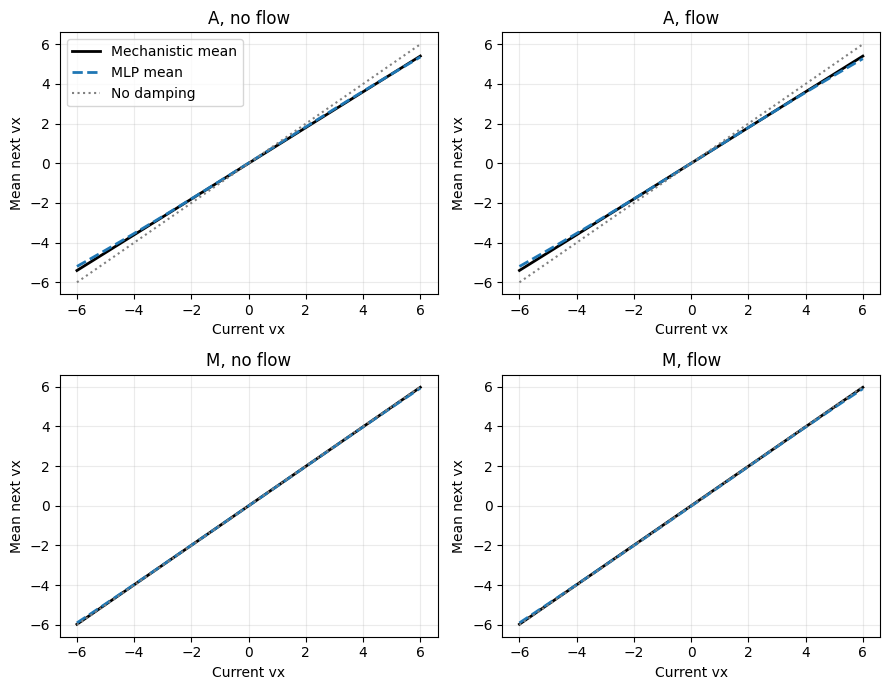

In [51]:
velocity_grid = np.linspace(
    -6.0,
    6.0,
    121
)

diagnostic_conditions = [
    (0, 0, "A, no flow"),
    (0, 1, "A, flow"),
    (1, 0, "M, no flow"),
    (1, 1, "M, flow")
]

plt.figure(figsize=(9, 7))

for plot_index, (
    phenotype,
    flow_condition,
    condition_name
) in enumerate(
    diagnostic_conditions,
    start=1
):
    diagnostic_inputs = np.column_stack([
        velocity_grid,
        np.zeros_like(velocity_grid),
        np.full_like(
            velocity_grid,
            phenotype
        ),
        np.full_like(
            velocity_grid,
            flow_condition
        )
    ]).astype(np.float32)

    normalized_diagnostic_inputs = (
        normalize_inputs(
            diagnostic_inputs
        )
    )

    with torch.no_grad():

        (
            diagnostic_mean_normalized,
            _,
            _
        ) = surrogate_model(
            torch.tensor(
                normalized_diagnostic_inputs,
                dtype=torch.float32,
                device=device
            )
        )

    diagnostic_mean_physical = (
        diagnostic_mean_normalized
        .cpu()
        .numpy()
        * target_std
        + target_mean
    )

    exact_mean = (
        mechanistic_conditional_mean(
            diagnostic_inputs
        )
    )

    plt.subplot(2, 2, plot_index)

    plt.plot(
        velocity_grid,
        exact_mean[:, 2],
        color="black",
        linewidth=2,
        label="Mechanistic mean"
    )

    plt.plot(
        velocity_grid,
        diagnostic_mean_physical[:, 2],
        color="tab:blue",
        linestyle="--",
        linewidth=2,
        label="MLP mean"
    )

    plt.plot(
        velocity_grid,
        velocity_grid,
        color="gray",
        linestyle=":",
        label="No damping"
    )

    plt.xlabel("Current vx")
    plt.ylabel("Mean next vx")
    plt.title(condition_name)
    plt.grid(alpha=0.25)

    if plot_index == 1:
        plt.legend()

plt.tight_layout()
plt.show()

In [52]:
for (
    phenotype,
    flow_condition,
    condition_name
) in diagnostic_conditions:

    diagnostic_inputs = np.column_stack([
        velocity_grid,
        np.zeros_like(velocity_grid),
        np.full_like(
            velocity_grid,
            phenotype
        ),
        np.full_like(
            velocity_grid,
            flow_condition
        )
    ]).astype(np.float32)

    normalized_diagnostic_inputs = (
        normalize_inputs(
            diagnostic_inputs
        )
    )

    with torch.no_grad():

        (
            diagnostic_mean_normalized,
            _,
            _
        ) = surrogate_model(
            torch.tensor(
                normalized_diagnostic_inputs,
                dtype=torch.float32,
                device=device
            )
        )

    mlp_mean = (
        diagnostic_mean_normalized
        .cpu()
        .numpy()
        * target_std
        + target_mean
    )

    exact_mean = (
        mechanistic_conditional_mean(
            diagnostic_inputs
        )
    )

    maximum_error = np.max(
        np.abs(
            mlp_mean[:, 2]
            - exact_mean[:, 2]
        )
    )

    edge_error = np.mean(
        np.abs(
            mlp_mean[
                np.abs(velocity_grid) >= 5,
                2
            ]
            - exact_mean[
                np.abs(velocity_grid) >= 5,
                2
            ]
        )
    )

    print(
        f"{condition_name:10s} | "
        f"maximum error = {maximum_error:.4f} | "
        f"mean edge error = {edge_error:.4f}"
    )

A, no flow | maximum error = 0.2050 | mean edge error = 0.0932
A, flow    | maximum error = 0.2026 | mean edge error = 0.1311
M, no flow | maximum error = 0.0705 | mean edge error = 0.0392
M, flow    | maximum error = 0.0701 | mean edge error = 0.0485


In [53]:
def physics_informed_surrogate_transition_batch(
    velocities,
    phenotypes,
    flow_conditions,
    model,
    phenotype_model,
    rng
):
    velocities = np.asarray(
        velocities,
        dtype=np.float32
    )

    phenotypes = np.asarray(
        phenotypes,
        dtype=np.float32
    )

    flow_conditions = np.asarray(
        flow_conditions,
        dtype=np.float32
    )

    model_inputs = np.column_stack([
        velocities,
        phenotypes,
        flow_conditions
    ]).astype(np.float32)

    normalized_inputs = normalize_inputs(
        model_inputs
    )

    input_tensor = torch.tensor(
        normalized_inputs,
        dtype=torch.float32,
        device=device
    )

    phenotype_tensor = torch.tensor(
        phenotypes,
        dtype=torch.float32,
        device=device
    )

    flow_tensor = torch.tensor(
        flow_conditions,
        dtype=torch.float32,
        device=device
    )

    model.eval()
    phenotype_model.eval()

    with torch.no_grad():

        (
            _,
            predicted_log_variance_normalized,
            _
        ) = model(input_tensor)

        structured_logits = phenotype_model(
            phenotype_tensor,
            flow_tensor
        )

        phenotype_probability = (
            torch.sigmoid(
                structured_logits
            )
            .cpu()
            .numpy()
        )

        predicted_log_variance_normalized = (
            predicted_log_variance_normalized
            .cpu()
            .numpy()
        )

    # Preserve the known mechanistic conditional mean
    exact_continuous_mean = (
        mechanistic_conditional_mean(
            model_inputs
        )
    )

    exact_velocity_mean = (
        exact_continuous_mean[:, 2:]
    )

    # MLP-predicted velocity variance in physical units
    predicted_velocity_variance = (
        np.exp(
            predicted_log_variance_normalized[
                :, 2:
            ]
        )
        * target_std[2:]**2
    )

    # Apply validation-derived variance calibration
    calibrated_velocity_variance = (
        predicted_velocity_variance
        * velocity_variance_calibration
    )

    sampled_next_velocities = (
        exact_velocity_mean
        + np.sqrt(
            calibrated_velocity_variance
        )
        * rng.normal(
            size=exact_velocity_mean.shape
        )
    )

    # Preserve the physical velocity-displacement coupling
    sampled_displacements = (
        sampled_next_velocities * dt
        + np.sqrt(2.0 * D * dt)
        * rng.normal(
            size=sampled_next_velocities.shape
        )
    )

    sampled_next_phenotypes = (
        rng.random(
            len(phenotype_probability)
        )
        < phenotype_probability
    ).astype(np.int64)

    return (
        sampled_displacements,
        sampled_next_velocities,
        sampled_next_phenotypes,
        phenotype_probability
    )

In [54]:
def simulate_physics_informed_surrogate(
    n_cells,
    n_steps,
    flow_condition,
    seed
):
    rng = np.random.default_rng(seed)

    positions = np.zeros(
        (n_cells, 2),
        dtype=float
    )

    velocities = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_cells, 2)
    )

    phenotypes = rng.integers(
        0,
        2,
        size=n_cells
    )

    flow_conditions = np.full(
        n_cells,
        flow_condition
    )

    msd_history = np.zeros(n_steps + 1)
    speed_history = np.zeros(n_steps + 1)
    fraction_history = np.zeros(n_steps + 1)

    msd_history[0] = 0.0

    speed_history[0] = np.mean(
        np.linalg.norm(
            velocities,
            axis=1
        )
    )

    fraction_history[0] = phenotypes.mean()

    for step in range(n_steps):

        (
            displacement,
            velocities,
            phenotypes,
            _
        ) = physics_informed_surrogate_transition_batch(
            velocities=velocities,
            phenotypes=phenotypes,
            flow_conditions=flow_conditions,
            model=surrogate_model,
            phenotype_model=phenotype_transition_head,
            rng=rng
        )

        positions += displacement

        msd_history[step + 1] = np.mean(
            np.sum(
                positions**2,
                axis=1
            )
        )

        speed_history[step + 1] = np.mean(
            np.linalg.norm(
                velocities,
                axis=1
            )
        )

        fraction_history[step + 1] = (
            phenotypes.mean()
        )

    return {
        "msd": msd_history,
        "speed": speed_history,
        "mesenchymal_fraction":
            fraction_history
    }

In [55]:
physics_surrogate_start = time.perf_counter()

physics_surrogate_no_flow = (
    simulate_physics_informed_surrogate(
        n_cells=n_rollout_cells,
        n_steps=n_rollout_steps,
        flow_condition=0,
        seed=51010
    )
)

physics_surrogate_flow = (
    simulate_physics_informed_surrogate(
        n_cells=n_rollout_cells,
        n_steps=n_rollout_steps,
        flow_condition=1,
        seed=51011
    )
)

physics_surrogate_runtime = (
    time.perf_counter()
    - physics_surrogate_start
)

In [56]:
for condition_name, mechanistic_result, surrogate_result in [
    (
        "NO FLOW",
        mechanistic_no_flow,
        physics_surrogate_no_flow
    ),
    (
        "WITH FLOW",
        mechanistic_flow,
        physics_surrogate_flow
    )
]:
    print()
    print(condition_name)

    print(
        "Mesenchymal fraction:",
        mechanistic_result[
            "mesenchymal_fraction"
        ][-1],
        surrogate_result[
            "mesenchymal_fraction"
        ][-1]
    )

    print(
        "Final mean speed:",
        mechanistic_result["speed"][-1],
        surrogate_result["speed"][-1]
    )

    print(
        "Final MSD:",
        mechanistic_result["msd"][-1],
        surrogate_result["msd"][-1]
    )

print()
print(
    "Physics-informed surrogate runtime:",
    physics_surrogate_runtime
)


NO FLOW
Mesenchymal fraction: 0.585 0.566
Final mean speed: 2.217650979188054 2.4084846197171417
Final MSD: 1798.254364487666 1794.0597696089949

WITH FLOW
Mesenchymal fraction: 0.27 0.246
Final mean speed: 2.598725900102338 2.7811644841408487
Final MSD: 1064.0464816579465 1093.3650647189054

Physics-informed surrogate runtime: 8.677782849998039


In [57]:
validation_seeds = [
    51100,
    51101,
    51102,
    51103,
    51104
]

multi_seed_results = []

for experiment_index, seed in enumerate(
    validation_seeds,
    start=1
):
    mechanistic_nf = (
        simulate_mechanistic_population(
            n_cells=1000,
            n_steps=1000,
            flow_condition=0,
            seed=seed
        )
    )

    surrogate_nf = (
        simulate_physics_informed_surrogate(
            n_cells=1000,
            n_steps=1000,
            flow_condition=0,
            seed=seed
        )
    )

    mechanistic_f = (
        simulate_mechanistic_population(
            n_cells=1000,
            n_steps=1000,
            flow_condition=1,
            seed=seed + 100
        )
    )

    surrogate_f = (
        simulate_physics_informed_surrogate(
            n_cells=1000,
            n_steps=1000,
            flow_condition=1,
            seed=seed + 100
        )
    )

    multi_seed_results.append([
        mechanistic_nf[
            "mesenchymal_fraction"
        ][-1],

        surrogate_nf[
            "mesenchymal_fraction"
        ][-1],

        mechanistic_f[
            "mesenchymal_fraction"
        ][-1],

        surrogate_f[
            "mesenchymal_fraction"
        ][-1],

        mechanistic_nf["speed"][-1],
        surrogate_nf["speed"][-1],

        mechanistic_f["speed"][-1],
        surrogate_f["speed"][-1],

        mechanistic_nf["msd"][-1],
        surrogate_nf["msd"][-1],

        mechanistic_f["msd"][-1],
        surrogate_f["msd"][-1]
    ])

    print(
        "Completed experiment",
        experiment_index,
        "of",
        len(validation_seeds)
    )

multi_seed_results = np.asarray(
    multi_seed_results
)

Completed experiment 1 of 5
Completed experiment 2 of 5
Completed experiment 3 of 5
Completed experiment 4 of 5
Completed experiment 5 of 5


In [58]:
metric_names = [
    "Fraction no flow, mechanistic",
    "Fraction no flow, surrogate",
    "Fraction flow, mechanistic",
    "Fraction flow, surrogate",
    "Speed no flow, mechanistic",
    "Speed no flow, surrogate",
    "Speed flow, mechanistic",
    "Speed flow, surrogate",
    "MSD no flow, mechanistic",
    "MSD no flow, surrogate",
    "MSD flow, mechanistic",
    "MSD flow, surrogate"
]

print()
print("Metric | Mean | SD")

for metric_index, metric_name in enumerate(
    metric_names
):
    print(
        f"{metric_name:32s} | "
        f"{multi_seed_results[:, metric_index].mean():9.4f} | "
        f"{multi_seed_results[:, metric_index].std():8.4f}"
    )


Metric | Mean | SD
Fraction no flow, mechanistic    |    0.5886 |   0.0091
Fraction no flow, surrogate      |    0.5958 |   0.0198
Fraction flow, mechanistic       |    0.2724 |   0.0107
Fraction flow, surrogate         |    0.2638 |   0.0134
Speed no flow, mechanistic       |    2.2873 |   0.0461
Speed no flow, surrogate         |    2.3477 |   0.0328
Speed flow, mechanistic          |    2.6537 |   0.0323
Speed flow, surrogate            |    2.7526 |   0.0245
MSD no flow, mechanistic         | 1854.5417 |  36.8356
MSD no flow, surrogate           | 1876.8973 |  58.8406
MSD flow, mechanistic            | 1119.0741 |  31.7950
MSD flow, surrogate              | 1140.8486 |  17.3675


In [59]:
mean_results = multi_seed_results.mean(axis=0)

print()
print(
    "No-flow fraction relative error:",
    100
    * (
        mean_results[1]
        - mean_results[0]
    )
    / mean_results[0],
    "%"
)

print(
    "Flow fraction relative error:",
    100
    * (
        mean_results[3]
        - mean_results[2]
    )
    / mean_results[2],
    "%"
)

print(
    "No-flow speed relative error:",
    100
    * (
        mean_results[5]
        - mean_results[4]
    )
    / mean_results[4],
    "%"
)

print(
    "Flow speed relative error:",
    100
    * (
        mean_results[7]
        - mean_results[6]
    )
    / mean_results[6],
    "%"
)

print(
    "No-flow MSD relative error:",
    100
    * (
        mean_results[9]
        - mean_results[8]
    )
    / mean_results[8],
    "%"
)

print(
    "Flow MSD relative error:",
    100
    * (
        mean_results[11]
        - mean_results[10]
    )
    / mean_results[10],
    "%"
)


No-flow fraction relative error: 1.2232415902140836 %
Flow fraction relative error: -3.1571218795888587 %
No-flow speed relative error: 2.638509276244654 %
Flow speed relative error: 3.725091383920011 %
No-flow MSD relative error: 1.2054512944656826 %
Flow MSD relative error: 1.9457562555072905 %


In [60]:
import os

os.makedirs(
    "surrogate_outputs",
    exist_ok=True
)

In [61]:
torch.save(
    {
        "surrogate_model_state":
            surrogate_model.state_dict(),

        "phenotype_transition_state":
            phenotype_transition_head.state_dict(),

        "velocity_input_mean":
            velocity_input_mean,

        "velocity_input_std":
            velocity_input_std,

        "target_mean":
            target_mean,

        "target_std":
            target_std,

        "velocity_variance_calibration":
            velocity_variance_calibration,

        "dt": dt,
        "D": D,

        "tau_amoeboid":
            tau_amoeboid,

        "tau_mesenchymal":
            tau_mesenchymal,

        "v_amoeboid":
            v_amoeboid,

        "v_mesenchymal":
            v_mesenchymal
    },
    "surrogate_outputs/"
    "physics_informed_mlp_surrogate.pt"
)

print("MLP checkpoint saved.")

MLP checkpoint saved.


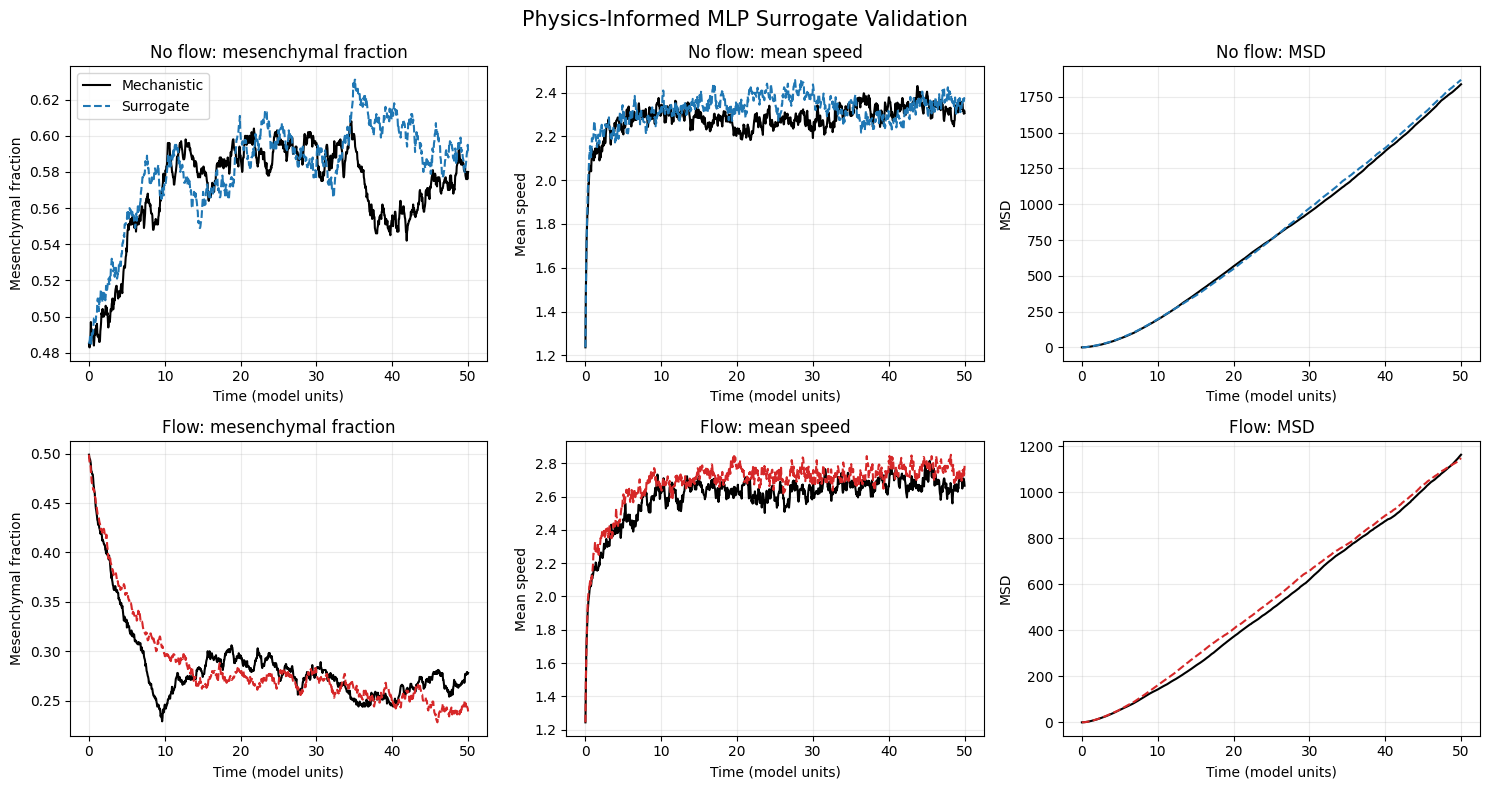

In [62]:
rollout_time = (
    np.arange(n_rollout_steps + 1)
    * dt
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

# Mesenchymal fraction
axes[0, 0].plot(
    rollout_time,
    mechanistic_nf[
        "mesenchymal_fraction"
    ],
    color="black",
    label="Mechanistic"
)

axes[0, 0].plot(
    rollout_time,
    surrogate_nf[
        "mesenchymal_fraction"
    ],
    color="tab:blue",
    linestyle="--",
    label="Surrogate"
)

axes[0, 0].set_title(
    "No flow: mesenchymal fraction"
)

axes[1, 0].plot(
    rollout_time,
    mechanistic_f[
        "mesenchymal_fraction"
    ],
    color="black"
)

axes[1, 0].plot(
    rollout_time,
    surrogate_f[
        "mesenchymal_fraction"
    ],
    color="tab:red",
    linestyle="--"
)

axes[1, 0].set_title(
    "Flow: mesenchymal fraction"
)

# Mean speed
axes[0, 1].plot(
    rollout_time,
    mechanistic_nf["speed"],
    color="black"
)

axes[0, 1].plot(
    rollout_time,
    surrogate_nf["speed"],
    color="tab:blue",
    linestyle="--"
)

axes[0, 1].set_title(
    "No flow: mean speed"
)

axes[1, 1].plot(
    rollout_time,
    mechanistic_f["speed"],
    color="black"
)

axes[1, 1].plot(
    rollout_time,
    surrogate_f["speed"],
    color="tab:red",
    linestyle="--"
)

axes[1, 1].set_title(
    "Flow: mean speed"
)

# MSD
axes[0, 2].plot(
    rollout_time,
    mechanistic_nf["msd"],
    color="black"
)

axes[0, 2].plot(
    rollout_time,
    surrogate_nf["msd"],
    color="tab:blue",
    linestyle="--"
)

axes[0, 2].set_title(
    "No flow: MSD"
)

axes[1, 2].plot(
    rollout_time,
    mechanistic_f["msd"],
    color="black"
)

axes[1, 2].plot(
    rollout_time,
    surrogate_f["msd"],
    color="tab:red",
    linestyle="--"
)

axes[1, 2].set_title(
    "Flow: MSD"
)

for axis in axes.flat:
    axis.set_xlabel("Time (model units)")
    axis.grid(alpha=0.25)

axes[0, 0].set_ylabel(
    "Mesenchymal fraction"
)

axes[1, 0].set_ylabel(
    "Mesenchymal fraction"
)

axes[0, 1].set_ylabel("Mean speed")
axes[1, 1].set_ylabel("Mean speed")

axes[0, 2].set_ylabel("MSD")
axes[1, 2].set_ylabel("MSD")

axes[0, 0].legend()

fig.suptitle(
    "Physics-Informed MLP Surrogate Validation",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "surrogate_outputs/"
    "mlp_long_rollout_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
transformer_window = 16


def build_transformer_sequences(
    trajectory_id_list
):
    sequence_inputs = []
    continuous_targets = []
    phenotype_targets = []
    sequence_trajectory_ids = []

    for trajectory_id in trajectory_id_list:

        trajectory_indices = np.where(
            surrogate_trajectory_ids
            == trajectory_id
        )[0]

        trajectory_displacements = (
            surrogate_targets[
                trajectory_indices,
                :2
            ]
        )

        trajectory_flow = (
            surrogate_inputs[
                trajectory_indices,
                3
            ]
        )

        trajectory_current_phenotype = (
            surrogate_inputs[
                trajectory_indices,
                2
            ]
        )

        trajectory_continuous_targets = (
            surrogate_targets[
                trajectory_indices
            ]
        )

        for target_step in range(
            transformer_window,
            len(trajectory_indices)
        ):
            history_displacement = (
                trajectory_displacements[
                    target_step
                    - transformer_window:
                    target_step
                ]
            )

            history_flow = trajectory_flow[
                target_step
                - transformer_window:
                target_step
            ][:, None]

            history_features = np.concatenate(
                [
                    history_displacement,
                    history_flow
                ],
                axis=1
            )

            sequence_inputs.append(
                history_features
            )

            continuous_targets.append(
                trajectory_continuous_targets[
                    target_step
                ]
            )

            phenotype_targets.append(
                trajectory_current_phenotype[
                    target_step
                ]
            )

            sequence_trajectory_ids.append(
                trajectory_id
            )

    return (
        np.asarray(
            sequence_inputs,
            dtype=np.float32
        ),
        np.asarray(
            continuous_targets,
            dtype=np.float32
        ),
        np.asarray(
            phenotype_targets,
            dtype=np.float32
        ),
        np.asarray(
            sequence_trajectory_ids,
            dtype=np.int64
        )
    )

In [64]:
(
    transformer_X_train,
    transformer_Y_train,
    transformer_phenotype_train,
    transformer_ids_train
) = build_transformer_sequences(
    train_trajectory_ids
)

(
    transformer_X_validation,
    transformer_Y_validation,
    transformer_phenotype_validation,
    transformer_ids_validation
) = build_transformer_sequences(
    validation_trajectory_ids
)

(
    transformer_X_test,
    transformer_Y_test,
    transformer_phenotype_test,
    transformer_ids_test
) = build_transformer_sequences(
    test_trajectory_ids
)

In [65]:
def normalize_transformer_sequences(
    sequence_array
):
    normalized_sequences = (
        sequence_array.copy()
    )

    normalized_sequences[:, :, :2] = (
        normalized_sequences[:, :, :2]
        - target_mean[:2]
    ) / target_std[:2]

    # Flow remains binary
    return normalized_sequences


transformer_X_train_normalized = (
    normalize_transformer_sequences(
        transformer_X_train
    )
)

transformer_X_validation_normalized = (
    normalize_transformer_sequences(
        transformer_X_validation
    )
)

transformer_X_test_normalized = (
    normalize_transformer_sequences(
        transformer_X_test
    )
)

transformer_Y_train_normalized = (
    normalize_targets(
        transformer_Y_train
    )
)

transformer_Y_validation_normalized = (
    normalize_targets(
        transformer_Y_validation
    )
)

transformer_Y_test_normalized = (
    normalize_targets(
        transformer_Y_test
    )
)

In [66]:
print(
    "Transformer training sequences:",
    transformer_X_train_normalized.shape
)

print(
    "Transformer validation sequences:",
    transformer_X_validation_normalized.shape
)

print(
    "Transformer test sequences:",
    transformer_X_test_normalized.shape
)

print(
    "Continuous training targets:",
    transformer_Y_train_normalized.shape
)

print(
    "Phenotype training targets:",
    transformer_phenotype_train.shape
)

print(
    "First sequence flow values:",
    transformer_X_train_normalized[
        0,
        :,
        2
    ]
)

print(
    "All values finite:",
    np.isfinite(
        transformer_X_train_normalized
    ).all()
    and np.isfinite(
        transformer_Y_train_normalized
    ).all()
)

Transformer training sequences: (35280, 16, 3)
Transformer validation sequences: (7560, 16, 3)
Transformer test sequences: (7560, 16, 3)
Continuous training targets: (35280, 4)
Phenotype training targets: (35280,)
First sequence flow values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
All values finite: True


In [67]:
transformer_train_dataset = TransitionDataset(
    transformer_X_train_normalized,
    transformer_Y_train_normalized,
    transformer_phenotype_train
)

transformer_validation_dataset = TransitionDataset(
    transformer_X_validation_normalized,
    transformer_Y_validation_normalized,
    transformer_phenotype_validation
)

transformer_test_dataset = TransitionDataset(
    transformer_X_test_normalized,
    transformer_Y_test_normalized,
    transformer_phenotype_test
)

transformer_train_loader = DataLoader(
    transformer_train_dataset,
    batch_size=128,
    shuffle=True
)

transformer_validation_loader = DataLoader(
    transformer_validation_dataset,
    batch_size=128,
    shuffle=False
)

transformer_test_loader = DataLoader(
    transformer_test_dataset,
    batch_size=128,
    shuffle=False
)

In [68]:
class ProbabilisticTransitionTransformer(
    nn.Module
):
    def __init__(
        self,
        sequence_length=16,
        input_dimension=3,
        model_dimension=32,
        number_of_heads=4,
        number_of_layers=2,
        feedforward_dimension=64,
        output_dimension=4
    ):
        super().__init__()

        self.sequence_length = sequence_length

        self.input_projection = nn.Linear(
            input_dimension,
            model_dimension
        )

        self.position_embedding = nn.Parameter(
            torch.zeros(
                1,
                sequence_length,
                model_dimension
            )
        )

        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=model_dimension,
                nhead=number_of_heads,
                dim_feedforward=
                    feedforward_dimension,
                dropout=0.10,
                activation="gelu",
                batch_first=True,
                norm_first=True
            )
        )

        self.transformer_encoder = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=number_of_layers
            )
        )

        self.final_normalization = nn.LayerNorm(
            model_dimension
        )

        self.mean_head = nn.Linear(
            model_dimension,
            output_dimension
        )

        self.log_variance_head = nn.Linear(
            model_dimension,
            output_dimension
        )

        self.phenotype_head = nn.Linear(
            model_dimension,
            1
        )

    def forward(self, sequence_input):

        hidden_sequence = (
            self.input_projection(
                sequence_input
            )
            + self.position_embedding
        )

        encoded_sequence = (
            self.transformer_encoder(
                hidden_sequence
            )
        )

        # Use the final history token
        final_hidden_state = (
            encoded_sequence[:, -1, :]
        )

        final_hidden_state = (
            self.final_normalization(
                final_hidden_state
            )
        )

        predicted_mean = self.mean_head(
            final_hidden_state
        )

        predicted_log_variance = (
            self.log_variance_head(
                final_hidden_state
            )
        )

        predicted_log_variance = torch.clamp(
            predicted_log_variance,
            min=-6.0,
            max=3.0
        )

        phenotype_logit = (
            self.phenotype_head(
                final_hidden_state
            ).squeeze(-1)
        )

        return (
            predicted_mean,
            predicted_log_variance,
            phenotype_logit
        )

In [69]:
transformer_model = (
    ProbabilisticTransitionTransformer(
        sequence_length=transformer_window
    )
    .to(device)
)

transformer_parameter_count = sum(
    parameter.numel()
    for parameter in transformer_model.parameters()
)

print(transformer_model)

print(
    "Transformer parameter count:",
    transformer_parameter_count
)

ProbabilisticTransitionTransformer(
  (input_projection): Linear(in_features=3, out_features=32, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (final_normalization): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (mean_head): Linear(in_features=32, out_features=4, bias=True)
  (log_variance_head): Linear(in_feature

/usr/local/lib/python3.9/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [70]:
(
    transformer_batch_inputs,
    transformer_batch_targets,
    transformer_batch_phenotypes
) = next(
    iter(transformer_train_loader)
)

with torch.no_grad():

    (
        transformer_test_mean,
        transformer_test_log_variance,
        transformer_test_phenotype_logit
    ) = transformer_model(
        transformer_batch_inputs.to(device)
    )

print(
    "Input batch shape:",
    transformer_batch_inputs.shape
)

print(
    "Mean output shape:",
    transformer_test_mean.shape
)

print(
    "Log-variance output shape:",
    transformer_test_log_variance.shape
)

print(
    "Phenotype output shape:",
    transformer_test_phenotype_logit.shape
)

Input batch shape: torch.Size([128, 16, 3])
Mean output shape: torch.Size([128, 4])
Log-variance output shape: torch.Size([128, 4])
Phenotype output shape: torch.Size([128])


In [71]:
transformer_optimizer = torch.optim.AdamW(
    transformer_model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

transformer_maximum_epochs = 40
transformer_patience = 7

transformer_training_history = []
transformer_validation_history = []

best_transformer_validation_loss = np.inf
best_transformer_state = None
transformer_epochs_without_improvement = 0


def evaluate_transformer(
    model,
    data_loader
):
    model.eval()

    accumulated_loss = 0.0
    accumulated_samples = 0

    with torch.no_grad():

        for (
            sequence_inputs,
            continuous_targets,
            phenotype_targets
        ) in data_loader:

            sequence_inputs = (
                sequence_inputs.to(device)
            )

            continuous_targets = (
                continuous_targets.to(device)
            )

            phenotype_targets = (
                phenotype_targets.to(device)
            )

            (
                predicted_mean,
                predicted_log_variance,
                phenotype_logit
            ) = model(sequence_inputs)

            continuous_loss = (
                gaussian_negative_log_likelihood(
                    continuous_targets,
                    predicted_mean,
                    predicted_log_variance
                )
            )

            phenotype_loss = (
                phenotype_loss_function(
                    phenotype_logit,
                    phenotype_targets
                )
            )

            total_loss = (
                continuous_loss
                + 0.50 * phenotype_loss
            )

            current_batch_size = len(
                sequence_inputs
            )

            accumulated_loss += (
                total_loss.item()
                * current_batch_size
            )

            accumulated_samples += (
                current_batch_size
            )

    return (
        accumulated_loss
        / accumulated_samples
    )

In [72]:
transformer_training_start = (
    time.perf_counter()
)

for epoch in range(
    1,
    transformer_maximum_epochs + 1
):

    transformer_model.train()

    accumulated_training_loss = 0.0
    accumulated_training_samples = 0

    for (
        sequence_inputs,
        continuous_targets,
        phenotype_targets
    ) in transformer_train_loader:

        sequence_inputs = (
            sequence_inputs.to(device)
        )

        continuous_targets = (
            continuous_targets.to(device)
        )

        phenotype_targets = (
            phenotype_targets.to(device)
        )

        transformer_optimizer.zero_grad()

        (
            predicted_mean,
            predicted_log_variance,
            phenotype_logit
        ) = transformer_model(
            sequence_inputs
        )

        continuous_loss = (
            gaussian_negative_log_likelihood(
                continuous_targets,
                predicted_mean,
                predicted_log_variance
            )
        )

        phenotype_loss = (
            phenotype_loss_function(
                phenotype_logit,
                phenotype_targets
            )
        )

        total_loss = (
            continuous_loss
            + 0.50 * phenotype_loss
        )

        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            transformer_model.parameters(),
            max_norm=5.0
        )

        transformer_optimizer.step()

        current_batch_size = len(
            sequence_inputs
        )

        accumulated_training_loss += (
            total_loss.item()
            * current_batch_size
        )

        accumulated_training_samples += (
            current_batch_size
        )

    mean_training_loss = (
        accumulated_training_loss
        / accumulated_training_samples
    )

    mean_validation_loss = (
        evaluate_transformer(
            transformer_model,
            transformer_validation_loader
        )
    )

    transformer_training_history.append(
        mean_training_loss
    )

    transformer_validation_history.append(
        mean_validation_loss
    )

    if (
        mean_validation_loss
        < best_transformer_validation_loss
    ):
        best_transformer_validation_loss = (
            mean_validation_loss
        )

        best_transformer_state = copy.deepcopy(
            transformer_model.state_dict()
        )

        transformer_epochs_without_improvement = 0

    else:
        transformer_epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0:

        print(
            f"Epoch {epoch:2d} | "
            f"train = {mean_training_loss:.4f} | "
            f"validation = "
            f"{mean_validation_loss:.4f}"
        )

    if (
        transformer_epochs_without_improvement
        >= transformer_patience
    ):
        print(
            "Early stopping at epoch:",
            epoch
        )
        break


transformer_training_runtime = (
    time.perf_counter()
    - transformer_training_start
)

transformer_model.load_state_dict(
    best_transformer_state
)

print(
    "Best validation loss:",
    best_transformer_validation_loss
)

print(
    "Training runtime:",
    transformer_training_runtime,
    "seconds"
)

Epoch  1 | train = 0.7100 | validation = 0.6838
Epoch  5 | train = 0.6043 | validation = 0.6361
Epoch 10 | train = 0.5919 | validation = 0.6309
Epoch 15 | train = 0.5783 | validation = 0.6161
Epoch 20 | train = 0.5702 | validation = 0.6144
Epoch 25 | train = 0.5649 | validation = 0.6135
Early stopping at epoch: 29
Best validation loss: 0.6040348393576486
Training runtime: 130.48081112500222 seconds


In [73]:
from sklearn.metrics import (
    balanced_accuracy_score
)

transformer_model.eval()

transformer_mean_batches = []
transformer_log_variance_batches = []
transformer_probability_batches = []

with torch.no_grad():

    for (
        sequence_inputs,
        continuous_targets,
        phenotype_targets
    ) in transformer_test_loader:

        sequence_inputs = (
            sequence_inputs.to(device)
        )

        (
            predicted_mean,
            predicted_log_variance,
            phenotype_logit
        ) = transformer_model(
            sequence_inputs
        )

        transformer_mean_batches.append(
            predicted_mean.cpu().numpy()
        )

        transformer_log_variance_batches.append(
            predicted_log_variance
            .cpu()
            .numpy()
        )

        transformer_probability_batches.append(
            torch.sigmoid(
                phenotype_logit
            )
            .cpu()
            .numpy()
        )


transformer_mean_normalized = np.concatenate(
    transformer_mean_batches,
    axis=0
)

transformer_log_variance_normalized = (
    np.concatenate(
        transformer_log_variance_batches,
        axis=0
    )
)

transformer_phenotype_probability = (
    np.concatenate(
        transformer_probability_batches,
        axis=0
    )
)

In [74]:
transformer_mean_physical = (
    transformer_mean_normalized
    * target_std
    + target_mean
)

transformer_variance_physical = (
    np.exp(
        transformer_log_variance_normalized
    )
    * target_std**2
)

transformer_sd_physical = np.sqrt(
    transformer_variance_physical
)

In [75]:
transformer_rmse = np.sqrt(
    np.mean(
        (
            transformer_mean_physical
            - transformer_Y_test
        ) ** 2,
        axis=0
    )
)

transformer_lower_95 = (
    transformer_mean_physical
    - 1.96 * transformer_sd_physical
)

transformer_upper_95 = (
    transformer_mean_physical
    + 1.96 * transformer_sd_physical
)

transformer_coverage = np.mean(
    (
        transformer_Y_test
        >= transformer_lower_95
    )
    & (
        transformer_Y_test
        <= transformer_upper_95
    ),
    axis=0
)

transformer_interval_width = np.mean(
    transformer_upper_95
    - transformer_lower_95,
    axis=0
)

for target_index, target_name in enumerate(
    target_names
):
    print(
        f"{target_name:8s} | "
        f"RMSE = "
        f"{transformer_rmse[target_index]:.4f} | "
        f"coverage = "
        f"{transformer_coverage[target_index]:.4f} | "
        f"width = "
        f"{transformer_interval_width[target_index]:.4f}"
    )

dx       | RMSE = 0.1705 | coverage = 0.9544 | width = 0.6772
dy       | RMSE = 0.1706 | coverage = 0.9549 | width = 0.6808
next vx  | RMSE = 1.3529 | coverage = 0.9435 | width = 5.3032
next vy  | RMSE = 1.3367 | coverage = 0.9378 | width = 5.1875


In [76]:
transformer_predicted_phenotype = (
    transformer_phenotype_probability
    >= 0.5
).astype(int)

transformer_phenotype_accuracy = np.mean(
    transformer_predicted_phenotype
    == transformer_phenotype_test
)

transformer_balanced_accuracy = (
    balanced_accuracy_score(
        transformer_phenotype_test,
        transformer_predicted_phenotype
    )
)

transformer_phenotype_auc = roc_auc_score(
    transformer_phenotype_test,
    transformer_phenotype_probability
)

transformer_phenotype_brier = (
    brier_score_loss(
        transformer_phenotype_test,
        transformer_phenotype_probability
    )
)

print()
print(
    "Phenotype accuracy:",
    transformer_phenotype_accuracy
)

print(
    "Phenotype balanced accuracy:",
    transformer_balanced_accuracy
)

print(
    "Phenotype ROC AUC:",
    transformer_phenotype_auc
)

print(
    "Phenotype Brier score:",
    transformer_phenotype_brier
)


Phenotype accuracy: 0.6505291005291005
Phenotype balanced accuracy: 0.6505834424152486
Phenotype ROC AUC: 0.7038531349092461
Phenotype Brier score: 0.22038520918166804


In [77]:
last_observed_displacement = (
    transformer_X_test[:, -1, :2]
)

transformer_baseline_prediction = (
    np.concatenate(
        [
            last_observed_displacement,
            last_observed_displacement / dt
        ],
        axis=1
    )
)

transformer_baseline_rmse = np.sqrt(
    np.mean(
        (
            transformer_baseline_prediction
            - transformer_Y_test
        ) ** 2,
        axis=0
    )
)

print()
print(
    "Target   | Transformer RMSE | "
    "History baseline RMSE"
)

for target_index, target_name in enumerate(
    target_names
):
    print(
        f"{target_name:8s} | "
        f"{transformer_rmse[target_index]:16.4f} | "
        f"{transformer_baseline_rmse[target_index]:21.4f}"
    )


Target   | Transformer RMSE | History baseline RMSE
dx       |           0.1705 |                0.2248
dy       |           0.1706 |                0.2267
next vx  |           1.3529 |                3.2388
next vy  |           1.3367 |                3.2405


In [78]:
transformer_improvement = (
    100.0
    * (
        transformer_baseline_rmse
        - transformer_rmse
    )
    / transformer_baseline_rmse
)

print(
    "Target | Improvement over history baseline"
)

for target_name, improvement in zip(
    target_names,
    transformer_improvement
):
    print(
        f"{target_name:8s} | "
        f"{improvement:6.2f}%"
    )

Target | Improvement over history baseline
dx       |  24.16%
dy       |  24.73%
next vx  |  58.23%
next vy  |  58.75%


In [79]:
torch.save(
    {
        "transformer_model_state":
            transformer_model.state_dict(),

        "sequence_length":
            transformer_window,

        "target_mean":
            target_mean,

        "target_std":
            target_std,

        "model_dimension": 32,

        "number_of_heads": 4,

        "number_of_layers": 2,

        "phenotype_auc":
            transformer_phenotype_auc,

        "phenotype_balanced_accuracy":
            transformer_balanced_accuracy,

        "phenotype_brier":
            transformer_phenotype_brier,

        "continuous_rmse":
            transformer_rmse,

        "coverage":
            transformer_coverage
    },
    "surrogate_outputs/"
    "probabilistic_transformer.pt"
)

print("Transformer checkpoint saved.")

Transformer checkpoint saved.


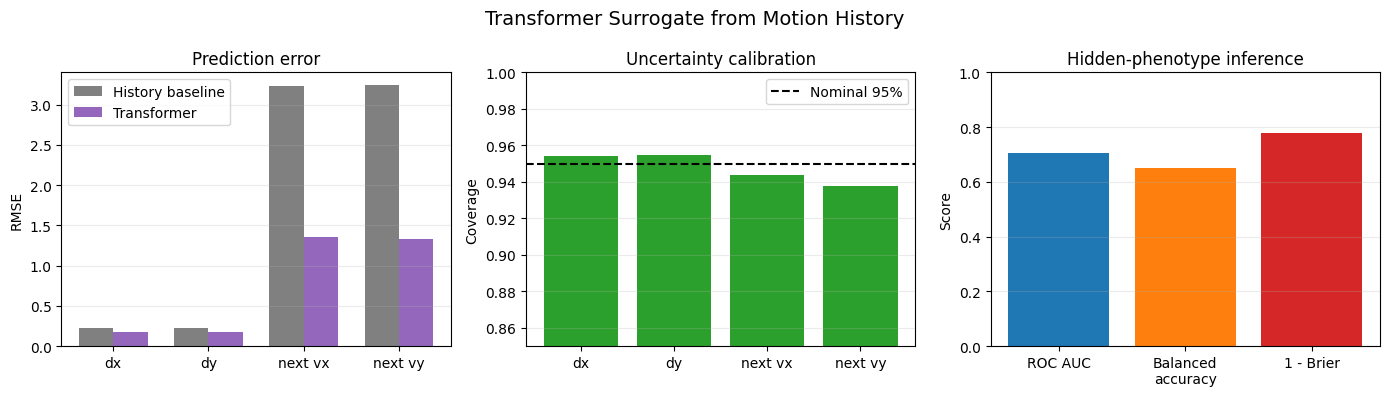

In [80]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4)
)

x_locations = np.arange(4)

axes[0].bar(
    x_locations - 0.18,
    transformer_baseline_rmse,
    width=0.36,
    label="History baseline",
    color="gray"
)

axes[0].bar(
    x_locations + 0.18,
    transformer_rmse,
    width=0.36,
    label="Transformer",
    color="tab:purple"
)

axes[0].set_xticks(x_locations)
axes[0].set_xticklabels(target_names)
axes[0].set_ylabel("RMSE")
axes[0].set_title("Prediction error")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    target_names,
    transformer_coverage,
    color="tab:green"
)

axes[1].axhline(
    0.95,
    color="black",
    linestyle="--",
    label="Nominal 95%"
)

axes[1].set_ylim(0.85, 1.0)
axes[1].set_ylabel("Coverage")
axes[1].set_title("Uncertainty calibration")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

phenotype_metric_names = [
    "ROC AUC",
    "Balanced\naccuracy",
    "1 - Brier"
]

phenotype_metric_values = [
    transformer_phenotype_auc,
    transformer_balanced_accuracy,
    1.0 - transformer_phenotype_brier
]

axes[2].bar(
    phenotype_metric_names,
    phenotype_metric_values,
    color=[
        "tab:blue",
        "tab:orange",
        "tab:red"
    ]
)

axes[2].set_ylim(0, 1)
axes[2].set_ylabel("Score")
axes[2].set_title(
    "Hidden-phenotype inference"
)
axes[2].grid(axis="y", alpha=0.25)

fig.suptitle(
    "Transformer Surrogate from Motion History",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "surrogate_outputs/"
    "transformer_test_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
def generate_forecast_truth(
    n_cells,
    n_steps,
    flow_condition,
    seed
):
    rng = np.random.default_rng(seed)

    positions = np.zeros(
        (n_steps + 1, n_cells, 2)
    )

    displacements = np.zeros(
        (n_steps, n_cells, 2)
    )

    velocities = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_cells, 2)
    )

    phenotypes = rng.integers(
        0,
        2,
        size=n_cells
    )

    phenotype_history = np.zeros(
        (n_steps + 1, n_cells),
        dtype=np.int64
    )

    phenotype_history[0] = phenotypes

    if flow_condition == 0:
        k_am = k_am_no_flow
        k_ma = k_ma_no_flow
    else:
        k_am = k_am_flow
        k_ma = k_ma_flow

    for step in range(n_steps):

        switch_random_number = rng.random(
            n_cells
        )

        next_phenotypes = phenotypes.copy()

        next_phenotypes[
            (phenotypes == 0)
            & (
                switch_random_number
                < k_am * dt
            )
        ] = 1

        next_phenotypes[
            (phenotypes == 1)
            & (
                switch_random_number
                < k_ma * dt
            )
        ] = 0

        tau = np.where(
            next_phenotypes == 0,
            tau_amoeboid,
            tau_mesenchymal
        )

        speed_scale = np.where(
            next_phenotypes == 0,
            v_amoeboid,
            v_mesenchymal
        )

        velocities = (
            velocities
            - velocities
            / tau[:, None]
            * dt
            + speed_scale[:, None]
            * np.sqrt(
                2.0 * dt / tau
            )[:, None]
            * rng.normal(
                size=(n_cells, 2)
            )
        )

        step_displacement = (
            velocities * dt
            + np.sqrt(2.0 * D * dt)
            * rng.normal(
                size=(n_cells, 2)
            )
        )

        positions[step + 1] = (
            positions[step]
            + step_displacement
        )

        displacements[step] = (
            step_displacement
        )

        phenotypes = next_phenotypes

        phenotype_history[
            step + 1
        ] = phenotypes

    return {
        "positions": positions,
        "displacements": displacements,
        "phenotypes": phenotype_history
    }

In [82]:
forecast_cell_count = 500
forecast_history_steps = transformer_window
forecast_maximum_horizon_steps = 160

forecast_total_steps = (
    forecast_history_steps
    + forecast_maximum_horizon_steps
)

transformer_truth_no_flow = (
    generate_forecast_truth(
        n_cells=forecast_cell_count,
        n_steps=forecast_total_steps,
        flow_condition=0,
        seed=52000
    )
)

transformer_truth_flow = (
    generate_forecast_truth(
        n_cells=forecast_cell_count,
        n_steps=forecast_total_steps,
        flow_condition=1,
        seed=52001
    )
)

print(
    "No-flow position shape:",
    transformer_truth_no_flow[
        "positions"
    ].shape
)

print(
    "No-flow displacement shape:",
    transformer_truth_no_flow[
        "displacements"
    ].shape
)

print(
    "Flow position shape:",
    transformer_truth_flow[
        "positions"
    ].shape
)

print(
    "Assimilation/history duration:",
    forecast_history_steps * dt
)

print(
    "Maximum forecast horizon:",
    forecast_maximum_horizon_steps * dt
)

No-flow position shape: (177, 500, 2)
No-flow displacement shape: (176, 500, 2)
Flow position shape: (177, 500, 2)
Assimilation/history duration: 0.8
Maximum forecast horizon: 8.0


In [83]:
def autoregressive_transformer_mean_forecast(
    truth_data,
    flow_condition,
    model,
    history_steps,
    horizon_steps
):
    initial_history = (
        truth_data["displacements"][
            :history_steps
        ]
        .transpose(1, 0, 2)
        .copy()
    )

    n_cells = initial_history.shape[0]

    flow_history = np.full(
        (
            n_cells,
            history_steps,
            1
        ),
        flow_condition,
        dtype=np.float32
    )

    forecast_positions = np.zeros(
        (
            horizon_steps + 1,
            n_cells,
            2
        )
    )

    forecast_positions[0] = (
        truth_data["positions"][
            history_steps
        ]
    )

    phenotype_probability_history = (
        np.zeros(
            (horizon_steps, n_cells)
        )
    )

    displacement_history = initial_history

    model.eval()

    for forecast_step in range(
        horizon_steps
    ):
        sequence_features = np.concatenate(
            [
                displacement_history,
                flow_history
            ],
            axis=2
        ).astype(np.float32)

        normalized_features = (
            normalize_transformer_sequences(
                sequence_features
            )
        )

        feature_tensor = torch.tensor(
            normalized_features,
            dtype=torch.float32,
            device=device
        )

        with torch.no_grad():

            (
                predicted_mean_normalized,
                _,
                phenotype_logit
            ) = model(feature_tensor)

        predicted_mean = (
            predicted_mean_normalized
            .cpu()
            .numpy()
            * target_std
            + target_mean
        )

        next_displacement = (
            predicted_mean[:, :2]
        )

        forecast_positions[
            forecast_step + 1
        ] = (
            forecast_positions[
                forecast_step
            ]
            + next_displacement
        )

        phenotype_probability_history[
            forecast_step
        ] = (
            torch.sigmoid(
                phenotype_logit
            )
            .cpu()
            .numpy()
        )

        displacement_history = np.concatenate(
            [
                displacement_history[:, 1:, :],
                next_displacement[:, None, :]
            ],
            axis=1
        )

    return (
        forecast_positions,
        phenotype_probability_history
    )

In [84]:
transformer_forecast_start = (
    time.perf_counter()
)

(
    transformer_forecast_no_flow,
    transformer_forecast_probability_no_flow
) = autoregressive_transformer_mean_forecast(
    truth_data=transformer_truth_no_flow,
    flow_condition=0,
    model=transformer_model,
    history_steps=forecast_history_steps,
    horizon_steps=
        forecast_maximum_horizon_steps
)

(
    transformer_forecast_flow,
    transformer_forecast_probability_flow
) = autoregressive_transformer_mean_forecast(
    truth_data=transformer_truth_flow,
    flow_condition=1,
    model=transformer_model,
    history_steps=forecast_history_steps,
    horizon_steps=
        forecast_maximum_horizon_steps
)

transformer_forecast_runtime = (
    time.perf_counter()
    - transformer_forecast_start
)

print(
    "Autoregressive forecast runtime:",
    transformer_forecast_runtime
)

print(
    "No-flow forecast shape:",
    transformer_forecast_no_flow.shape
)

print(
    "Flow forecast shape:",
    transformer_forecast_flow.shape
)

Autoregressive forecast runtime: 2.357688882999355
No-flow forecast shape: (161, 500, 2)
Flow forecast shape: (161, 500, 2)


In [85]:
forecast_horizon_steps = np.array([
    10,
    20,
    40,
    80,
    160
])

forecast_horizon_times = (
    forecast_horizon_steps * dt
)


def position_rmse_batch(
    prediction,
    truth
):
    return np.sqrt(
        np.mean(
            np.sum(
                (prediction - truth) ** 2,
                axis=1
            )
        )
    )


def evaluate_transformer_forecast(
    truth_data,
    transformer_forecast,
    history_steps
):
    cutoff_position = (
        truth_data["positions"][
            history_steps
        ]
    )

    last_displacement = (
        truth_data["displacements"][
            history_steps - 1
        ]
    )

    transformer_rmse_values = []
    hold_rmse_values = []
    linear_rmse_values = []

    for horizon_step in forecast_horizon_steps:

        hidden_truth = (
            truth_data["positions"][
                history_steps
                + horizon_step
            ]
        )

        transformer_prediction = (
            transformer_forecast[
                horizon_step
            ]
        )

        hold_prediction = cutoff_position

        linear_prediction = (
            cutoff_position
            + horizon_step
            * last_displacement
        )

        transformer_rmse_values.append(
            position_rmse_batch(
                transformer_prediction,
                hidden_truth
            )
        )

        hold_rmse_values.append(
            position_rmse_batch(
                hold_prediction,
                hidden_truth
            )
        )

        linear_rmse_values.append(
            position_rmse_batch(
                linear_prediction,
                hidden_truth
            )
        )

    return (
        np.asarray(transformer_rmse_values),
        np.asarray(hold_rmse_values),
        np.asarray(linear_rmse_values)
    )

In [86]:
(
    transformer_rmse_no_flow,
    hold_rmse_no_flow,
    linear_rmse_no_flow
) = evaluate_transformer_forecast(
    transformer_truth_no_flow,
    transformer_forecast_no_flow,
    forecast_history_steps
)

(
    transformer_rmse_flow,
    hold_rmse_flow,
    linear_rmse_flow
) = evaluate_transformer_forecast(
    transformer_truth_flow,
    transformer_forecast_flow,
    forecast_history_steps
)

In [87]:
for condition_name, twin_rmse, hold_rmse, linear_rmse in [
    (
        "NO FLOW",
        transformer_rmse_no_flow,
        hold_rmse_no_flow,
        linear_rmse_no_flow
    ),
    (
        "WITH FLOW",
        transformer_rmse_flow,
        hold_rmse_flow,
        linear_rmse_flow
    )
]:
    print()
    print(condition_name)

    print(
        "Horizon | Transformer | Hold | Linear"
    )

    for horizon, twin, hold, linear in zip(
        forecast_horizon_times,
        twin_rmse,
        hold_rmse,
        linear_rmse
    ):
        print(
            f"{horizon:7.1f} | "
            f"{twin:11.3f} | "
            f"{hold:5.3f} | "
            f"{linear:6.3f}"
        )


NO FLOW
Horizon | Transformer | Hold | Linear
    0.5 |       1.161 | 1.304 |  2.430
    1.0 |       2.065 | 2.267 |  4.934
    2.0 |       3.680 | 3.944 |  9.884
    4.0 |       6.669 | 6.799 | 19.858
    8.0 |      12.123 | 11.890 | 39.990

WITH FLOW
Horizon | Transformer | Hold | Linear
    0.5 |       1.147 | 1.304 |  2.450
    1.0 |       1.964 | 2.160 |  4.927
    2.0 |       3.428 | 3.645 |  9.995
    4.0 |       5.800 | 6.001 | 19.917
    8.0 |       9.831 | 9.904 | 39.726


In [88]:
def percent_improvement(
    model_rmse,
    baseline_rmse
):
    return (
        100.0
        * (
            baseline_rmse
            - model_rmse
        )
        / baseline_rmse
    )


transformer_vs_hold_no_flow = (
    percent_improvement(
        transformer_rmse_no_flow,
        hold_rmse_no_flow
    )
)

transformer_vs_linear_no_flow = (
    percent_improvement(
        transformer_rmse_no_flow,
        linear_rmse_no_flow
    )
)

transformer_vs_hold_flow = (
    percent_improvement(
        transformer_rmse_flow,
        hold_rmse_flow
    )
)

transformer_vs_linear_flow = (
    percent_improvement(
        transformer_rmse_flow,
        linear_rmse_flow
    )
)

print(
    "Horizon | NF vs hold | NF vs linear | "
    "Flow vs hold | Flow vs linear"
)

for values in zip(
    forecast_horizon_times,
    transformer_vs_hold_no_flow,
    transformer_vs_linear_no_flow,
    transformer_vs_hold_flow,
    transformer_vs_linear_flow
):
    (
        horizon,
        nf_hold,
        nf_linear,
        f_hold,
        f_linear
    ) = values

    print(
        f"{horizon:7.1f} | "
        f"{nf_hold:10.1f}% | "
        f"{nf_linear:12.1f}% | "
        f"{f_hold:12.1f}% | "
        f"{f_linear:14.1f}%"
    )

Horizon | NF vs hold | NF vs linear | Flow vs hold | Flow vs linear
    0.5 |       11.0% |         52.2% |         12.1% |           53.2%
    1.0 |        8.9% |         58.1% |          9.1% |           60.1%
    2.0 |        6.7% |         62.8% |          6.0% |           65.7%
    4.0 |        1.9% |         66.4% |          3.3% |           70.9%
    8.0 |       -2.0% |         69.7% |          0.7% |           75.3%


In [89]:
def transformer_ensemble_forecast(
    truth_data,
    flow_condition,
    model,
    history_steps,
    horizon_steps,
    n_evaluation_cells=100,
    n_ensemble_members=50,
    seed=53000,
    inference_batch_size=2048
):
    rng = np.random.default_rng(seed)

    initial_history = (
        truth_data["displacements"][
            :history_steps,
            :n_evaluation_cells
        ]
        .transpose(1, 0, 2)
    )

    cutoff_positions = (
        truth_data["positions"][
            history_steps,
            :n_evaluation_cells
        ]
    )

    # Shape:
    # ensemble x cell x history x coordinate
    ensemble_history = np.repeat(
        initial_history[
            None,
            :, :, :
        ],
        n_ensemble_members,
        axis=0
    )

    ensemble_positions = np.repeat(
        cutoff_positions[
            None,
            :, :
        ],
        n_ensemble_members,
        axis=0
    )

    ensemble_history = (
        ensemble_history.reshape(
            -1,
            history_steps,
            2
        )
    )

    ensemble_positions = (
        ensemble_positions.reshape(
            -1,
            2
        )
    )

    total_particles = len(
        ensemble_positions
    )

    flow_history = np.full(
        (
            total_particles,
            history_steps,
            1
        ),
        flow_condition,
        dtype=np.float32
    )

    saved_positions = {}

    model.eval()

    for forecast_step in range(
        1,
        horizon_steps + 1
    ):
        sequence_features = np.concatenate(
            [
                ensemble_history,
                flow_history
            ],
            axis=2
        ).astype(np.float32)

        normalized_features = (
            normalize_transformer_sequences(
                sequence_features
            )
        )

        mean_batches = []
        log_variance_batches = []

        with torch.no_grad():

            for batch_start in range(
                0,
                total_particles,
                inference_batch_size
            ):
                batch_end = min(
                    batch_start
                    + inference_batch_size,
                    total_particles
                )

                batch_tensor = torch.tensor(
                    normalized_features[
                        batch_start:batch_end
                    ],
                    dtype=torch.float32,
                    device=device
                )

                (
                    predicted_mean,
                    predicted_log_variance,
                    _
                ) = model(batch_tensor)

                mean_batches.append(
                    predicted_mean
                    .cpu()
                    .numpy()
                )

                log_variance_batches.append(
                    predicted_log_variance
                    .cpu()
                    .numpy()
                )

        predicted_mean_normalized = (
            np.concatenate(
                mean_batches,
                axis=0
            )
        )

        predicted_log_variance_normalized = (
            np.concatenate(
                log_variance_batches,
                axis=0
            )
        )

        predicted_mean = (
            predicted_mean_normalized
            * target_std
            + target_mean
        )

        predicted_sd = (
            np.exp(
                0.5
                * predicted_log_variance_normalized
            )
            * target_std
        )

        sampled_displacement = (
            predicted_mean[:, :2]
            + predicted_sd[:, :2]
            * rng.normal(
                size=(
                    total_particles,
                    2
                )
            )
        )

        ensemble_positions += (
            sampled_displacement
        )

        ensemble_history = np.concatenate(
            [
                ensemble_history[:, 1:, :],
                sampled_displacement[
                    :, None, :
                ]
            ],
            axis=1
        )

        if forecast_step in forecast_horizon_steps:

            saved_positions[forecast_step] = (
                ensemble_positions.reshape(
                    n_ensemble_members,
                    n_evaluation_cells,
                    2
                ).copy()
            )

    return saved_positions

In [90]:
uncertainty_start = time.perf_counter()

transformer_ensemble_no_flow = (
    transformer_ensemble_forecast(
        truth_data=transformer_truth_no_flow,
        flow_condition=0,
        model=transformer_model,
        history_steps=forecast_history_steps,
        horizon_steps=
            forecast_maximum_horizon_steps,
        seed=53000
    )
)

transformer_ensemble_flow = (
    transformer_ensemble_forecast(
        truth_data=transformer_truth_flow,
        flow_condition=1,
        model=transformer_model,
        history_steps=forecast_history_steps,
        horizon_steps=
            forecast_maximum_horizon_steps,
        seed=53001
    )
)

print(
    "Uncertainty forecast runtime:",
    time.perf_counter()
    - uncertainty_start
)

Uncertainty forecast runtime: 34.481041480001295


In [91]:
def evaluate_ensemble_forecast(
    ensemble_results,
    truth_data,
    history_steps,
    n_evaluation_cells=100
):
    rmse_values = []
    coverage_values = []
    width_values = []

    for horizon_step in forecast_horizon_steps:

        ensemble_positions = (
            ensemble_results[
                horizon_step
            ]
        )

        true_positions = (
            truth_data["positions"][
                history_steps
                + horizon_step,
                :n_evaluation_cells
            ]
        )

        forecast_mean = (
            ensemble_positions.mean(axis=0)
        )

        lower_limit = np.quantile(
            ensemble_positions,
            0.025,
            axis=0
        )

        upper_limit = np.quantile(
            ensemble_positions,
            0.975,
            axis=0
        )

        rmse_values.append(
            position_rmse_batch(
                forecast_mean,
                true_positions
            )
        )

        coverage_values.append(
            np.mean(
                (true_positions >= lower_limit)
                & (
                    true_positions
                    <= upper_limit
                )
            )
        )

        width_values.append(
            np.mean(
                upper_limit
                - lower_limit
            )
        )

    return (
        np.asarray(rmse_values),
        np.asarray(coverage_values),
        np.asarray(width_values)
    )

In [92]:
(
    ensemble_rmse_no_flow,
    ensemble_coverage_no_flow,
    ensemble_width_no_flow
) = evaluate_ensemble_forecast(
    transformer_ensemble_no_flow,
    transformer_truth_no_flow,
    forecast_history_steps
)

(
    ensemble_rmse_flow,
    ensemble_coverage_flow,
    ensemble_width_flow
) = evaluate_ensemble_forecast(
    transformer_ensemble_flow,
    transformer_truth_flow,
    forecast_history_steps
)

print(
    "Horizon | NF RMSE | NF coverage | "
    "NF width | Flow RMSE | "
    "Flow coverage | Flow width"
)

for values in zip(
    forecast_horizon_times,
    ensemble_rmse_no_flow,
    ensemble_coverage_no_flow,
    ensemble_width_no_flow,
    ensemble_rmse_flow,
    ensemble_coverage_flow,
    ensemble_width_flow
):
    (
        horizon,
        nf_rmse,
        nf_coverage,
        nf_width,
        f_rmse,
        f_coverage,
        f_width
    ) = values

    print(
        f"{horizon:7.1f} | "
        f"{nf_rmse:7.3f} | "
        f"{nf_coverage:11.3f} | "
        f"{nf_width:8.3f} | "
        f"{f_rmse:9.3f} | "
        f"{f_coverage:13.3f} | "
        f"{f_width:10.3f}"
    )

Horizon | NF RMSE | NF coverage | NF width | Flow RMSE | Flow coverage | Flow width
    0.5 |   1.286 |       0.865 |    2.867 |     1.263 |         0.915 |      3.110
    1.0 |   2.392 |       0.870 |    5.210 |     2.154 |         0.920 |      5.499
    2.0 |   4.037 |       0.905 |    9.522 |     3.512 |         0.925 |      9.507
    4.0 |   6.607 |       0.905 |   15.593 |     5.604 |         0.935 |     15.238
    8.0 |  11.407 |       0.855 |   23.794 |     9.512 |         0.920 |     22.695


In [93]:
transformer_calibration_no_flow = (
    generate_forecast_truth(
        n_cells=100,
        n_steps=forecast_total_steps,
        flow_condition=0,
        seed=54000
    )
)

transformer_calibration_flow = (
    generate_forecast_truth(
        n_cells=100,
        n_steps=forecast_total_steps,
        flow_condition=1,
        seed=54001
    )
)

In [94]:
calibration_ensemble_no_flow = (
    transformer_ensemble_forecast(
        truth_data=
            transformer_calibration_no_flow,
        flow_condition=0,
        model=transformer_model,
        history_steps=forecast_history_steps,
        horizon_steps=
            forecast_maximum_horizon_steps,
        n_evaluation_cells=100,
        n_ensemble_members=50,
        seed=54100
    )
)

calibration_ensemble_flow = (
    transformer_ensemble_forecast(
        truth_data=
            transformer_calibration_flow,
        flow_condition=1,
        model=transformer_model,
        history_steps=forecast_history_steps,
        horizon_steps=
            forecast_maximum_horizon_steps,
        n_evaluation_cells=100,
        n_ensemble_members=50,
        seed=54101
    )
)

In [95]:
def calculate_conformal_scales(
    ensemble_results,
    truth_data,
    history_steps
):
    scale_factors = []

    for horizon_step in forecast_horizon_steps:

        ensemble_positions = (
            ensemble_results[horizon_step]
        )

        forecast_mean = (
            ensemble_positions.mean(axis=0)
        )

        forecast_sd = (
            ensemble_positions.std(
                axis=0,
                ddof=1
            )
        )

        true_positions = (
            truth_data["positions"][
                history_steps
                + horizon_step,
                :forecast_mean.shape[0]
            ]
        )

        standardized_error = (
            np.abs(
                true_positions
                - forecast_mean
            )
            / np.maximum(
                forecast_sd,
                1e-8
            )
        )

        scale_factors.append(
            np.quantile(
                standardized_error,
                0.95
            )
        )

    return np.asarray(scale_factors)


conformal_scale_no_flow = (
    calculate_conformal_scales(
        calibration_ensemble_no_flow,
        transformer_calibration_no_flow,
        forecast_history_steps
    )
)

conformal_scale_flow = (
    calculate_conformal_scales(
        calibration_ensemble_flow,
        transformer_calibration_flow,
        forecast_history_steps
    )
)

print(
    "Horizon | No-flow scale | Flow scale"
)

for horizon, nf_scale, f_scale in zip(
    forecast_horizon_times,
    conformal_scale_no_flow,
    conformal_scale_flow
):
    print(
        f"{horizon:7.1f} | "
        f"{nf_scale:13.3f} | "
        f"{f_scale:10.3f}"
    )

Horizon | No-flow scale | Flow scale
    0.5 |         1.869 |      1.776
    1.0 |         1.956 |      1.921
    2.0 |         2.144 |      1.931
    4.0 |         2.007 |      2.158
    8.0 |         2.418 |      2.257


In [96]:
def evaluate_conformal_intervals(
    ensemble_results,
    truth_data,
    history_steps,
    scale_factors
):
    coverage_values = []
    width_values = []
    rmse_values = []

    for horizon_index, horizon_step in enumerate(
        forecast_horizon_steps
    ):
        ensemble_positions = (
            ensemble_results[horizon_step]
        )

        forecast_mean = (
            ensemble_positions.mean(axis=0)
        )

        forecast_sd = (
            ensemble_positions.std(
                axis=0,
                ddof=1
            )
        )

        true_positions = (
            truth_data["positions"][
                history_steps
                + horizon_step,
                :forecast_mean.shape[0]
            ]
        )

        calibrated_half_width = (
            scale_factors[horizon_index]
            * forecast_sd
        )

        lower_limit = (
            forecast_mean
            - calibrated_half_width
        )

        upper_limit = (
            forecast_mean
            + calibrated_half_width
        )

        coverage_values.append(
            np.mean(
                (true_positions >= lower_limit)
                & (
                    true_positions
                    <= upper_limit
                )
            )
        )

        width_values.append(
            np.mean(
                upper_limit
                - lower_limit
            )
        )

        rmse_values.append(
            position_rmse_batch(
                forecast_mean,
                true_positions
            )
        )

    return (
        np.asarray(rmse_values),
        np.asarray(coverage_values),
        np.asarray(width_values)
    )

In [97]:
(
    conformal_rmse_no_flow,
    conformal_coverage_no_flow,
    conformal_width_no_flow
) = evaluate_conformal_intervals(
    transformer_ensemble_no_flow,
    transformer_truth_no_flow,
    forecast_history_steps,
    conformal_scale_no_flow
)

(
    conformal_rmse_flow,
    conformal_coverage_flow,
    conformal_width_flow
) = evaluate_conformal_intervals(
    transformer_ensemble_flow,
    transformer_truth_flow,
    forecast_history_steps,
    conformal_scale_flow
)

print(
    "Horizon | NF coverage | NF width | "
    "Flow coverage | Flow width"
)

for values in zip(
    forecast_horizon_times,
    conformal_coverage_no_flow,
    conformal_width_no_flow,
    conformal_coverage_flow,
    conformal_width_flow
):
    horizon, nfc, nfw, fc, fw = values

    print(
        f"{horizon:7.1f} | "
        f"{nfc:11.3f} | "
        f"{nfw:8.3f} | "
        f"{fc:13.3f} | "
        f"{fw:10.3f}"
    )

print()
print(
    "Mean calibrated no-flow coverage:",
    conformal_coverage_no_flow.mean()
)

print(
    "Mean calibrated flow coverage:",
    conformal_coverage_flow.mean()
)

Horizon | NF coverage | NF width | Flow coverage | Flow width
    0.5 |       0.905 |    2.932 |         0.910 |      3.006
    1.0 |       0.890 |    5.576 |         0.945 |      5.798
    2.0 |       0.915 |   11.100 |         0.950 |     10.108
    4.0 |       0.935 |   17.178 |         0.980 |     18.063
    8.0 |       0.955 |   31.791 |         0.955 |     28.103

Mean calibrated no-flow coverage: 0.9199999999999999
Mean calibrated flow coverage: 0.9479999999999998


In [98]:
def get_standardized_forecast_scores(
    ensemble_results,
    truth_data,
    history_steps
):
    scores_by_horizon = []

    for horizon_step in forecast_horizon_steps:

        ensemble_positions = (
            ensemble_results[horizon_step]
        )

        forecast_mean = (
            ensemble_positions.mean(axis=0)
        )

        forecast_sd = (
            ensemble_positions.std(
                axis=0,
                ddof=1
            )
        )

        true_positions = (
            truth_data["positions"][
                history_steps
                + horizon_step,
                :forecast_mean.shape[0]
            ]
        )

        standardized_scores = (
            np.abs(
                true_positions
                - forecast_mean
            )
            / np.maximum(
                forecast_sd,
                1e-8
            )
        )

        scores_by_horizon.append(
            standardized_scores.ravel()
        )

    return scores_by_horizon

In [99]:
no_flow_score_sets = [
    get_standardized_forecast_scores(
        calibration_ensemble_no_flow,
        transformer_calibration_no_flow,
        forecast_history_steps
    )
]

flow_score_sets = [
    get_standardized_forecast_scores(
        calibration_ensemble_flow,
        transformer_calibration_flow,
        forecast_history_steps
    )
]

In [100]:
for calibration_index in range(2):

    new_no_flow_truth = generate_forecast_truth(
        n_cells=100,
        n_steps=forecast_total_steps,
        flow_condition=0,
        seed=54200 + calibration_index
    )

    new_flow_truth = generate_forecast_truth(
        n_cells=100,
        n_steps=forecast_total_steps,
        flow_condition=1,
        seed=54300 + calibration_index
    )

    new_no_flow_ensemble = (
        transformer_ensemble_forecast(
            truth_data=new_no_flow_truth,
            flow_condition=0,
            model=transformer_model,
            history_steps=
                forecast_history_steps,
            horizon_steps=
                forecast_maximum_horizon_steps,
            n_evaluation_cells=100,
            n_ensemble_members=50,
            seed=54400 + calibration_index
        )
    )

    new_flow_ensemble = (
        transformer_ensemble_forecast(
            truth_data=new_flow_truth,
            flow_condition=1,
            model=transformer_model,
            history_steps=
                forecast_history_steps,
            horizon_steps=
                forecast_maximum_horizon_steps,
            n_evaluation_cells=100,
            n_ensemble_members=50,
            seed=54500 + calibration_index
        )
    )

    no_flow_score_sets.append(
        get_standardized_forecast_scores(
            new_no_flow_ensemble,
            new_no_flow_truth,
            forecast_history_steps
        )
    )

    flow_score_sets.append(
        get_standardized_forecast_scores(
            new_flow_ensemble,
            new_flow_truth,
            forecast_history_steps
        )
    )

    print(
        "Completed additional calibration",
        calibration_index + 1,
        "of 2"
    )

Completed additional calibration 1 of 2
Completed additional calibration 2 of 2


In [101]:
def combined_conformal_scales(
    score_sets,
    target_coverage=0.95
):
    scales = []

    for horizon_index in range(
        len(forecast_horizon_steps)
    ):
        combined_scores = np.concatenate([
            score_set[horizon_index]
            for score_set in score_sets
        ])

        n_scores = len(combined_scores)

        quantile_level = min(
            1.0,
            np.ceil(
                (n_scores + 1)
                * target_coverage
            )
            / n_scores
        )

        scale = np.quantile(
            combined_scores,
            quantile_level,
            method="higher"
        )

        scales.append(scale)

    return np.asarray(scales)


combined_scale_no_flow = (
    combined_conformal_scales(
        no_flow_score_sets
    )
)

combined_scale_flow = (
    combined_conformal_scales(
        flow_score_sets
    )
)

print(
    "No-flow scales:",
    combined_scale_no_flow
)

print(
    "Flow scales:",
    combined_scale_flow
)

No-flow scales: [1.95312129 1.9106087  2.05487101 2.02671646 2.82597412]
Flow scales: [1.82845635 1.92767941 1.90564013 2.06273605 2.41724794]


In [102]:
(
    _,
    final_coverage_no_flow,
    final_width_no_flow
) = evaluate_conformal_intervals(
    transformer_ensemble_no_flow,
    transformer_truth_no_flow,
    forecast_history_steps,
    combined_scale_no_flow
)

(
    _,
    final_coverage_flow,
    final_width_flow
) = evaluate_conformal_intervals(
    transformer_ensemble_flow,
    transformer_truth_flow,
    forecast_history_steps,
    combined_scale_flow
)

print(
    "Horizon | NF coverage | NF width | "
    "Flow coverage | Flow width"
)

for values in zip(
    forecast_horizon_times,
    final_coverage_no_flow,
    final_width_no_flow,
    final_coverage_flow,
    final_width_flow
):
    horizon, nfc, nfw, fc, fw = values

    print(
        f"{horizon:7.1f} | "
        f"{nfc:11.3f} | "
        f"{nfw:8.3f} | "
        f"{fc:13.3f} | "
        f"{fw:10.3f}"
    )

print()
print(
    "Final mean no-flow coverage:",
    final_coverage_no_flow.mean()
)

print(
    "Final mean flow coverage:",
    final_coverage_flow.mean()
)

Horizon | NF coverage | NF width | Flow coverage | Flow width
    0.5 |       0.905 |    3.064 |         0.920 |      3.095
    1.0 |       0.890 |    5.446 |         0.945 |      5.819
    2.0 |       0.910 |   10.637 |         0.950 |      9.974
    4.0 |       0.935 |   17.343 |         0.980 |     17.267
    8.0 |       0.980 |   37.157 |         0.970 |     30.093

Final mean no-flow coverage: 0.924
Final mean flow coverage: 0.953


In [103]:
surrogate_twin_cell_count = 20
surrogate_twin_fine_steps = 1000
surrogate_twin_measurement_interval = 20
surrogate_twin_measurement_std = 0.50
surrogate_twin_flow_condition = 1

surrogate_twin_truth = generate_forecast_truth(
    n_cells=surrogate_twin_cell_count,
    n_steps=surrogate_twin_fine_steps,
    flow_condition=
        surrogate_twin_flow_condition,
    seed=55000
)

surrogate_twin_measurement_steps = np.arange(
    0,
    surrogate_twin_fine_steps + 1,
    surrogate_twin_measurement_interval
)

surrogate_twin_true_measurements = (
    surrogate_twin_truth["positions"][
        surrogate_twin_measurement_steps
    ]
)

surrogate_twin_measurement_rng = (
    np.random.default_rng(55001)
)

surrogate_twin_measurements = (
    surrogate_twin_true_measurements
    + surrogate_twin_measurement_rng.normal(
        loc=0.0,
        scale=surrogate_twin_measurement_std,
        size=
            surrogate_twin_true_measurements.shape
    )
)

print(
    "Hidden position shape:",
    surrogate_twin_truth[
        "positions"
    ].shape
)

print(
    "Measurement shape:",
    surrogate_twin_measurements.shape
)

print(
    "Number of measurement frames:",
    len(
        surrogate_twin_measurement_steps
    )
)

print(
    "Fine steps between measurements:",
    surrogate_twin_measurement_interval
)

measurement_error = (
    surrogate_twin_measurements
    - surrogate_twin_true_measurements
)

surrogate_twin_measurement_rmse = np.sqrt(
    np.mean(
        np.sum(
            measurement_error**2,
            axis=2
        )
    )
)

print(
    "Raw measurement RMSE:",
    surrogate_twin_measurement_rmse
)

Hidden position shape: (1001, 20, 2)
Measurement shape: (51, 20, 2)
Number of measurement frames: 51
Fine steps between measurements: 20
Raw measurement RMSE: 0.722275831934676


In [104]:
def mechanistic_transition_batch(
    velocities,
    phenotypes,
    flow_conditions,
    rng
):
    velocities = np.asarray(
        velocities,
        dtype=float
    )

    phenotypes = np.asarray(
        phenotypes,
        dtype=np.int64
    )

    flow_conditions = np.asarray(
        flow_conditions,
        dtype=np.int64
    )

    k_am = np.where(
        flow_conditions == 0,
        k_am_no_flow,
        k_am_flow
    )

    k_ma = np.where(
        flow_conditions == 0,
        k_ma_no_flow,
        k_ma_flow
    )

    switch_random = rng.random(
        len(phenotypes)
    )

    next_phenotypes = phenotypes.copy()

    next_phenotypes[
        (phenotypes == 0)
        & (switch_random < k_am * dt)
    ] = 1

    next_phenotypes[
        (phenotypes == 1)
        & (switch_random < k_ma * dt)
    ] = 0

    tau = np.where(
        next_phenotypes == 0,
        tau_amoeboid,
        tau_mesenchymal
    )

    speed_scale = np.where(
        next_phenotypes == 0,
        v_amoeboid,
        v_mesenchymal
    )

    next_velocities = (
        velocities
        - velocities
        / tau[:, None]
        * dt
        + speed_scale[:, None]
        * np.sqrt(
            2.0 * dt / tau
        )[:, None]
        * rng.normal(
            size=velocities.shape
        )
    )

    displacements = (
        next_velocities * dt
        + np.sqrt(2.0 * D * dt)
        * rng.normal(
            size=velocities.shape
        )
    )

    return (
        displacements,
        next_velocities,
        next_phenotypes
    )


def systematic_resample(
    normalized_weights,
    rng
):
    particle_count = len(
        normalized_weights
    )

    positions = (
        rng.random() / particle_count
        + np.arange(particle_count)
        / particle_count
    )

    cumulative_weights = np.cumsum(
        normalized_weights
    )

    cumulative_weights[-1] = 1.0

    return np.searchsorted(
        cumulative_weights,
        positions
    )

In [105]:
def run_particle_filter_comparison_model(
    transition_engine,
    measurements,
    true_positions,
    measurement_interval,
    flow_condition,
    n_particles,
    seed
):
    rng = np.random.default_rng(seed)

    n_frames, n_cells, _ = (
        measurements.shape
    )

    particle_positions = (
        measurements[0, :, None, :]
        + rng.normal(
            loc=0.0,
            scale=surrogate_twin_measurement_std,
            size=(
                n_cells,
                n_particles,
                2
            )
        )
    )

    particle_velocities = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(
            n_cells,
            n_particles,
            2
        )
    )

    if flow_condition == 0:
        initial_mesenchymal_fraction = (
            k_am_no_flow
            / (
                k_am_no_flow
                + k_ma_no_flow
            )
        )
    else:
        initial_mesenchymal_fraction = (
            k_am_flow
            / (
                k_am_flow
                + k_ma_flow
            )
        )

    particle_phenotypes = (
        rng.random(
            size=(
                n_cells,
                n_particles
            )
        )
        < initial_mesenchymal_fraction
    ).astype(np.int64)

    prediction_rmse = np.full(
        n_frames,
        np.nan
    )

    update_rmse = np.full(
        n_frames,
        np.nan
    )

    posterior_means = np.full(
        (
            n_frames,
            n_cells,
            2
        ),
        np.nan
    )

    posterior_means[0] = (
        particle_positions.mean(axis=1)
    )

    start_time = time.perf_counter()

    for frame_index in range(
        1,
        n_frames
    ):
        for fine_step in range(
            measurement_interval
        ):
            flat_velocities = (
                particle_velocities.reshape(
                    -1,
                    2
                )
            )

            flat_phenotypes = (
                particle_phenotypes.reshape(
                    -1
                )
            )

            flat_flow = np.full(
                len(flat_phenotypes),
                flow_condition
            )

            if transition_engine == "mechanistic":

                (
                    flat_displacements,
                    flat_next_velocities,
                    flat_next_phenotypes
                ) = mechanistic_transition_batch(
                    velocities=flat_velocities,
                    phenotypes=flat_phenotypes,
                    flow_conditions=flat_flow,
                    rng=rng
                )

            elif transition_engine == "surrogate":

                (
                    flat_displacements,
                    flat_next_velocities,
                    flat_next_phenotypes,
                    _
                ) = (
                    physics_informed_surrogate_transition_batch(
                        velocities=flat_velocities,
                        phenotypes=flat_phenotypes,
                        flow_conditions=flat_flow,
                        model=surrogate_model,
                        phenotype_model=
                            phenotype_transition_head,
                        rng=rng
                    )
                )

            else:
                raise ValueError(
                    "Unknown transition engine"
                )

            particle_positions += (
                flat_displacements.reshape(
                    n_cells,
                    n_particles,
                    2
                )
            )

            particle_velocities = (
                flat_next_velocities.reshape(
                    n_cells,
                    n_particles,
                    2
                )
            )

            particle_phenotypes = (
                flat_next_phenotypes.reshape(
                    n_cells,
                    n_particles
                )
            )

        predicted_mean = (
            particle_positions.mean(axis=1)
        )

        prediction_rmse[
            frame_index
        ] = position_rmse_batch(
            predicted_mean,
            true_positions[
                frame_index
            ]
        )

        updated_mean = np.zeros(
            (n_cells, 2)
        )

        for cell_index in range(n_cells):

            residual = (
                measurements[
                    frame_index,
                    cell_index
                ]
                - particle_positions[
                    cell_index
                ]
            )

            log_weights = (
                -0.5
                * np.sum(
                    residual**2,
                    axis=1
                )
                / surrogate_twin_measurement_std**2
            )

            log_weights -= np.max(
                log_weights
            )

            weights = np.exp(log_weights)
            weights /= weights.sum()

            updated_mean[cell_index] = (
                np.sum(
                    particle_positions[
                        cell_index
                    ]
                    * weights[:, None],
                    axis=0
                )
            )

            resampled_indices = (
                systematic_resample(
                    weights,
                    rng
                )
            )

            particle_positions[
                cell_index
            ] = particle_positions[
                cell_index,
                resampled_indices
            ]

            particle_velocities[
                cell_index
            ] = particle_velocities[
                cell_index,
                resampled_indices
            ]

            particle_phenotypes[
                cell_index
            ] = particle_phenotypes[
                cell_index,
                resampled_indices
            ]

        posterior_means[
            frame_index
        ] = updated_mean

        update_rmse[
            frame_index
        ] = position_rmse_batch(
            updated_mean,
            true_positions[
                frame_index
            ]
        )

    runtime = (
        time.perf_counter()
        - start_time
    )

    return {
        "prediction_rmse":
            prediction_rmse,

        "update_rmse":
            update_rmse,

        "posterior_means":
            posterior_means,

        "runtime":
            runtime
    }

In [106]:
smoke_test_measurements = (
    surrogate_twin_measurements[
        :6,
        :2
    ]
)

smoke_test_truth = (
    surrogate_twin_true_measurements[
        :6,
        :2
    ]
)

mechanistic_smoke_test = (
    run_particle_filter_comparison_model(
        transition_engine="mechanistic",
        measurements=
            smoke_test_measurements,
        true_positions=
            smoke_test_truth,
        measurement_interval=
            surrogate_twin_measurement_interval,
        flow_condition=
            surrogate_twin_flow_condition,
        n_particles=100,
        seed=55100
    )
)

surrogate_smoke_test = (
    run_particle_filter_comparison_model(
        transition_engine="surrogate",
        measurements=
            smoke_test_measurements,
        true_positions=
            smoke_test_truth,
        measurement_interval=
            surrogate_twin_measurement_interval,
        flow_condition=
            surrogate_twin_flow_condition,
        n_particles=100,
        seed=55100
    )
)

print(
    "Mechanistic updated RMSE:",
    np.sqrt(
        np.nanmean(
            mechanistic_smoke_test[
                "update_rmse"
            ] ** 2
        )
    )
)

print(
    "Surrogate updated RMSE:",
    np.sqrt(
        np.nanmean(
            surrogate_smoke_test[
                "update_rmse"
            ] ** 2
        )
    )
)

print(
    "Mechanistic runtime:",
    mechanistic_smoke_test[
        "runtime"
    ]
)

print(
    "Surrogate runtime:",
    surrogate_smoke_test[
        "runtime"
    ]
)

print(
    "All mechanistic results finite:",
    np.isfinite(
        mechanistic_smoke_test[
            "posterior_means"
        ][1:]
    ).all()
)

print(
    "All surrogate results finite:",
    np.isfinite(
        surrogate_smoke_test[
            "posterior_means"
        ][1:]
    ).all()
)

Mechanistic updated RMSE: 0.8078601361136426
Surrogate updated RMSE: 0.8018756832078582
Mechanistic runtime: 0.011955751997447805
Surrogate runtime: 0.15017643299870542
All mechanistic results finite: True
All surrogate results finite: True


In [107]:
full_particle_count = 300

mechanistic_twin_result = (
    run_particle_filter_comparison_model(
        transition_engine="mechanistic",
        measurements=
            surrogate_twin_measurements,
        true_positions=
            surrogate_twin_true_measurements,
        measurement_interval=
            surrogate_twin_measurement_interval,
        flow_condition=
            surrogate_twin_flow_condition,
        n_particles=full_particle_count,
        seed=55200
    )
)

surrogate_twin_result = (
    run_particle_filter_comparison_model(
        transition_engine="surrogate",
        measurements=
            surrogate_twin_measurements,
        true_positions=
            surrogate_twin_true_measurements,
        measurement_interval=
            surrogate_twin_measurement_interval,
        flow_condition=
            surrogate_twin_flow_condition,
        n_particles=full_particle_count,
        seed=55200
    )
)

In [108]:
mechanistic_prediction_rmse = np.sqrt(
    np.nanmean(
        mechanistic_twin_result[
            "prediction_rmse"
        ] ** 2
    )
)

mechanistic_update_rmse = np.sqrt(
    np.nanmean(
        mechanistic_twin_result[
            "update_rmse"
        ] ** 2
    )
)

surrogate_prediction_rmse = np.sqrt(
    np.nanmean(
        surrogate_twin_result[
            "prediction_rmse"
        ] ** 2
    )
)

surrogate_update_rmse = np.sqrt(
    np.nanmean(
        surrogate_twin_result[
            "update_rmse"
        ] ** 2
    )
)

print(
    "Model        | Prediction RMSE | "
    "Updated RMSE | Runtime"
)

print(
    f"Mechanistic  | "
    f"{mechanistic_prediction_rmse:15.4f} | "
    f"{mechanistic_update_rmse:12.4f} | "
    f"{mechanistic_twin_result['runtime']:7.3f}"
)

print(
    f"Surrogate    | "
    f"{surrogate_prediction_rmse:15.4f} | "
    f"{surrogate_update_rmse:12.4f} | "
    f"{surrogate_twin_result['runtime']:7.3f}"
)

print(
    f"Measurement  | "
    f"{'--':>15s} | "
    f"{surrogate_twin_measurement_rmse:12.4f} | "
    f"{'--':>7s}"
)

Model        | Prediction RMSE | Updated RMSE | Runtime
Mechanistic  |          2.5833 |       0.7550 |   0.785
Surrogate    |          2.5794 |       0.7717 |  21.218
Measurement  |              -- |       0.7223 |      --


In [109]:
print()
print(
    "Surrogate updated-RMSE difference:",
    100
    * (
        surrogate_update_rmse
        - mechanistic_update_rmse
    )
    / mechanistic_update_rmse,
    "%"
)

print(
    "Mechanistic improvement over measurements:",
    100
    * (
        surrogate_twin_measurement_rmse
        - mechanistic_update_rmse
    )
    / surrogate_twin_measurement_rmse,
    "%"
)

print(
    "Surrogate improvement over measurements:",
    100
    * (
        surrogate_twin_measurement_rmse
        - surrogate_update_rmse
    )
    / surrogate_twin_measurement_rmse,
    "%"
)

print(
    "Runtime ratio, surrogate/mechanistic:",
    surrogate_twin_result["runtime"]
    / mechanistic_twin_result["runtime"]
)


Surrogate updated-RMSE difference: 2.2155185855128368 %
Mechanistic improvement over measurements: -4.532615330284322 %
Surrogate improvement over measurements: -6.848554850849412 %
Runtime ratio, surrogate/mechanistic: 27.03867661704513


In [110]:
print(
    "Model        | Prediction RMSE | "
    "Updated RMSE | Runtime"
)

print(
    f"Mechanistic  | "
    f"{mechanistic_prediction_rmse:15.4f} | "
    f"{mechanistic_update_rmse:12.4f} | "
    f"{mechanistic_twin_result['runtime']:7.3f}"
)

print(
    f"Surrogate    | "
    f"{surrogate_prediction_rmse:15.4f} | "
    f"{surrogate_update_rmse:12.4f} | "
    f"{surrogate_twin_result['runtime']:7.3f}"
)

print(
    f"Measurement  | "
    f"{'--':>15s} | "
    f"{surrogate_twin_measurement_rmse:12.4f} | "
    f"{'--':>7s}"
)

Model        | Prediction RMSE | Updated RMSE | Runtime
Mechanistic  |          2.5833 |       0.7550 |   0.785
Surrogate    |          2.5794 |       0.7717 |  21.218
Measurement  |              -- |       0.7223 |      --


In [111]:
def run_ensemble_kalman_twin(
    transition_engine,
    measurements,
    true_positions,
    measurement_interval,
    flow_condition,
    n_ensemble,
    seed
):
    rng = np.random.default_rng(seed)

    n_frames, n_cells, _ = (
        measurements.shape
    )

    ensemble_positions = (
        measurements[0, :, None, :]
        + rng.normal(
            loc=0.0,
            scale=
                surrogate_twin_measurement_std,
            size=(
                n_cells,
                n_ensemble,
                2
            )
        )
    )

    ensemble_velocities = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(
            n_cells,
            n_ensemble,
            2
        )
    )

    if flow_condition == 0:
        equilibrium_fraction = (
            k_am_no_flow
            / (
                k_am_no_flow
                + k_ma_no_flow
            )
        )
    else:
        equilibrium_fraction = (
            k_am_flow
            / (
                k_am_flow
                + k_ma_flow
            )
        )

    ensemble_phenotypes = (
        rng.random(
            size=(n_cells, n_ensemble)
        )
        < equilibrium_fraction
    ).astype(np.int64)

    prediction_rmse = np.full(
        n_frames,
        np.nan
    )

    update_rmse = np.full(
        n_frames,
        np.nan
    )

    posterior_means = np.full(
        (n_frames, n_cells, 2),
        np.nan
    )

    posterior_means[0] = (
        ensemble_positions.mean(axis=1)
    )

    measurement_covariance = (
        surrogate_twin_measurement_std**2
        * np.eye(2)
    )

    start_time = time.perf_counter()

    for frame_index in range(
        1,
        n_frames
    ):
        # Prediction
        for fine_step in range(
            measurement_interval
        ):
            flat_velocities = (
                ensemble_velocities.reshape(
                    -1,
                    2
                )
            )

            flat_phenotypes = (
                ensemble_phenotypes.reshape(
                    -1
                )
            )

            flat_flow = np.full(
                len(flat_phenotypes),
                flow_condition
            )

            if transition_engine == "mechanistic":

                (
                    flat_displacements,
                    flat_next_velocities,
                    flat_next_phenotypes
                ) = mechanistic_transition_batch(
                    flat_velocities,
                    flat_phenotypes,
                    flat_flow,
                    rng
                )

            elif transition_engine == "surrogate":

                (
                    flat_displacements,
                    flat_next_velocities,
                    flat_next_phenotypes,
                    _
                ) = (
                    physics_informed_surrogate_transition_batch(
                        velocities=
                            flat_velocities,
                        phenotypes=
                            flat_phenotypes,
                        flow_conditions=
                            flat_flow,
                        model=surrogate_model,
                        phenotype_model=
                            phenotype_transition_head,
                        rng=rng
                    )
                )

            else:
                raise ValueError(
                    "Unknown transition engine"
                )

            ensemble_positions += (
                flat_displacements.reshape(
                    n_cells,
                    n_ensemble,
                    2
                )
            )

            ensemble_velocities = (
                flat_next_velocities.reshape(
                    n_cells,
                    n_ensemble,
                    2
                )
            )

            ensemble_phenotypes = (
                flat_next_phenotypes.reshape(
                    n_cells,
                    n_ensemble
                )
            )

        predicted_mean = (
            ensemble_positions.mean(axis=1)
        )

        prediction_rmse[
            frame_index
        ] = position_rmse_batch(
            predicted_mean,
            true_positions[frame_index]
        )

        updated_position_mean = np.zeros(
            (n_cells, 2)
        )

        # Ensemble Kalman measurement update
        for cell_index in range(n_cells):

            state_ensemble = np.concatenate(
                [
                    ensemble_positions[
                        cell_index
                    ],
                    ensemble_velocities[
                        cell_index
                    ]
                ],
                axis=1
            )

            state_mean = state_ensemble.mean(
                axis=0
            )

            position_mean = (
                ensemble_positions[
                    cell_index
                ].mean(axis=0)
            )

            state_anomalies = (
                state_ensemble
                - state_mean
            )

            position_anomalies = (
                ensemble_positions[
                    cell_index
                ]
                - position_mean
            )

            cross_covariance = (
                state_anomalies.T
                @ position_anomalies
                / (n_ensemble - 1)
            )

            position_covariance = (
                position_anomalies.T
                @ position_anomalies
                / (n_ensemble - 1)
            )

            innovation_covariance = (
                position_covariance
                + measurement_covariance
            )

            kalman_gain = (
                cross_covariance
                @ np.linalg.inv(
                    innovation_covariance
                )
            )

            perturbed_measurements = (
                measurements[
                    frame_index,
                    cell_index
                ]
                + rng.normal(
                    loc=0.0,
                    scale=
                        surrogate_twin_measurement_std,
                    size=(n_ensemble, 2)
                )
            )

            innovations = (
                perturbed_measurements
                - ensemble_positions[
                    cell_index
                ]
            )

            updated_state_ensemble = (
                state_ensemble
                + innovations
                @ kalman_gain.T
            )

            ensemble_positions[
                cell_index
            ] = updated_state_ensemble[:, :2]

            ensemble_velocities[
                cell_index
            ] = updated_state_ensemble[:, 2:]

            updated_position_mean[
                cell_index
            ] = (
                updated_state_ensemble[
                    :, :2
                ].mean(axis=0)
            )

        posterior_means[
            frame_index
        ] = updated_position_mean

        update_rmse[
            frame_index
        ] = position_rmse_batch(
            updated_position_mean,
            true_positions[
                frame_index
            ]
        )

    runtime = (
        time.perf_counter()
        - start_time
    )

    return {
        "prediction_rmse":
            prediction_rmse,

        "update_rmse":
            update_rmse,

        "posterior_means":
            posterior_means,

        "runtime":
            runtime
    }

In [112]:
mechanistic_enkf_result = (
    run_ensemble_kalman_twin(
        transition_engine="mechanistic",
        measurements=
            surrogate_twin_measurements,
        true_positions=
            surrogate_twin_true_measurements,
        measurement_interval=
            surrogate_twin_measurement_interval,
        flow_condition=
            surrogate_twin_flow_condition,
        n_ensemble=300,
        seed=55300
    )
)

surrogate_enkf_result = (
    run_ensemble_kalman_twin(
        transition_engine="surrogate",
        measurements=
            surrogate_twin_measurements,
        true_positions=
            surrogate_twin_true_measurements,
        measurement_interval=
            surrogate_twin_measurement_interval,
        flow_condition=
            surrogate_twin_flow_condition,
        n_ensemble=300,
        seed=55300
    )
)

In [113]:
mechanistic_enkf_prediction = np.sqrt(
    np.nanmean(
        mechanistic_enkf_result[
            "prediction_rmse"
        ] ** 2
    )
)

mechanistic_enkf_update = np.sqrt(
    np.nanmean(
        mechanistic_enkf_result[
            "update_rmse"
        ] ** 2
    )
)

surrogate_enkf_prediction = np.sqrt(
    np.nanmean(
        surrogate_enkf_result[
            "prediction_rmse"
        ] ** 2
    )
)

surrogate_enkf_update = np.sqrt(
    np.nanmean(
        surrogate_enkf_result[
            "update_rmse"
        ] ** 2
    )
)

print(
    "Model       | Prediction | Updated | Runtime"
)

print(
    f"Mechanistic | "
    f"{mechanistic_enkf_prediction:10.4f} | "
    f"{mechanistic_enkf_update:7.4f} | "
    f"{mechanistic_enkf_result['runtime']:7.3f}"
)

print(
    f"Surrogate   | "
    f"{surrogate_enkf_prediction:10.4f} | "
    f"{surrogate_enkf_update:7.4f} | "
    f"{surrogate_enkf_result['runtime']:7.3f}"
)

print(
    f"Measurement | "
    f"{'--':>10s} | "
    f"{surrogate_twin_measurement_rmse:7.4f} | "
    f"{'--':>7s}"
)

Model       | Prediction | Updated | Runtime
Mechanistic |     2.5060 |  0.6966 |   0.743
Surrogate   |     2.4962 |  0.6963 |  20.944
Measurement |         -- |  0.7223 |      --


In [114]:
mechanistic_enkf_improvement = (
    100
    * (
        surrogate_twin_measurement_rmse
        - mechanistic_enkf_update
    )
    / surrogate_twin_measurement_rmse
)

surrogate_enkf_improvement = (
    100
    * (
        surrogate_twin_measurement_rmse
        - surrogate_enkf_update
    )
    / surrogate_twin_measurement_rmse
)

surrogate_prediction_difference = (
    100
    * (
        surrogate_enkf_prediction
        - mechanistic_enkf_prediction
    )
    / mechanistic_enkf_prediction
)

surrogate_update_difference = (
    100
    * (
        surrogate_enkf_update
        - mechanistic_enkf_update
    )
    / mechanistic_enkf_update
)

print(
    "Mechanistic improvement over measurement:",
    mechanistic_enkf_improvement,
    "%"
)

print(
    "Surrogate improvement over measurement:",
    surrogate_enkf_improvement,
    "%"
)

print(
    "Surrogate prediction-RMSE difference:",
    surrogate_prediction_difference,
    "%"
)

print(
    "Surrogate update-RMSE difference:",
    surrogate_update_difference,
    "%"
)

print(
    "Runtime ratio:",
    surrogate_enkf_result["runtime"]
    / mechanistic_enkf_result["runtime"]
)

Mechanistic improvement over measurement: 3.5496746620045525 %
Surrogate improvement over measurement: 3.5990068669628363 %
Surrogate prediction-RMSE difference: -0.3887018596583229 %
Surrogate update-RMSE difference: -0.051147784919757196 %
Runtime ratio: 28.170393566122968


In [1]:
from pathlib import Path

mlp_checkpoint_path = Path(
    "surrogate_outputs/physics_informed_mlp_surrogate.pt"
)

transformer_checkpoint_path = Path(
    "surrogate_outputs/probabilistic_transformer.pt"
)

print(
    "MLP checkpoint exists:",
    mlp_checkpoint_path.exists()
)

print(
    "Transformer checkpoint exists:",
    transformer_checkpoint_path.exists()
)

print(
    "MLP checkpoint path:",
    mlp_checkpoint_path.resolve()
)

print(
    "Transformer checkpoint path:",
    transformer_checkpoint_path.resolve()
)

MLP checkpoint exists: True
Transformer checkpoint exists: True
MLP checkpoint path: outputs/physics_informed_mlp_surrogate.pt
Transformer checkpoint path: outputs/probabilistic_transformer.pt


In [6]:
class StructuredPhenotypeTransitionHead(nn.Module):

    def __init__(self):
        super().__init__()

        self.transition_logits = nn.Parameter(
            torch.zeros(2, 2)
        )

    def forward(
        self,
        phenotype,
        flow_condition
    ):
        return self.transition_logits[
            phenotype.long(),
            flow_condition.long()
        ]


phenotype_transition_head = (
    StructuredPhenotypeTransitionHead()
    .to(device)
)

phenotype_transition_head.load_state_dict(
    checkpoint["phenotype_transition_state"]
)

surrogate_model.eval()
phenotype_transition_head.eval()

print("Checkpoint loaded successfully.")

print(
    "Transition logits:",
    phenotype_transition_head
    .transition_logits
    .detach()
    .cpu()
    .numpy()
)

print(
    "MLP finite:",
    all(
        torch.isfinite(parameter).all()
        for parameter
        in surrogate_model.parameters()
    )
)

print(
    "Phenotype head finite:",
    all(
        torch.isfinite(parameter).all()
        for parameter
        in phenotype_transition_head.parameters()
    )
)

Checkpoint loaded successfully.
Transition logits: [[-4.9088235 -5.6856685]
 [ 5.259091   4.688072 ]]
MLP finite: True
Phenotype head finite: True


In [8]:
velocity_input_mean = np.asarray(
    checkpoint["velocity_input_mean"],
    dtype=np.float32
)

velocity_input_std = np.asarray(
    checkpoint["velocity_input_std"],
    dtype=np.float32
)

target_mean = np.asarray(
    checkpoint["target_mean"],
    dtype=np.float32
)

target_std = np.asarray(
    checkpoint["target_std"],
    dtype=np.float32
)

velocity_variance_calibration = np.asarray(
    checkpoint["velocity_variance_calibration"],
    dtype=np.float32
)

dt = float(checkpoint["dt"])
D = float(checkpoint["D"])

tau_amoeboid = float(
    checkpoint["tau_amoeboid"]
)

tau_mesenchymal = float(
    checkpoint["tau_mesenchymal"]
)

v_amoeboid = float(
    checkpoint["v_amoeboid"]
)

v_mesenchymal = float(
    checkpoint["v_mesenchymal"]
)

print(
    "Velocity mean:",
    velocity_input_mean
)

print(
    "Velocity SD:",
    velocity_input_std
)

print(
    "Target mean:",
    target_mean
)

print(
    "Target SD:",
    target_std
)

print("Checkpoint variables restored.")

Velocity mean: [ 0.027452   -0.05324797]
Velocity SD: [1.8636626 1.8978474]
Target mean: [ 0.00091075 -0.0034418   0.02838788 -0.05247756]
Target SD: [0.18275255 0.1844954  1.8677152  1.9022957 ]
Checkpoint variables restored.


In [10]:
torch.set_num_threads(1)

benchmark_sample_count = 6000
benchmark_repetitions = 100

benchmark_rng = np.random.default_rng(61000)

benchmark_velocities = benchmark_rng.normal(
    loc=0.0,
    scale=2.0,
    size=(benchmark_sample_count, 2)
).astype(np.float32)

benchmark_phenotypes = benchmark_rng.integers(
    0,
    2,
    size=benchmark_sample_count
).astype(np.float32)

benchmark_flow = benchmark_rng.integers(
    0,
    2,
    size=benchmark_sample_count
).astype(np.float32)

normalized_velocity = (
    (
        benchmark_velocities
        - velocity_input_mean
    )
    / velocity_input_std
).astype(np.float32)

benchmark_inputs = np.column_stack(
    [
        normalized_velocity,
        benchmark_phenotypes,
        benchmark_flow
    ]
).astype(np.float32)

benchmark_tensor = torch.from_numpy(
    benchmark_inputs
).to(device)

# Warm-up
with torch.inference_mode():
    for _ in range(20):
        _ = surrogate_model(
            benchmark_tensor
        )

# Benchmark
start_time = time.perf_counter()

with torch.inference_mode():
    for _ in range(
        benchmark_repetitions
    ):
        (
            benchmark_mean,
            benchmark_log_variance,
            benchmark_phenotype_logits
        ) = surrogate_model(
            benchmark_tensor
        )

elapsed_time = (
    time.perf_counter()
    - start_time
)

mean_time_per_batch = (
    elapsed_time
    / benchmark_repetitions
)

samples_per_second = (
    benchmark_sample_count
    / mean_time_per_batch
)

print(
    "Benchmark batch size:",
    benchmark_sample_count
)

print(
    "Mean inference time per batch:",
    mean_time_per_batch
)

print(
    "Samples per second:",
    samples_per_second
)

print(
    "Output shape:",
    benchmark_mean.shape
)

print(
    "All outputs finite:",
    (
        torch.isfinite(
            benchmark_mean
        ).all().item()
        and torch.isfinite(
            benchmark_log_variance
        ).all().item()
        and torch.isfinite(
            benchmark_phenotype_logits
        ).all().item()
    )
)

Benchmark batch size: 6000
Mean inference time per batch: 0.0025671241000009104
Samples per second: 2337245.7918952466
Output shape: torch.Size([6000, 4])
All outputs finite: True


In [11]:
# --------------------------------------------------
# Optimized physics-informed surrogate transition
# --------------------------------------------------

surrogate_model.eval()
phenotype_transition_head.eval()

# Cache normalization and variance constants
velocity_mean_tensor = torch.tensor(
    velocity_input_mean,
    dtype=torch.float32,
    device=device
)

velocity_std_tensor = torch.tensor(
    velocity_input_std,
    dtype=torch.float32,
    device=device
)

target_velocity_variance_scale = (
    target_std[2:]**2
    * velocity_variance_calibration
).astype(np.float32)

# Only four phenotype transition probabilities exist,
# so calculate them once.
with torch.inference_mode():

    cached_transition_probability = (
        torch.sigmoid(
            phenotype_transition_head
            .transition_logits
        )
        .cpu()
        .numpy()
    )

print(
    "Cached phenotype probabilities:"
)

print(cached_transition_probability)


def optimized_surrogate_transition_batch(
    velocities,
    phenotypes,
    flow_conditions,
    rng
):
    velocities = np.asarray(
        velocities,
        dtype=np.float32
    )

    phenotypes = np.asarray(
        phenotypes,
        dtype=np.int64
    )

    flow_conditions = np.asarray(
        flow_conditions,
        dtype=np.int64
    )

    sample_count = len(velocities)

    # Build normalized neural-network inputs
    input_tensor = torch.empty(
        (sample_count, 4),
        dtype=torch.float32,
        device=device
    )

    velocity_tensor = torch.from_numpy(
        velocities
    ).to(device)

    input_tensor[:, :2] = (
        velocity_tensor
        - velocity_mean_tensor
    ) / velocity_std_tensor

    input_tensor[:, 2] = torch.from_numpy(
        phenotypes.astype(np.float32)
    ).to(device)

    input_tensor[:, 3] = torch.from_numpy(
        flow_conditions.astype(np.float32)
    ).to(device)

    # MLP supplies the learned stochastic variance
    with torch.inference_mode():

        (
            _,
            predicted_log_variance,
            _
        ) = surrogate_model(
            input_tensor
        )

        predicted_log_variance_velocity = (
            predicted_log_variance[:, 2:]
            .cpu()
            .numpy()
        )

    phenotype_probability = (
        cached_transition_probability[
            phenotypes,
            flow_conditions
        ]
    )

    # Exact conditional velocity mean
    amoeboid_coefficient = (
        1.0 - dt / tau_amoeboid
    )

    mesenchymal_coefficient = (
        1.0 - dt / tau_mesenchymal
    )

    expected_coefficient = (
        (1.0 - phenotype_probability)
        * amoeboid_coefficient
        + phenotype_probability
        * mesenchymal_coefficient
    )

    exact_velocity_mean = (
        expected_coefficient[:, None]
        * velocities
    )

    calibrated_velocity_variance = (
        np.exp(
            predicted_log_variance_velocity
        )
        * target_velocity_variance_scale
    )

    next_velocities = (
        exact_velocity_mean
        + np.sqrt(
            calibrated_velocity_variance
        )
        * rng.normal(
            size=velocities.shape
        )
    )

    displacements = (
        next_velocities * dt
        + np.sqrt(2.0 * D * dt)
        * rng.normal(
            size=velocities.shape
        )
    )

    next_phenotypes = (
        rng.random(sample_count)
        < phenotype_probability
    ).astype(np.int64)

    return (
        displacements,
        next_velocities,
        next_phenotypes,
        phenotype_probability
    )


# --------------------------------------------------
# Benchmark the complete optimized transition
# --------------------------------------------------

optimized_benchmark_rng = (
    np.random.default_rng(62000)
)

# Warm-up
for _ in range(20):
    _ = optimized_surrogate_transition_batch(
        benchmark_velocities,
        benchmark_phenotypes.astype(
            np.int64
        ),
        benchmark_flow.astype(
            np.int64
        ),
        optimized_benchmark_rng
    )

start_time = time.perf_counter()

for _ in range(100):
    (
        optimized_displacement,
        optimized_velocity,
        optimized_phenotype,
        optimized_probability
    ) = optimized_surrogate_transition_batch(
        benchmark_velocities,
        benchmark_phenotypes.astype(
            np.int64
        ),
        benchmark_flow.astype(
            np.int64
        ),
        optimized_benchmark_rng
    )

optimized_elapsed = (
    time.perf_counter()
    - start_time
)

optimized_time_per_batch = (
    optimized_elapsed / 100
)

optimized_samples_per_second = (
    benchmark_sample_count
    / optimized_time_per_batch
)

print(
    "Complete transition time per batch:",
    optimized_time_per_batch
)

print(
    "Complete transitions per second:",
    optimized_samples_per_second
)

print(
    "Displacement shape:",
    optimized_displacement.shape
)

print(
    "All transition outputs finite:",
    (
        np.isfinite(
            optimized_displacement
        ).all()
        and np.isfinite(
            optimized_velocity
        ).all()
        and np.isfinite(
            optimized_probability
        ).all()
    )
)

Cached phenotype probabilities:
[[0.00732708 0.00338278]
 [0.99482685 0.99087954]]
Complete transition time per batch: 0.0035432224599981055
Complete transitions per second: 1693373.777045658
Displacement shape: (6000, 2)
All transition outputs finite: True


In [12]:
rollout_sample_count = 6000
rollout_step_count = 1000

rollout_rng = np.random.default_rng(63000)

rollout_velocities = rollout_rng.normal(
    loc=0.0,
    scale=1.0,
    size=(rollout_sample_count, 2)
).astype(np.float32)

rollout_phenotypes = rollout_rng.integers(
    0,
    2,
    size=rollout_sample_count
).astype(np.int64)

rollout_flow = np.ones(
    rollout_sample_count,
    dtype=np.int64
)

rollout_positions = np.zeros(
    (rollout_sample_count, 2),
    dtype=np.float32
)

# Warm-up
_ = optimized_surrogate_transition_batch(
    rollout_velocities,
    rollout_phenotypes,
    rollout_flow,
    rollout_rng
)

start_time = time.perf_counter()

for _ in range(rollout_step_count):

    (
        rollout_displacement,
        rollout_velocities,
        rollout_phenotypes,
        rollout_probability
    ) = optimized_surrogate_transition_batch(
        rollout_velocities,
        rollout_phenotypes,
        rollout_flow,
        rollout_rng
    )

    rollout_positions += (
        rollout_displacement
    )

rollout_runtime = (
    time.perf_counter()
    - start_time
)

print(
    "Total transitions:",
    rollout_sample_count
    * rollout_step_count
)

print(
    "Optimized 1000-step runtime:",
    rollout_runtime
)

print(
    "Overall transitions per second:",
    (
        rollout_sample_count
        * rollout_step_count
        / rollout_runtime
    )
)

print(
    "Final mesenchymal fraction:",
    rollout_phenotypes.mean()
)

print(
    "Final mean squared displacement:",
    np.mean(
        np.sum(
            rollout_positions**2,
            axis=1
        )
    )
)

print(
    "All rollout states finite:",
    (
        np.isfinite(
            rollout_positions
        ).all()
        and np.isfinite(
            rollout_velocities
        ).all()
    )
)

Total transitions: 6000000
Optimized 1000-step runtime: 2.9463049890000548
Overall transitions per second: 2036449.051405346
Final mesenchymal fraction: 0.26566666666666666
Final mean squared displacement: 1127.1155
All rollout states finite: True


In [13]:
def optimized_mechanistic_transition_batch(
    velocities,
    phenotypes,
    flow_conditions,
    rng
):
    velocities = np.asarray(
        velocities,
        dtype=np.float32
    )

    phenotypes = np.asarray(
        phenotypes,
        dtype=np.int64
    )

    flow_conditions = np.asarray(
        flow_conditions,
        dtype=np.int64
    )

    phenotype_probability = (
        cached_transition_probability[
            phenotypes,
            flow_conditions
        ]
    )

    next_phenotypes = (
        rng.random(len(phenotypes))
        < phenotype_probability
    ).astype(np.int64)

    persistence_times = np.where(
        next_phenotypes == 0,
        tau_amoeboid,
        tau_mesenchymal
    ).astype(np.float32)

    speed_scales = np.where(
        next_phenotypes == 0,
        v_amoeboid,
        v_mesenchymal
    ).astype(np.float32)

    next_velocities = (
        velocities
        - velocities
        / persistence_times[:, None]
        * dt
        + speed_scales[:, None]
        * np.sqrt(
            2.0
            * dt
            / persistence_times
        )[:, None]
        * rng.normal(
            size=velocities.shape
        )
    )

    displacements = (
        next_velocities * dt
        + np.sqrt(2.0 * D * dt)
        * rng.normal(
            size=velocities.shape
        )
    )

    return (
        displacements.astype(np.float32),
        next_velocities.astype(np.float32),
        next_phenotypes,
        phenotype_probability
    )


mechanistic_rollout_rng = (
    np.random.default_rng(63000)
)

mechanistic_velocities = (
    mechanistic_rollout_rng.normal(
        loc=0.0,
        scale=1.0,
        size=(rollout_sample_count, 2)
    ).astype(np.float32)
)

mechanistic_phenotypes = (
    mechanistic_rollout_rng.integers(
        0,
        2,
        size=rollout_sample_count
    ).astype(np.int64)
)

mechanistic_flow = np.ones(
    rollout_sample_count,
    dtype=np.int64
)

mechanistic_positions = np.zeros(
    (rollout_sample_count, 2),
    dtype=np.float32
)

# Warm-up
_ = optimized_mechanistic_transition_batch(
    mechanistic_velocities,
    mechanistic_phenotypes,
    mechanistic_flow,
    mechanistic_rollout_rng
)

start_time = time.perf_counter()

for _ in range(rollout_step_count):

    (
        mechanistic_displacement,
        mechanistic_velocities,
        mechanistic_phenotypes,
        mechanistic_probability
    ) = optimized_mechanistic_transition_batch(
        mechanistic_velocities,
        mechanistic_phenotypes,
        mechanistic_flow,
        mechanistic_rollout_rng
    )

    mechanistic_positions += (
        mechanistic_displacement
    )

mechanistic_rollout_runtime = (
    time.perf_counter()
    - start_time
)

print(
    "Mechanistic 1000-step runtime:",
    mechanistic_rollout_runtime
)

print(
    "Optimized surrogate runtime:",
    rollout_runtime
)

print(
    "Surrogate/mechanistic runtime ratio:",
    rollout_runtime
    / mechanistic_rollout_runtime
)

print(
    "Mechanistic final mesenchymal fraction:",
    mechanistic_phenotypes.mean()
)

print(
    "Surrogate final mesenchymal fraction:",
    rollout_phenotypes.mean()
)

print(
    "Mechanistic final MSD:",
    np.mean(
        np.sum(
            mechanistic_positions**2,
            axis=1
        )
    )
)

print(
    "Surrogate final MSD:",
    np.mean(
        np.sum(
            rollout_positions**2,
            axis=1
        )
    )
)

Mechanistic 1000-step runtime: 0.5722128409997822
Optimized surrogate runtime: 2.9463049890000548
Surrogate/mechanistic runtime ratio: 5.14896691911389
Mechanistic final mesenchymal fraction: 0.2735
Surrogate final mesenchymal fraction: 0.26566666666666666
Mechanistic final MSD: 1098.1088
Surrogate final MSD: 1127.1155


In [14]:
phenotype_relative_error = (
    100.0
    * (
        rollout_phenotypes.mean()
        - mechanistic_phenotypes.mean()
    )
    / mechanistic_phenotypes.mean()
)

mechanistic_final_msd = np.mean(
    np.sum(
        mechanistic_positions**2,
        axis=1
    )
)

surrogate_final_msd = np.mean(
    np.sum(
        rollout_positions**2,
        axis=1
    )
)

msd_relative_error = (
    100.0
    * (
        surrogate_final_msd
        - mechanistic_final_msd
    )
    / mechanistic_final_msd
)

original_surrogate_runtime = 20.944

optimization_speedup = (
    original_surrogate_runtime
    / rollout_runtime
)

print(
    "Phenotype-fraction relative error:",
    phenotype_relative_error,
    "%"
)

print(
    "MSD relative error:",
    msd_relative_error,
    "%"
)

print(
    "Optimization speedup over original surrogate:",
    optimization_speedup
)

print(
    "Final surrogate/mechanistic runtime ratio:",
    rollout_runtime
    / mechanistic_rollout_runtime
)

Phenotype-fraction relative error: -2.8641072516758164 %
MSD relative error: 2.641515558476949 %
Optimization speedup over original surrogate: 7.108564822105595
Final surrogate/mechanistic runtime ratio: 5.14896691911389


In [15]:
from pathlib import Path
import json

output_directory = Path(
    "surrogate_outputs"
)

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

optimized_benchmark_results = {
    "sample_count": int(
        rollout_sample_count
    ),
    "step_count": int(
        rollout_step_count
    ),
    "total_transitions": int(
        rollout_sample_count
        * rollout_step_count
    ),
    "original_surrogate_runtime_seconds":
        float(original_surrogate_runtime),
    "optimized_surrogate_runtime_seconds":
        float(rollout_runtime),
    "mechanistic_runtime_seconds":
        float(mechanistic_rollout_runtime),
    "optimization_speedup":
        float(optimization_speedup),
    "surrogate_to_mechanistic_runtime_ratio":
        float(
            rollout_runtime
            / mechanistic_rollout_runtime
        ),
    "mechanistic_mesenchymal_fraction":
        float(
            mechanistic_phenotypes.mean()
        ),
    "surrogate_mesenchymal_fraction":
        float(
            rollout_phenotypes.mean()
        ),
    "phenotype_fraction_relative_error_percent":
        float(phenotype_relative_error),
    "mechanistic_final_msd":
        float(mechanistic_final_msd),
    "surrogate_final_msd":
        float(surrogate_final_msd),
    "msd_relative_error_percent":
        float(msd_relative_error)
}

benchmark_output_path = (
    output_directory
    / "optimized_runtime_benchmark.json"
)

with open(
    benchmark_output_path,
    "w"
) as output_file:

    json.dump(
        optimized_benchmark_results,
        output_file,
        indent=2
    )

print(
    "Benchmark saved to:",
    benchmark_output_path.resolve()
)

print(
    json.dumps(
        optimized_benchmark_results,
        indent=2
    )
)

Benchmark saved to: outputs/optimized_runtime_benchmark.json
{
  "sample_count": 6000,
  "step_count": 1000,
  "total_transitions": 6000000,
  "original_surrogate_runtime_seconds": 20.944,
  "optimized_surrogate_runtime_seconds": 2.9463049890000548,
  "mechanistic_runtime_seconds": 0.5722128409997822,
  "optimization_speedup": 7.108564822105595,
  "surrogate_to_mechanistic_runtime_ratio": 5.14896691911389,
  "mechanistic_mesenchymal_fraction": 0.2735,
  "surrogate_mesenchymal_fraction": 0.26566666666666666,
  "phenotype_fraction_relative_error_percent": -2.8641072516758164,
  "mechanistic_final_msd": 1098.1087646484375,
  "surrogate_final_msd": 1127.115478515625,
  "msd_relative_error_percent": 2.641515558476949
}


In [16]:
# --------------------------------------------------
# Short-range pair-force training dataset
# --------------------------------------------------

effective_cell_diameter = 1.0
cell_cell_adhesion_range = 1.5

hard_core_stiffness = 300.0
contact_adhesion_stiffness = 20.0

pair_sample_count = 90000
pair_rng = np.random.default_rng(64000)


def phenotype_pair_adhesion(
    phenotype_i,
    phenotype_j
):
    phenotype_i = np.asarray(
        phenotype_i,
        dtype=np.int64
    )

    phenotype_j = np.asarray(
        phenotype_j,
        dtype=np.int64
    )

    # A-A = 0.2, A-M = 0.6, M-M = 1.0
    return np.where(
        (phenotype_i == 1)
        & (phenotype_j == 1),
        1.0,
        np.where(
            (phenotype_i == 1)
            | (phenotype_j == 1),
            0.6,
            0.2
        )
    )


def exact_short_range_force_magnitude(
    distance,
    phenotype_i,
    phenotype_j
):
    distance = np.asarray(
        distance,
        dtype=np.float32
    )

    pair_factor = phenotype_pair_adhesion(
        phenotype_i,
        phenotype_j
    )

    force_magnitude = np.zeros_like(
        distance,
        dtype=np.float32
    )

    overlap_mask = (
        distance
        < effective_cell_diameter
    )

    force_magnitude[overlap_mask] = (
        hard_core_stiffness
        * (
            effective_cell_diameter
            - distance[overlap_mask]
        )
    )

    adhesion_mask = (
        (distance >= effective_cell_diameter)
        & (
            distance
            < cell_cell_adhesion_range
        )
    )

    distance_from_contact = (
        distance[adhesion_mask]
        - effective_cell_diameter
    )

    distance_from_cutoff = (
        cell_cell_adhesion_range
        - distance[adhesion_mask]
    )

    adhesive_shape = (
        distance_from_contact
        * distance_from_cutoff
        / (
            cell_cell_adhesion_range
            - effective_cell_diameter
        )
    )

    force_magnitude[adhesion_mask] = (
        -contact_adhesion_stiffness
        * pair_factor[adhesion_mask]
        * adhesive_shape
    )

    return force_magnitude


# Balanced sampling across the three force regions
samples_per_region = (
    pair_sample_count // 3
)

overlap_distances = pair_rng.uniform(
    0.80,
    1.00,
    size=samples_per_region
)

adhesion_distances = pair_rng.uniform(
    1.00,
    1.50,
    size=samples_per_region
)

noninteraction_distances = pair_rng.uniform(
    1.50,
    2.50,
    size=(
        pair_sample_count
        - 2 * samples_per_region
    )
)

pair_distances = np.concatenate(
    [
        overlap_distances,
        adhesion_distances,
        noninteraction_distances
    ]
).astype(np.float32)

pair_phenotype_i = pair_rng.integers(
    0,
    2,
    size=pair_sample_count
).astype(np.int64)

pair_phenotype_j = pair_rng.integers(
    0,
    2,
    size=pair_sample_count
).astype(np.int64)

pair_force_targets = (
    exact_short_range_force_magnitude(
        pair_distances,
        pair_phenotype_i,
        pair_phenotype_j
    )
)

pair_adhesion_factors = (
    phenotype_pair_adhesion(
        pair_phenotype_i,
        pair_phenotype_j
    ).astype(np.float32)
)

pair_inputs = np.column_stack(
    [
        pair_distances,
        pair_adhesion_factors
    ]
).astype(np.float32)

# Shuffle all samples
shuffle_indices = pair_rng.permutation(
    pair_sample_count
)

pair_inputs = pair_inputs[
    shuffle_indices
]

pair_force_targets = pair_force_targets[
    shuffle_indices
]

train_end = int(
    0.70 * pair_sample_count
)

validation_end = int(
    0.85 * pair_sample_count
)

pair_X_train = pair_inputs[
    :train_end
]

pair_y_train = pair_force_targets[
    :train_end
]

pair_X_validation = pair_inputs[
    train_end:validation_end
]

pair_y_validation = pair_force_targets[
    train_end:validation_end
]

pair_X_test = pair_inputs[
    validation_end:
]

pair_y_test = pair_force_targets[
    validation_end:
]

print(
    "Training shape:",
    pair_X_train.shape
)

print(
    "Validation shape:",
    pair_X_validation.shape
)

print(
    "Test shape:",
    pair_X_test.shape
)

print(
    "Minimum force:",
    pair_force_targets.min()
)

print(
    "Maximum force:",
    pair_force_targets.max()
)

print(
    "Fraction repulsive:",
    np.mean(
        pair_force_targets > 0
    )
)

print(
    "Fraction attractive:",
    np.mean(
        pair_force_targets < 0
    )
)

print(
    "Fraction zero:",
    np.mean(
        pair_force_targets == 0
    )
)

print(
    "All dataset values finite:",
    (
        np.isfinite(
            pair_inputs
        ).all()
        and np.isfinite(
            pair_force_targets
        ).all()
    )
)

Training shape: (62999, 2)
Validation shape: (13501, 2)
Test shape: (13500, 2)
Minimum force: -2.4999998
Maximum force: 59.995026
Fraction repulsive: 0.3333333333333333
Fraction attractive: 0.3333333333333333
Fraction zero: 0.3333333333333333
All dataset values finite: True


In [17]:
from torch.utils.data import (
    TensorDataset,
    DataLoader
)

# Normalize using training data only
pair_input_mean = (
    pair_X_train.mean(axis=0)
)

pair_input_std = (
    pair_X_train.std(axis=0)
)

pair_input_std = np.maximum(
    pair_input_std,
    1.0e-6
)

pair_target_mean = float(
    pair_y_train.mean()
)

pair_target_std = float(
    pair_y_train.std()
)

pair_target_std = max(
    pair_target_std,
    1.0e-6
)


def normalize_pair_inputs(inputs):
    return (
        (
            inputs
            - pair_input_mean
        )
        / pair_input_std
    ).astype(np.float32)


def normalize_pair_targets(targets):
    return (
        (
            targets
            - pair_target_mean
        )
        / pair_target_std
    ).astype(np.float32)


pair_X_train_normalized = (
    normalize_pair_inputs(
        pair_X_train
    )
)

pair_X_validation_normalized = (
    normalize_pair_inputs(
        pair_X_validation
    )
)

pair_X_test_normalized = (
    normalize_pair_inputs(
        pair_X_test
    )
)

pair_y_train_normalized = (
    normalize_pair_targets(
        pair_y_train
    )
)

pair_y_validation_normalized = (
    normalize_pair_targets(
        pair_y_validation
    )
)

pair_y_test_normalized = (
    normalize_pair_targets(
        pair_y_test
    )
)


pair_train_dataset = TensorDataset(
    torch.tensor(
        pair_X_train_normalized,
        dtype=torch.float32
    ),
    torch.tensor(
        pair_y_train_normalized,
        dtype=torch.float32
    ),
    torch.tensor(
        pair_X_train[:, 0],
        dtype=torch.float32
    )
)

pair_validation_dataset = TensorDataset(
    torch.tensor(
        pair_X_validation_normalized,
        dtype=torch.float32
    ),
    torch.tensor(
        pair_y_validation_normalized,
        dtype=torch.float32
    ),
    torch.tensor(
        pair_X_validation[:, 0],
        dtype=torch.float32
    )
)

pair_test_dataset = TensorDataset(
    torch.tensor(
        pair_X_test_normalized,
        dtype=torch.float32
    ),
    torch.tensor(
        pair_y_test_normalized,
        dtype=torch.float32
    ),
    torch.tensor(
        pair_X_test[:, 0],
        dtype=torch.float32
    )
)

pair_train_loader = DataLoader(
    pair_train_dataset,
    batch_size=512,
    shuffle=True
)

pair_validation_loader = DataLoader(
    pair_validation_dataset,
    batch_size=1024,
    shuffle=False
)

pair_test_loader = DataLoader(
    pair_test_dataset,
    batch_size=1024,
    shuffle=False
)


class ShortRangePairForceMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )

    def forward(
        self,
        normalized_inputs,
        physical_distances
    ):
        predicted_force = (
            self.network(
                normalized_inputs
            ).squeeze(-1)
        )

        # Enforce the physical short-range cutoff exactly
        interaction_mask = (
            physical_distances
            < cell_cell_adhesion_range
        ).to(
            predicted_force.dtype
        )

        return (
            predicted_force
            * interaction_mask
        )


pair_force_model = (
    ShortRangePairForceMLP()
    .to(device)
)

pair_parameter_count = sum(
    parameter.numel()
    for parameter
    in pair_force_model.parameters()
)

print(
    "Input mean:",
    pair_input_mean
)

print(
    "Input SD:",
    pair_input_std
)

print(
    "Target mean:",
    pair_target_mean
)

print(
    "Target SD:",
    pair_target_std
)

print(
    "Pair-force model parameters:",
    pair_parameter_count
)

test_batch = next(
    iter(pair_train_loader)
)

with torch.inference_mode():

    test_prediction = pair_force_model(
        test_batch[0].to(device),
        test_batch[2].to(device)
    )

print(
    "Test output shape:",
    test_prediction.shape
)

print(
    "Test output finite:",
    torch.isfinite(
        test_prediction
    ).all().item()
)

Input mean: [1.3822439  0.60042274]
Input SD: [0.49537033 0.2827747 ]
Target mean: 9.647509574890137
Target SD: 17.562597274780273
Pair-force model parameters: 1185
Test output shape: torch.Size([512])
Test output finite: True


In [2]:
import copy

normalized_zero_force = (
    -pair_target_mean
    / pair_target_std
)


class ShortRangePairForceMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )

    def forward(
        self,
        normalized_inputs,
        physical_distances
    ):
        predicted_force_normalized = (
            self.network(
                normalized_inputs
            ).squeeze(-1)
        )

        interaction_mask = (
            physical_distances
            < cell_cell_adhesion_range
        ).to(
            predicted_force_normalized.dtype
        )

        # Beyond the cutoff, enforce exactly
        # zero force in physical units.
        return (
            predicted_force_normalized
            * interaction_mask
            + normalized_zero_force
            * (1.0 - interaction_mask)
        )


pair_force_model = (
    ShortRangePairForceMLP()
    .to(device)
)

pair_optimizer = torch.optim.Adam(
    pair_force_model.parameters(),
    lr=1.0e-3,
    weight_decay=1.0e-6
)


def region_balanced_force_loss(
    prediction,
    target,
    physical_distance
):
    repulsion_mask = (
        physical_distance
        < effective_cell_diameter
    )

    attraction_mask = (
        (
            physical_distance
            >= effective_cell_diameter
        )
        & (
            physical_distance
            < cell_cell_adhesion_range
        )
    )

    region_losses = []

    if repulsion_mask.any():
        region_losses.append(
            torch.mean(
                (
                    prediction[repulsion_mask]
                    - target[repulsion_mask]
                ) ** 2
            )
        )

    if attraction_mask.any():
        region_losses.append(
            torch.mean(
                (
                    prediction[attraction_mask]
                    - target[attraction_mask]
                ) ** 2
            )
        )

    return torch.stack(
        region_losses
    ).mean()


def evaluate_pair_force_model(
    model,
    data_loader
):
    model.eval()

    total_loss = 0.0
    batch_count = 0

    with torch.inference_mode():

        for (
            inputs,
            targets,
            distances
        ) in data_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)
            distances = distances.to(device)

            predictions = model(
                inputs,
                distances
            )

            loss = region_balanced_force_loss(
                predictions,
                targets,
                distances
            )

            total_loss += loss.item()
            batch_count += 1

    return total_loss / batch_count


maximum_pair_epochs = 100
pair_patience = 12

best_pair_validation_loss = np.inf
best_pair_model_state = None
epochs_without_improvement = 0

pair_training_history = []
pair_validation_history = []

for epoch in range(
    1,
    maximum_pair_epochs + 1
):
    pair_force_model.train()

    total_training_loss = 0.0
    training_batch_count = 0

    for (
        inputs,
        targets,
        distances
    ) in pair_train_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)
        distances = distances.to(device)

        pair_optimizer.zero_grad()

        predictions = pair_force_model(
            inputs,
            distances
        )

        loss = region_balanced_force_loss(
            predictions,
            targets,
            distances
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            pair_force_model.parameters(),
            max_norm=5.0
        )

        pair_optimizer.step()

        total_training_loss += loss.item()
        training_batch_count += 1

    mean_training_loss = (
        total_training_loss
        / training_batch_count
    )

    mean_validation_loss = (
        evaluate_pair_force_model(
            pair_force_model,
            pair_validation_loader
        )
    )

    pair_training_history.append(
        mean_training_loss
    )

    pair_validation_history.append(
        mean_validation_loss
    )

    if (
        mean_validation_loss
        < best_pair_validation_loss
    ):
        best_pair_validation_loss = (
            mean_validation_loss
        )

        best_pair_model_state = (
            copy.deepcopy(
                pair_force_model.state_dict()
            )
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"train = "
            f"{mean_training_loss:.6f} | "
            f"validation = "
            f"{mean_validation_loss:.6f}"
        )

    if (
        epochs_without_improvement
        >= pair_patience
    ):
        print(
            "Early stopping at epoch:",
            epoch
        )
        break


pair_force_model.load_state_dict(
    best_pair_model_state
)

pair_force_model.eval()

print(
    "Best validation loss:",
    best_pair_validation_loss
)

print(
    "All trained parameters finite:",
    all(
        torch.isfinite(parameter).all()
        for parameter
        in pair_force_model.parameters()
    )
)

NameError: name 'pair_target_mean' is not defined

In [19]:
pair_force_model.eval()

pair_test_inputs_tensor = torch.tensor(
    pair_X_test_normalized,
    dtype=torch.float32,
    device=device
)

pair_test_distances_tensor = torch.tensor(
    pair_X_test[:, 0],
    dtype=torch.float32,
    device=device
)

with torch.inference_mode():

    pair_test_prediction_normalized = (
        pair_force_model(
            pair_test_inputs_tensor,
            pair_test_distances_tensor
        )
        .cpu()
        .numpy()
    )

pair_test_prediction = (
    pair_test_prediction_normalized
    * pair_target_std
    + pair_target_mean
)

pair_test_distance = pair_X_test[:, 0]

repulsion_mask = (
    pair_test_distance
    < effective_cell_diameter
)

attraction_mask = (
    (pair_test_distance >= effective_cell_diameter)
    & (
        pair_test_distance
        < cell_cell_adhesion_range
    )
)

zero_mask = (
    pair_test_distance
    >= cell_cell_adhesion_range
)


def calculate_rmse(
    prediction,
    target
):
    return np.sqrt(
        np.mean(
            (
                prediction - target
            ) ** 2
        )
    )


overall_force_rmse = calculate_rmse(
    pair_test_prediction,
    pair_y_test
)

repulsive_force_rmse = calculate_rmse(
    pair_test_prediction[repulsion_mask],
    pair_y_test[repulsion_mask]
)

attractive_force_rmse = calculate_rmse(
    pair_test_prediction[attraction_mask],
    pair_y_test[attraction_mask]
)

zero_force_rmse = calculate_rmse(
    pair_test_prediction[zero_mask],
    pair_y_test[zero_mask]
)

force_residual_sum = np.sum(
    (
        pair_test_prediction
        - pair_y_test
    ) ** 2
)

force_total_sum = np.sum(
    (
        pair_y_test
        - pair_y_test.mean()
    ) ** 2
)

force_r_squared = (
    1.0
    - force_residual_sum
    / force_total_sum
)

repulsive_sign_accuracy = np.mean(
    pair_test_prediction[
        repulsion_mask
    ] > 0.0
)

attractive_sign_accuracy = np.mean(
    pair_test_prediction[
        attraction_mask
    ] < 0.0
)

maximum_absolute_error = np.max(
    np.abs(
        pair_test_prediction
        - pair_y_test
    )
)

print(
    "Overall force RMSE:",
    overall_force_rmse
)

print(
    "Repulsive-region RMSE:",
    repulsive_force_rmse
)

print(
    "Attractive-region RMSE:",
    attractive_force_rmse
)

print(
    "Zero-force-region RMSE:",
    zero_force_rmse
)

print(
    "Force R-squared:",
    force_r_squared
)

print(
    "Repulsive sign accuracy:",
    repulsive_sign_accuracy
)

print(
    "Attractive sign accuracy:",
    attractive_sign_accuracy
)

print(
    "Maximum absolute error:",
    maximum_absolute_error
)

print(
    "Maximum predicted force outside cutoff:",
    np.max(
        np.abs(
            pair_test_prediction[
                zero_mask
            ]
        )
    )
)

print(
    "All test predictions finite:",
    np.isfinite(
        pair_test_prediction
    ).all()
)

Overall force RMSE: 0.28049424
Repulsive-region RMSE: 0.36304063
Attractive-region RMSE: 0.32348737
Zero-force-region RMSE: 0.0
Force R-squared: 0.9997394014790189
Repulsive sign accuracy: 1.0
Attractive sign accuracy: 0.9493471409275102
Maximum absolute error: 1.8975525
Maximum predicted force outside cutoff: 0.0
All test predictions finite: True


A–A | curve RMSE = 0.2518 | meaningful-attraction sign accuracy = 1.0000
A–M | curve RMSE = 0.2512 | meaningful-attraction sign accuracy = 0.9900
M–M | curve RMSE = 0.2590 | meaningful-attraction sign accuracy = 0.9803


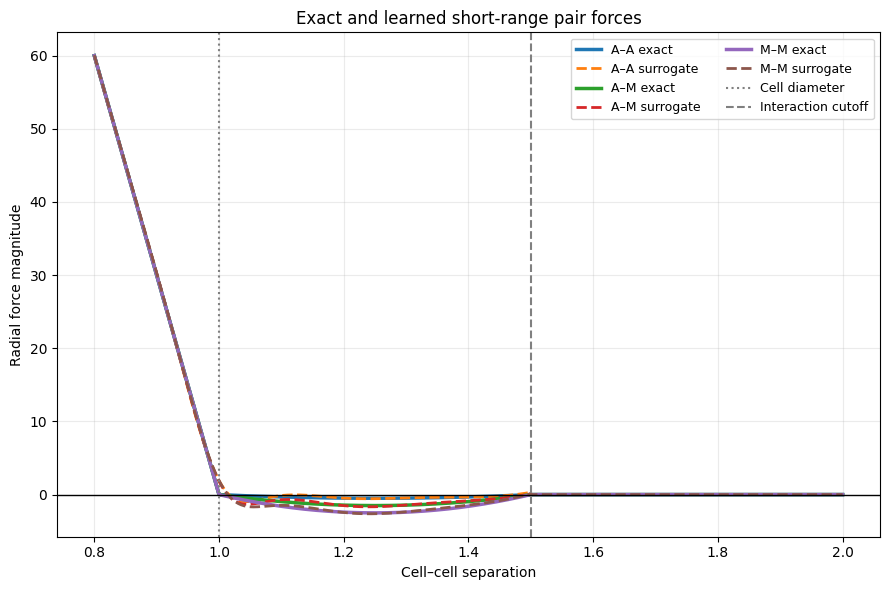

Figure saved to: outputs/short_range_force_surrogate.png


In [21]:
import matplotlib.pyplot as plt
force_curve_distances = np.linspace(
    0.80,
    2.00,
    500
).astype(np.float32)

pair_conditions = [
    (0, 0, "A–A", 0.2),
    (0, 1, "A–M", 0.6),
    (1, 1, "M–M", 1.0)
]

plt.figure(figsize=(9, 6))

for (
    phenotype_i,
    phenotype_j,
    condition_name,
    pair_factor
) in pair_conditions:

    force_curve_inputs = np.column_stack(
        [
            force_curve_distances,
            np.full(
                len(force_curve_distances),
                pair_factor
            )
        ]
    ).astype(np.float32)

    normalized_curve_inputs = (
        normalize_pair_inputs(
            force_curve_inputs
        )
    )

    with torch.inference_mode():

        predicted_curve_normalized = (
            pair_force_model(
                torch.tensor(
                    normalized_curve_inputs,
                    dtype=torch.float32,
                    device=device
                ),
                torch.tensor(
                    force_curve_distances,
                    dtype=torch.float32,
                    device=device
                )
            )
            .cpu()
            .numpy()
        )

    predicted_curve = (
        predicted_curve_normalized
        * pair_target_std
        + pair_target_mean
    )

    exact_curve = (
        exact_short_range_force_magnitude(
            force_curve_distances,
            np.full(
                len(force_curve_distances),
                phenotype_i
            ),
            np.full(
                len(force_curve_distances),
                phenotype_j
            )
        )
    )

    plt.plot(
        force_curve_distances,
        exact_curve,
        linewidth=2.5,
        label=f"{condition_name} exact"
    )

    plt.plot(
        force_curve_distances,
        predicted_curve,
        linestyle="--",
        linewidth=2,
        label=f"{condition_name} surrogate"
    )

    meaningful_attraction_mask = (
        exact_curve < -0.10
    )

    if meaningful_attraction_mask.any():

        meaningful_sign_accuracy = np.mean(
            predicted_curve[
                meaningful_attraction_mask
            ] < 0.0
        )

    else:
        meaningful_sign_accuracy = np.nan

    curve_rmse = np.sqrt(
        np.mean(
            (
                predicted_curve
                - exact_curve
            ) ** 2
        )
    )

    print(
        f"{condition_name} | "
        f"curve RMSE = {curve_rmse:.4f} | "
        f"meaningful-attraction sign accuracy = "
        f"{meaningful_sign_accuracy:.4f}"
    )

plt.axhline(
    0.0,
    color="black",
    linewidth=1
)

plt.axvline(
    effective_cell_diameter,
    color="gray",
    linestyle=":",
    label="Cell diameter"
)

plt.axvline(
    cell_cell_adhesion_range,
    color="gray",
    linestyle="--",
    label="Interaction cutoff"
)

plt.xlabel("Cell–cell separation")
plt.ylabel("Radial force magnitude")
plt.title(
    "Exact and learned short-range pair forces"
)

plt.grid(alpha=0.25)

plt.legend(
    ncol=2,
    fontsize=9
)

plt.tight_layout()

force_figure_path = (
    output_directory
    / "short_range_force_surrogate.png"
)

plt.savefig(
    force_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved to:",
    force_figure_path.resolve()
)

In [22]:
def surrogate_total_cell_cell_forces(
    positions,
    phenotypes
):
    positions = np.asarray(
        positions,
        dtype=np.float32
    )

    phenotypes = np.asarray(
        phenotypes,
        dtype=np.int64
    )

    number_of_cells = len(positions)

    pair_i, pair_j = np.triu_indices(
        number_of_cells,
        k=1
    )

    separation_vectors = (
        positions[pair_i]
        - positions[pair_j]
    )

    pair_distances = np.linalg.norm(
        separation_vectors,
        axis=1
    )

    safe_distances = np.maximum(
        pair_distances,
        1.0e-8
    )

    unit_vectors = (
        separation_vectors
        / safe_distances[:, None]
    )

    pair_factors = phenotype_pair_adhesion(
        phenotypes[pair_i],
        phenotypes[pair_j]
    ).astype(np.float32)

    pair_model_inputs = np.column_stack(
        [
            pair_distances,
            pair_factors
        ]
    ).astype(np.float32)

    normalized_pair_inputs = (
        normalize_pair_inputs(
            pair_model_inputs
        )
    )

    with torch.inference_mode():

        predicted_magnitude_normalized = (
            pair_force_model(
                torch.tensor(
                    normalized_pair_inputs,
                    dtype=torch.float32,
                    device=device
                ),
                torch.tensor(
                    pair_distances,
                    dtype=torch.float32,
                    device=device
                )
            )
            .cpu()
            .numpy()
        )

    predicted_magnitudes = (
        predicted_magnitude_normalized
        * pair_target_std
        + pair_target_mean
    )

    pair_forces = (
        predicted_magnitudes[:, None]
        * unit_vectors
    )

    total_forces = np.zeros_like(
        positions
    )

    np.add.at(
        total_forces,
        pair_i,
        pair_forces
    )

    np.add.at(
        total_forces,
        pair_j,
        -pair_forces
    )

    return total_forces


def exact_total_cell_cell_forces(
    positions,
    phenotypes
):
    positions = np.asarray(
        positions,
        dtype=np.float32
    )

    phenotypes = np.asarray(
        phenotypes,
        dtype=np.int64
    )

    number_of_cells = len(positions)

    pair_i, pair_j = np.triu_indices(
        number_of_cells,
        k=1
    )

    separation_vectors = (
        positions[pair_i]
        - positions[pair_j]
    )

    pair_distances = np.linalg.norm(
        separation_vectors,
        axis=1
    )

    safe_distances = np.maximum(
        pair_distances,
        1.0e-8
    )

    unit_vectors = (
        separation_vectors
        / safe_distances[:, None]
    )

    exact_magnitudes = (
        exact_short_range_force_magnitude(
            pair_distances,
            phenotypes[pair_i],
            phenotypes[pair_j]
        )
    )

    pair_forces = (
        exact_magnitudes[:, None]
        * unit_vectors
    )

    total_forces = np.zeros_like(
        positions
    )

    np.add.at(
        total_forces,
        pair_i,
        pair_forces
    )

    np.add.at(
        total_forces,
        pair_j,
        -pair_forces
    )

    return total_forces


# Create a 4 × 4 test colony
test_grid_x, test_grid_y = np.meshgrid(
    np.arange(4),
    np.arange(4)
)

test_colony_positions = np.column_stack(
    [
        test_grid_x.ravel(),
        test_grid_y.ravel()
    ]
).astype(np.float32)

test_colony_rng = np.random.default_rng(
    65000
)

test_colony_positions = (
    1.05 * test_colony_positions
    + test_colony_rng.normal(
        scale=0.08,
        size=test_colony_positions.shape
    )
).astype(np.float32)

test_colony_phenotypes = (
    test_colony_rng.integers(
        0,
        2,
        size=16
    )
)

exact_colony_forces = (
    exact_total_cell_cell_forces(
        test_colony_positions,
        test_colony_phenotypes
    )
)

surrogate_colony_forces = (
    surrogate_total_cell_cell_forces(
        test_colony_positions,
        test_colony_phenotypes
    )
)

colony_force_rmse = np.sqrt(
    np.mean(
        (
            surrogate_colony_forces
            - exact_colony_forces
        ) ** 2
    )
)

exact_force_scale = np.sqrt(
    np.mean(
        exact_colony_forces**2
    )
)

relative_colony_force_error = (
    100.0
    * colony_force_rmse
    / max(exact_force_scale, 1.0e-12)
)

print(
    "Cell-force RMSE:",
    colony_force_rmse
)

print(
    "Exact force RMS:",
    exact_force_scale
)

print(
    "Relative cell-force error:",
    relative_colony_force_error,
    "%"
)

print(
    "Exact net internal force:",
    exact_colony_forces.sum(axis=0)
)

print(
    "Surrogate net internal force:",
    surrogate_colony_forces.sum(axis=0)
)

print(
    "Maximum cell-force error:",
    np.max(
        np.linalg.norm(
            surrogate_colony_forces
            - exact_colony_forces,
            axis=1
        )
    )
)

print(
    "All colony forces finite:",
    np.isfinite(
        surrogate_colony_forces
    ).all()
)

Cell-force RMSE: 0.51389873
Exact force RMS: 10.196603
Relative cell-force error: 5.03990141895094 %
Exact net internal force: [-9.536743e-07 -2.861023e-06]
Surrogate net internal force: [1.668930e-06 9.536743e-07]
Maximum cell-force error: 1.3911269
All colony forces finite: True


In [23]:
def batched_surrogate_colony_forces(
    ensemble_positions,
    ensemble_phenotypes
):
    ensemble_positions = np.asarray(
        ensemble_positions,
        dtype=np.float32
    )

    ensemble_phenotypes = np.asarray(
        ensemble_phenotypes,
        dtype=np.int64
    )

    ensemble_size = (
        ensemble_positions.shape[0]
    )

    number_of_cells = (
        ensemble_positions.shape[1]
    )

    pair_i, pair_j = np.triu_indices(
        number_of_cells,
        k=1
    )

    separation_vectors = (
        ensemble_positions[:, pair_i, :]
        - ensemble_positions[:, pair_j, :]
    )

    pair_distances = np.linalg.norm(
        separation_vectors,
        axis=2
    )

    safe_distances = np.maximum(
        pair_distances,
        1.0e-8
    )

    unit_vectors = (
        separation_vectors
        / safe_distances[:, :, None]
    )

    pair_factors = phenotype_pair_adhesion(
        ensemble_phenotypes[:, pair_i],
        ensemble_phenotypes[:, pair_j]
    ).astype(np.float32)

    flat_pair_inputs = np.column_stack(
        [
            pair_distances.ravel(),
            pair_factors.ravel()
        ]
    ).astype(np.float32)

    normalized_flat_inputs = (
        normalize_pair_inputs(
            flat_pair_inputs
        )
    )

    with torch.inference_mode():

        flat_force_normalized = (
            pair_force_model(
                torch.from_numpy(
                    normalized_flat_inputs
                ).to(device),
                torch.from_numpy(
                    pair_distances.ravel().astype(
                        np.float32
                    )
                ).to(device)
            )
            .cpu()
            .numpy()
        )

    flat_force_magnitude = (
        flat_force_normalized
        * pair_target_std
        + pair_target_mean
    )

    pair_force_vectors = (
        flat_force_magnitude.reshape(
            ensemble_size,
            -1,
            1
        )
        * unit_vectors
    )

    total_forces = np.zeros_like(
        ensemble_positions
    )

    ensemble_indices = np.repeat(
        np.arange(ensemble_size),
        len(pair_i)
    )

    repeated_pair_i = np.tile(
        pair_i,
        ensemble_size
    )

    repeated_pair_j = np.tile(
        pair_j,
        ensemble_size
    )

    flat_pair_forces = (
        pair_force_vectors.reshape(-1, 2)
    )

    np.add.at(
        total_forces,
        (
            ensemble_indices,
            repeated_pair_i
        ),
        flat_pair_forces
    )

    np.add.at(
        total_forces,
        (
            ensemble_indices,
            repeated_pair_j
        ),
        -flat_pair_forces
    )

    return total_forces


def batched_exact_colony_forces(
    ensemble_positions,
    ensemble_phenotypes
):
    ensemble_positions = np.asarray(
        ensemble_positions,
        dtype=np.float32
    )

    ensemble_phenotypes = np.asarray(
        ensemble_phenotypes,
        dtype=np.int64
    )

    ensemble_size = (
        ensemble_positions.shape[0]
    )

    number_of_cells = (
        ensemble_positions.shape[1]
    )

    pair_i, pair_j = np.triu_indices(
        number_of_cells,
        k=1
    )

    separation_vectors = (
        ensemble_positions[:, pair_i, :]
        - ensemble_positions[:, pair_j, :]
    )

    pair_distances = np.linalg.norm(
        separation_vectors,
        axis=2
    )

    safe_distances = np.maximum(
        pair_distances,
        1.0e-8
    )

    unit_vectors = (
        separation_vectors
        / safe_distances[:, :, None]
    )

    exact_magnitudes = (
        exact_short_range_force_magnitude(
            pair_distances.ravel(),
            ensemble_phenotypes[
                :, pair_i
            ].ravel(),
            ensemble_phenotypes[
                :, pair_j
            ].ravel()
        )
        .reshape(
            ensemble_size,
            -1
        )
    )

    pair_force_vectors = (
        exact_magnitudes[:, :, None]
        * unit_vectors
    )

    total_forces = np.zeros_like(
        ensemble_positions
    )

    ensemble_indices = np.repeat(
        np.arange(ensemble_size),
        len(pair_i)
    )

    repeated_pair_i = np.tile(
        pair_i,
        ensemble_size
    )

    repeated_pair_j = np.tile(
        pair_j,
        ensemble_size
    )

    flat_pair_forces = (
        pair_force_vectors.reshape(-1, 2)
    )

    np.add.at(
        total_forces,
        (
            ensemble_indices,
            repeated_pair_i
        ),
        flat_pair_forces
    )

    np.add.at(
        total_forces,
        (
            ensemble_indices,
            repeated_pair_j
        ),
        -flat_pair_forces
    )

    return total_forces


# Create 100 perturbed copies of the test colony
force_benchmark_rng = np.random.default_rng(
    66000
)

force_benchmark_ensemble_size = 100

force_benchmark_positions = (
    test_colony_positions[
        np.newaxis, :, :
    ]
    + force_benchmark_rng.normal(
        scale=0.05,
        size=(
            force_benchmark_ensemble_size,
            16,
            2
        )
    )
).astype(np.float32)

force_benchmark_phenotypes = (
    force_benchmark_rng.integers(
        0,
        2,
        size=(
            force_benchmark_ensemble_size,
            16
        )
    )
)

# Warm-up
_ = batched_surrogate_colony_forces(
    force_benchmark_positions,
    force_benchmark_phenotypes
)

_ = batched_exact_colony_forces(
    force_benchmark_positions,
    force_benchmark_phenotypes
)

benchmark_repetitions = 100

start_time = time.perf_counter()

for _ in range(benchmark_repetitions):

    batched_learned_forces = (
        batched_surrogate_colony_forces(
            force_benchmark_positions,
            force_benchmark_phenotypes
        )
    )

surrogate_force_runtime = (
    time.perf_counter()
    - start_time
) / benchmark_repetitions

start_time = time.perf_counter()

for _ in range(benchmark_repetitions):

    batched_physical_forces = (
        batched_exact_colony_forces(
            force_benchmark_positions,
            force_benchmark_phenotypes
        )
    )

exact_force_runtime = (
    time.perf_counter()
    - start_time
) / benchmark_repetitions

ensemble_force_rmse = np.sqrt(
    np.mean(
        (
            batched_learned_forces
            - batched_physical_forces
        ) ** 2
    )
)

ensemble_force_scale = np.sqrt(
    np.mean(
        batched_physical_forces**2
    )
)

print(
    "Pairs evaluated per call:",
    force_benchmark_ensemble_size
    * 16 * 15 // 2
)

print(
    "Surrogate force time per call:",
    surrogate_force_runtime
)

print(
    "Exact vectorized time per call:",
    exact_force_runtime
)

print(
    "Surrogate/exact runtime ratio:",
    surrogate_force_runtime
    / exact_force_runtime
)

print(
    "Ensemble force RMSE:",
    ensemble_force_rmse
)

print(
    "Ensemble relative force error:",
    100.0
    * ensemble_force_rmse
    / ensemble_force_scale,
    "%"
)

print(
    "Maximum surrogate net internal force:",
    np.max(
        np.linalg.norm(
            batched_learned_forces.sum(
                axis=1
            ),
            axis=1
        )
    )
)

print(
    "All batched forces finite:",
    np.isfinite(
        batched_learned_forces
    ).all()
)

Pairs evaluated per call: 12000
Surrogate force time per call: 0.006109438149997004
Exact vectorized time per call: 0.0022034542900019006
Surrogate/exact runtime ratio: 2.772663893105645
Ensemble force RMSE: 0.6061797
Ensemble relative force error: 3.680739894006356 %
Maximum surrogate net internal force: 1.9168616e-05
All batched forces finite: True


In [24]:
def original_loop_colony_forces(
    positions,
    phenotypes
):
    positions = np.asarray(
        positions,
        dtype=np.float32
    )

    number_of_cells = len(positions)

    total_forces = np.zeros_like(
        positions
    )

    for i in range(number_of_cells):

        for j in range(
            i + 1,
            number_of_cells
        ):
            separation_vector = (
                positions[i]
                - positions[j]
            )

            distance = np.linalg.norm(
                separation_vector
            )

            if distance < 1.0e-8:
                continue

            unit_vector = (
                separation_vector
                / distance
            )

            if (
                phenotypes[i] == 1
                and phenotypes[j] == 1
            ):
                pair_factor = 1.0

            elif (
                phenotypes[i] == 1
                or phenotypes[j] == 1
            ):
                pair_factor = 0.6

            else:
                pair_factor = 0.2

            if (
                distance
                < effective_cell_diameter
            ):
                force_magnitude = (
                    hard_core_stiffness
                    * (
                        effective_cell_diameter
                        - distance
                    )
                )

            elif (
                distance
                < cell_cell_adhesion_range
            ):
                adhesive_shape = (
                    (
                        distance
                        - effective_cell_diameter
                    )
                    * (
                        cell_cell_adhesion_range
                        - distance
                    )
                    / (
                        cell_cell_adhesion_range
                        - effective_cell_diameter
                    )
                )

                force_magnitude = (
                    -contact_adhesion_stiffness
                    * pair_factor
                    * adhesive_shape
                )

            else:
                force_magnitude = 0.0

            pair_force = (
                force_magnitude
                * unit_vector
            )

            total_forces[i] += pair_force
            total_forces[j] -= pair_force

    return total_forces


def original_loop_ensemble_forces(
    ensemble_positions,
    ensemble_phenotypes
):
    ensemble_forces = np.zeros_like(
        ensemble_positions
    )

    for member_index in range(
        len(ensemble_positions)
    ):
        ensemble_forces[member_index] = (
            original_loop_colony_forces(
                ensemble_positions[
                    member_index
                ],
                ensemble_phenotypes[
                    member_index
                ]
            )
        )

    return ensemble_forces


# Warm-up
_ = original_loop_ensemble_forces(
    force_benchmark_positions,
    force_benchmark_phenotypes
)

loop_benchmark_repetitions = 10

start_time = time.perf_counter()

for _ in range(
    loop_benchmark_repetitions
):
    original_loop_forces = (
        original_loop_ensemble_forces(
            force_benchmark_positions,
            force_benchmark_phenotypes
        )
    )

original_loop_runtime = (
    time.perf_counter()
    - start_time
) / loop_benchmark_repetitions

loop_vectorized_difference = np.max(
    np.abs(
        original_loop_forces
        - batched_physical_forces
    )
)

print(
    "Original nested-loop runtime:",
    original_loop_runtime
)

print(
    "Vectorized exact runtime:",
    exact_force_runtime
)

print(
    "Pair-surrogate runtime:",
    surrogate_force_runtime
)

print(
    "Vectorized exact speedup over loop:",
    original_loop_runtime
    / exact_force_runtime
)

print(
    "Pair-surrogate speedup over loop:",
    original_loop_runtime
    / surrogate_force_runtime
)

print(
    "Maximum loop/vectorized difference:",
    loop_vectorized_difference
)

Original nested-loop runtime: 0.15796964549999756
Vectorized exact runtime: 0.0022034542900019006
Pair-surrogate runtime: 0.006109438149997004
Vectorized exact speedup over loop: 71.69181871245503
Pair-surrogate speedup over loop: 25.8566568024058
Maximum loop/vectorized difference: 1.5258789e-05


In [25]:
pair_force_checkpoint_path = (
    output_directory
    / "short_range_pair_force_mlp.pt"
)

torch.save(
    {
        "model_state":
            pair_force_model.state_dict(),

        "input_mean":
            pair_input_mean,

        "input_std":
            pair_input_std,

        "target_mean":
            pair_target_mean,

        "target_std":
            pair_target_std,

        "effective_cell_diameter":
            effective_cell_diameter,

        "interaction_range":
            cell_cell_adhesion_range,

        "hard_core_stiffness":
            hard_core_stiffness,

        "contact_adhesion_stiffness":
            contact_adhesion_stiffness,

        "test_force_rmse":
            float(overall_force_rmse),

        "test_force_r_squared":
            float(force_r_squared),

        "colony_relative_force_error_percent":
            float(
                relative_colony_force_error
            ),

        "ensemble_relative_force_error_percent":
            float(
                100.0
                * ensemble_force_rmse
                / ensemble_force_scale
            )
    },
    pair_force_checkpoint_path
)

interaction_benchmark = {
    "pairs_per_call": 12000,
    "original_loop_runtime_seconds":
        float(original_loop_runtime),
    "pair_surrogate_runtime_seconds":
        float(surrogate_force_runtime),
    "vectorized_exact_runtime_seconds":
        float(exact_force_runtime),
    "pair_surrogate_speedup_over_loop":
        float(
            original_loop_runtime
            / surrogate_force_runtime
        ),
    "vectorized_exact_speedup_over_loop":
        float(
            original_loop_runtime
            / exact_force_runtime
        ),
    "surrogate_to_vectorized_exact_ratio":
        float(
            surrogate_force_runtime
            / exact_force_runtime
        ),
    "pair_test_r_squared":
        float(force_r_squared),
    "pair_test_rmse":
        float(overall_force_rmse),
    "ensemble_relative_force_error_percent":
        float(
            100.0
            * ensemble_force_rmse
            / ensemble_force_scale
        ),
    "maximum_surrogate_net_force":
        float(
            np.max(
                np.linalg.norm(
                    batched_learned_forces.sum(
                        axis=1
                    ),
                    axis=1
                )
            )
        )
}

interaction_benchmark_path = (
    output_directory
    / "interaction_surrogate_benchmark.json"
)

with open(
    interaction_benchmark_path,
    "w"
) as output_file:

    json.dump(
        interaction_benchmark,
        output_file,
        indent=2
    )

print(
    "Pair-force checkpoint saved to:",
    pair_force_checkpoint_path.resolve()
)

print(
    "Interaction benchmark saved to:",
    interaction_benchmark_path.resolve()
)

Pair-force checkpoint saved to: outputs/short_range_pair_force_mlp.pt
Interaction benchmark saved to: outputs/interaction_surrogate_benchmark.json


In [1]:
from pathlib import Path

output_directory = Path("outputs")

mlp_checkpoint_path = (
    output_directory
    / "physics_informed_mlp_surrogate.pt"
)

transformer_checkpoint_path = (
    output_directory
    / "probabilistic_transformer.pt"
)

pair_force_checkpoint_path = (
    output_directory
    / "short_range_pair_force_mlp.pt"
)

print("MLP:", mlp_checkpoint_path.exists())
print("Transformer:", transformer_checkpoint_path.exists())
print("Pair force:", pair_force_checkpoint_path.exists())

MLP: True
Transformer: True
Pair force: True


In [3]:
import numpy as np
import torch
from pathlib import Path

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

output_directory = (
    Path("outputs")
)

mlp_checkpoint_path = (
    output_directory
    / "physics_informed_mlp_surrogate.pt"
)

transformer_checkpoint_path = (
    output_directory
    / "probabilistic_transformer.pt"
)

pair_force_checkpoint_path = (
    output_directory
    / "short_range_pair_force_mlp.pt"
)

mlp_checkpoint = torch.load(
    mlp_checkpoint_path,
    map_location=device
)

transformer_checkpoint = torch.load(
    transformer_checkpoint_path,
    map_location=device
)

pair_force_checkpoint = torch.load(
    pair_force_checkpoint_path,
    map_location=device
)

print("Device:", device)

print(
    "\nMLP checkpoint keys:",
    list(mlp_checkpoint.keys())
)

print(
    "\nTransformer checkpoint keys:",
    list(transformer_checkpoint.keys())
)

print(
    "\nPair-force checkpoint keys:",
    list(pair_force_checkpoint.keys())
)

Device: cpu

MLP checkpoint keys: ['surrogate_model_state', 'phenotype_transition_state', 'velocity_input_mean', 'velocity_input_std', 'target_mean', 'target_std', 'velocity_variance_calibration', 'dt', 'D', 'tau_amoeboid', 'tau_mesenchymal', 'v_amoeboid', 'v_mesenchymal']

Transformer checkpoint keys: ['transformer_model_state', 'sequence_length', 'target_mean', 'target_std', 'model_dimension', 'number_of_heads', 'number_of_layers', 'phenotype_auc', 'phenotype_balanced_accuracy', 'phenotype_brier', 'continuous_rmse', 'coverage']

Pair-force checkpoint keys: ['model_state', 'input_mean', 'input_std', 'target_mean', 'target_std', 'effective_cell_diameter', 'interaction_range', 'hard_core_stiffness', 'contact_adhesion_stiffness', 'test_force_rmse', 'test_force_r_squared', 'colony_relative_force_error_percent', 'ensemble_relative_force_error_percent']


In [4]:
import numpy as np
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

mlp_checkpoint = torch.load(
    mlp_checkpoint_path,
    map_location=device
)

transformer_checkpoint = torch.load(
    transformer_checkpoint_path,
    map_location=device
)

pair_force_checkpoint = torch.load(
    pair_force_checkpoint_path,
    map_location=device
)

print("Device:", device)

print(
    "\nMLP checkpoint keys:",
    list(mlp_checkpoint.keys())
)

print(
    "\nTransformer checkpoint keys:",
    list(transformer_checkpoint.keys())
)

print(
    "\nPair-force checkpoint keys:",
    list(pair_force_checkpoint.keys())
)

Device: cpu

MLP checkpoint keys: ['surrogate_model_state', 'phenotype_transition_state', 'velocity_input_mean', 'velocity_input_std', 'target_mean', 'target_std', 'velocity_variance_calibration', 'dt', 'D', 'tau_amoeboid', 'tau_mesenchymal', 'v_amoeboid', 'v_mesenchymal']

Transformer checkpoint keys: ['transformer_model_state', 'sequence_length', 'target_mean', 'target_std', 'model_dimension', 'number_of_heads', 'number_of_layers', 'phenotype_auc', 'phenotype_balanced_accuracy', 'phenotype_brier', 'continuous_rmse', 'coverage']

Pair-force checkpoint keys: ['model_state', 'input_mean', 'input_std', 'target_mean', 'target_std', 'effective_cell_diameter', 'interaction_range', 'hard_core_stiffness', 'contact_adhesion_stiffness', 'test_force_rmse', 'test_force_r_squared', 'colony_relative_force_error_percent', 'ensemble_relative_force_error_percent']


In [5]:
def print_state_shapes(title, state_dictionary):
    print("\n" + title)

    for name, value in state_dictionary.items():
        print(
            f"{name:55s}",
            tuple(value.shape)
        )


print_state_shapes(
    "MLP STATE",
    mlp_checkpoint[
        "surrogate_model_state"
    ]
)

print_state_shapes(
    "PHENOTYPE HEAD STATE",
    mlp_checkpoint[
        "phenotype_transition_state"
    ]
)

print_state_shapes(
    "TRANSFORMER STATE",
    transformer_checkpoint[
        "transformer_model_state"
    ]
)

print_state_shapes(
    "PAIR-FORCE STATE",
    pair_force_checkpoint[
        "model_state"
    ]
)


MLP STATE
shared_network.0.weight                                 (64, 4)
shared_network.0.bias                                   (64,)
shared_network.2.weight                                 (64, 64)
shared_network.2.bias                                   (64,)
mean_head.weight                                        (4, 64)
mean_head.bias                                          (4,)
log_variance_head.weight                                (4, 64)
log_variance_head.bias                                  (4,)
phenotype_head.weight                                   (1, 64)
phenotype_head.bias                                     (1,)

PHENOTYPE HEAD STATE
transition_logits                                       (2, 2)

TRANSFORMER STATE
position_embedding                                      (1, 16, 32)
input_projection.weight                                 (32, 3)
input_projection.bias                                   (32,)
transformer_encoder.layers.0.self_attn.in_proj_weight   (96, 32

In [6]:
import torch
import torch.nn as nn
import numpy as np


# --------------------------------------------------
# 1. Restore saved parameters and normalization
# --------------------------------------------------

velocity_input_mean = np.asarray(
    mlp_checkpoint["velocity_input_mean"],
    dtype=np.float32
)

velocity_input_std = np.asarray(
    mlp_checkpoint["velocity_input_std"],
    dtype=np.float32
)

target_mean = np.asarray(
    mlp_checkpoint["target_mean"],
    dtype=np.float32
)

target_std = np.asarray(
    mlp_checkpoint["target_std"],
    dtype=np.float32
)

velocity_variance_calibration = np.asarray(
    mlp_checkpoint["velocity_variance_calibration"],
    dtype=np.float32
)

dt = float(mlp_checkpoint["dt"])
D = float(mlp_checkpoint["D"])

tau_amoeboid = float(
    mlp_checkpoint["tau_amoeboid"]
)

tau_mesenchymal = float(
    mlp_checkpoint["tau_mesenchymal"]
)

v_amoeboid = float(
    mlp_checkpoint["v_amoeboid"]
)

v_mesenchymal = float(
    mlp_checkpoint["v_mesenchymal"]
)


pair_input_mean = np.asarray(
    pair_force_checkpoint["input_mean"],
    dtype=np.float32
)

pair_input_std = np.asarray(
    pair_force_checkpoint["input_std"],
    dtype=np.float32
)

pair_target_mean = float(
    pair_force_checkpoint["target_mean"]
)

pair_target_std = float(
    pair_force_checkpoint["target_std"]
)

effective_cell_diameter = float(
    pair_force_checkpoint[
        "effective_cell_diameter"
    ]
)

interaction_range = float(
    pair_force_checkpoint[
        "interaction_range"
    ]
)

hard_core_stiffness = float(
    pair_force_checkpoint[
        "hard_core_stiffness"
    ]
)

contact_adhesion_stiffness = float(
    pair_force_checkpoint[
        "contact_adhesion_stiffness"
    ]
)


# --------------------------------------------------
# 2. Probabilistic MLP
# --------------------------------------------------

class ProbabilisticSurrogateMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.shared_network = nn.Sequential(
            nn.Linear(4, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU()
        )

        self.mean_head = nn.Linear(64, 4)

        self.log_variance_head = nn.Linear(
            64,
            4
        )

        self.phenotype_head = nn.Linear(
            64,
            1
        )

    def forward(self, inputs):
        hidden = self.shared_network(inputs)

        mean = self.mean_head(hidden)

        log_variance = torch.clamp(
            self.log_variance_head(hidden),
            min=-10.0,
            max=5.0
        )

        phenotype_logit = (
            self.phenotype_head(hidden)
            .squeeze(-1)
        )

        return (
            mean,
            log_variance,
            phenotype_logit
        )


# --------------------------------------------------
# 3. Structured phenotype transition
# --------------------------------------------------

class StructuredPhenotypeTransitionHead(
    nn.Module
):

    def __init__(self):
        super().__init__()

        self.transition_logits = nn.Parameter(
            torch.zeros(2, 2)
        )

    def forward(
        self,
        current_phenotype,
        flow_condition
    ):
        phenotype_index = (
            current_phenotype.long()
        )

        flow_index = flow_condition.long()

        return self.transition_logits[
            phenotype_index,
            flow_index
        ]


# --------------------------------------------------
# 4. Transformer
# --------------------------------------------------

class ProbabilisticTransitionTransformer(
    nn.Module
):

    def __init__(
        self,
        sequence_length=16,
        model_dimension=32,
        number_of_heads=4,
        number_of_layers=2
    ):
        super().__init__()

        self.sequence_length = sequence_length

        self.position_embedding = nn.Parameter(
            torch.zeros(
                1,
                sequence_length,
                model_dimension
            )
        )

        self.input_projection = nn.Linear(
            3,
            model_dimension
        )

        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=model_dimension,
                nhead=number_of_heads,
                dim_feedforward=64,
                dropout=0.1,
                activation="gelu",
                batch_first=True,
                norm_first=True
            )
        )

        self.transformer_encoder = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=number_of_layers
            )
        )

        self.final_normalization = nn.LayerNorm(
            model_dimension
        )

        self.mean_head = nn.Linear(
            model_dimension,
            4
        )

        self.log_variance_head = nn.Linear(
            model_dimension,
            4
        )

        self.phenotype_head = nn.Linear(
            model_dimension,
            1
        )

    def forward(self, sequence):
        hidden = self.input_projection(sequence)

        hidden = (
            hidden
            + self.position_embedding[
                :,
                :sequence.shape[1]
            ]
        )

        hidden = self.transformer_encoder(
            hidden
        )

        final_hidden = (
            self.final_normalization(
                hidden[:, -1]
            )
        )

        mean = self.mean_head(final_hidden)

        log_variance = torch.clamp(
            self.log_variance_head(
                final_hidden
            ),
            min=-10.0,
            max=5.0
        )

        phenotype_logit = (
            self.phenotype_head(final_hidden)
            .squeeze(-1)
        )

        return (
            mean,
            log_variance,
            phenotype_logit
        )


# --------------------------------------------------
# 5. Short-range pair-force model
# --------------------------------------------------

class ShortRangePairForceMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )

    def forward(self, normalized_inputs):
        return (
            self.network(normalized_inputs)
            .squeeze(-1)
        )


# --------------------------------------------------
# 6. Create and load all models
# --------------------------------------------------

surrogate_model = (
    ProbabilisticSurrogateMLP()
    .to(device)
)

phenotype_transition_head = (
    StructuredPhenotypeTransitionHead()
    .to(device)
)

transformer_model = (
    ProbabilisticTransitionTransformer(
        sequence_length=int(
            transformer_checkpoint[
                "sequence_length"
            ]
        ),
        model_dimension=int(
            transformer_checkpoint[
                "model_dimension"
            ]
        ),
        number_of_heads=int(
            transformer_checkpoint[
                "number_of_heads"
            ]
        ),
        number_of_layers=int(
            transformer_checkpoint[
                "number_of_layers"
            ]
        )
    )
    .to(device)
)

pair_force_model = (
    ShortRangePairForceMLP()
    .to(device)
)


surrogate_model.load_state_dict(
    mlp_checkpoint[
        "surrogate_model_state"
    ]
)

phenotype_transition_head.load_state_dict(
    mlp_checkpoint[
        "phenotype_transition_state"
    ]
)

transformer_model.load_state_dict(
    transformer_checkpoint[
        "transformer_model_state"
    ]
)

pair_force_model.load_state_dict(
    pair_force_checkpoint[
        "model_state"
    ]
)


surrogate_model.eval()
phenotype_transition_head.eval()
transformer_model.eval()
pair_force_model.eval()


# --------------------------------------------------
# 7. Basic restoration checks
# --------------------------------------------------

with torch.no_grad():

    test_mlp_input = torch.zeros(
        (8, 4),
        dtype=torch.float32,
        device=device
    )

    (
        test_mean,
        test_log_variance,
        test_phenotype_logit
    ) = surrogate_model(test_mlp_input)

    test_pair_input = torch.zeros(
        (8, 2),
        dtype=torch.float32,
        device=device
    )

    test_pair_output = pair_force_model(
        test_pair_input
    )

    test_transformer_input = torch.zeros(
        (
            8,
            int(
                transformer_checkpoint[
                    "sequence_length"
                ]
            ),
            3
        ),
        dtype=torch.float32,
        device=device
    )

    (
        test_transformer_mean,
        test_transformer_log_variance,
        test_transformer_phenotype
    ) = transformer_model(
        test_transformer_input
    )


print("All checkpoints restored successfully.")

print(
    "MLP outputs finite:",
    bool(
        torch.isfinite(test_mean).all()
        and torch.isfinite(
            test_log_variance
        ).all()
    )
)

print(
    "Phenotype head finite:",
    bool(
        torch.isfinite(
            phenotype_transition_head
            .transition_logits
        ).all()
    )
)

print(
    "Transformer outputs finite:",
    bool(
        torch.isfinite(
            test_transformer_mean
        ).all()
    )
)

print(
    "Pair-force outputs finite:",
    bool(
        torch.isfinite(
            test_pair_output
        ).all()
    )
)

print(
    "Transition probabilities:",
    torch.sigmoid(
        phenotype_transition_head
        .transition_logits
    )
    .detach()
    .cpu()
    .numpy()
)

All checkpoints restored successfully.
MLP outputs finite: True
Phenotype head finite: True
Transformer outputs finite: True
Pair-force outputs finite: True
Transition probabilities: [[0.00732708 0.00338278]
 [0.99482685 0.99087954]]


/usr/local/lib/python3.9/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [7]:
def calculate_surrogate_cell_cell_forces(
    ensemble_positions,
    ensemble_phenotypes
):
    """
    Calculate cell-cell forces for an entire ensemble.

    Parameters
    ----------
    ensemble_positions:
        Shape (ensemble_size, number_of_cells, 2)

    ensemble_phenotypes:
        Shape (ensemble_size, number_of_cells)
        0 = amoeboid
        1 = mesenchymal

    Returns
    -------
    forces:
        Shape (ensemble_size, number_of_cells, 2)
    """

    positions = np.asarray(
        ensemble_positions,
        dtype=np.float32
    )

    phenotypes = np.asarray(
        ensemble_phenotypes,
        dtype=np.float32
    )

    ensemble_size = positions.shape[0]
    number_of_cells = positions.shape[1]

    forces = np.zeros_like(
        positions,
        dtype=np.float32
    )

    # Evaluate every pair only once
    cell_i, cell_j = np.triu_indices(
        number_of_cells,
        k=1
    )

    # Vector from cell j to cell i
    pair_displacements = (
        positions[:, cell_i, :]
        - positions[:, cell_j, :]
    )

    pair_distances = np.linalg.norm(
        pair_displacements,
        axis=2
    )

    safe_distances = np.maximum(
        pair_distances,
        1.0e-6
    )

    pair_directions = (
        pair_displacements
        / safe_distances[:, :, np.newaxis]
    )

    # Pair adhesion scale:
    # A-A = 0.2
    # A-M = 0.6
    # M-M = 1.0
    pair_factors = (
        0.2
        + 0.4
        * (
            phenotypes[:, cell_i]
            + phenotypes[:, cell_j]
        )
    )

    active_pair_mask = (
        pair_distances
        < interaction_range
    )

    # Avoid sending distances far below the
    # force network's training domain.
    network_distances = np.maximum(
        pair_distances,
        0.8 * effective_cell_diameter
    )

    pair_inputs = np.stack(
        [
            network_distances,
            pair_factors
        ],
        axis=-1
    )

    normalized_pair_inputs = (
        (
            pair_inputs
            - pair_input_mean[
                np.newaxis,
                np.newaxis,
                :
            ]
        )
        / pair_input_std[
            np.newaxis,
            np.newaxis,
            :
        ]
    ).astype(np.float32)

    flat_pair_inputs = (
        normalized_pair_inputs.reshape(
            -1,
            2
        )
    )

    with torch.no_grad():

        normalized_force_magnitudes = (
            pair_force_model(
                torch.from_numpy(
                    flat_pair_inputs
                ).to(device)
            )
            .cpu()
            .numpy()
        )

    force_magnitudes = (
        pair_target_mean
        + pair_target_std
        * normalized_force_magnitudes
    ).reshape(
        ensemble_size,
        -1
    )

    # The exact force is zero outside its cutoff.
    force_magnitudes = np.where(
        active_pair_mask,
        force_magnitudes,
        0.0
    )

    pair_force_vectors = (
        force_magnitudes[:, :, np.newaxis]
        * pair_directions
    )

    # Apply equal and opposite forces
    for pair_index in range(
        len(cell_i)
    ):
        forces[
            :,
            cell_i[pair_index],
            :
        ] += pair_force_vectors[
            :,
            pair_index,
            :
        ]

        forces[
            :,
            cell_j[pair_index],
            :
        ] -= pair_force_vectors[
            :,
            pair_index,
            :
        ]

    return forces

In [8]:
force_test_positions = np.array(
    [
        [
            [-0.6, 0.0],
            [ 0.6, 0.0],
            [ 4.0, 0.0]
        ],
        [
            [-0.6, 0.0],
            [ 0.6, 0.0],
            [ 4.0, 0.0]
        ]
    ],
    dtype=np.float32
)

force_test_phenotypes = np.array(
    [
        [0, 0, 0],
        [1, 1, 0]
    ],
    dtype=np.float32
)

force_test_result = (
    calculate_surrogate_cell_cell_forces(
        force_test_positions,
        force_test_phenotypes
    )
)

print(
    "Force result shape:",
    force_test_result.shape
)

print(
    "A-A forces:",
    force_test_result[0]
)

print(
    "M-M forces:",
    force_test_result[1]
)

print(
    "Net force A-A:",
    force_test_result[0].sum(axis=0)
)

print(
    "Net force M-M:",
    force_test_result[1].sum(axis=0)
)

print(
    "All forces finite:",
    np.isfinite(
        force_test_result
    ).all()
)

Force result shape: (2, 3, 2)
A-A forces: [[ 0.47838497  0.        ]
 [-0.47838497  0.        ]
 [ 0.          0.        ]]
M-M forces: [[ 2.444746  0.      ]
 [-2.444746  0.      ]
 [ 0.        0.      ]]
Net force A-A: [0. 0.]
Net force M-M: [0. 0.]
All forces finite: True


In [9]:
# Interaction mobility used in the mechanistic
# colony model
surrogate_cell_mobility = 0.01


def resolve_surrogate_overlaps(
    positions,
    cell_diameter,
    number_of_passes=5
):
    """
    Enforce excluded volume independently
    for every ensemble member.
    """

    corrected_positions = np.asarray(
        positions,
        dtype=np.float32
    ).copy()

    ensemble_size = (
        corrected_positions.shape[0]
    )

    number_of_cells = (
        corrected_positions.shape[1]
    )

    cell_i, cell_j = np.triu_indices(
        number_of_cells,
        k=1
    )

    for _ in range(number_of_passes):

        pair_displacements = (
            corrected_positions[:, cell_i, :]
            - corrected_positions[:, cell_j, :]
        )

        pair_distances = np.linalg.norm(
            pair_displacements,
            axis=2
        )

        overlap_mask = (
            pair_distances
            < cell_diameter
        )

        if not np.any(overlap_mask):
            break

        safe_distances = np.maximum(
            pair_distances,
            1.0e-6
        )

        pair_directions = (
            pair_displacements
            / safe_distances[:, :, np.newaxis]
        )

        # Handle the extremely unlikely case of
        # exactly identical positions.
        zero_distance_mask = (
            pair_distances < 1.0e-6
        )

        if np.any(zero_distance_mask):
            pair_directions[
                zero_distance_mask
            ] = np.array(
                [1.0, 0.0],
                dtype=np.float32
            )

        overlap_amounts = np.maximum(
            cell_diameter - pair_distances,
            0.0
        )

        corrections = (
            0.5
            * overlap_amounts[:, :, np.newaxis]
            * pair_directions
        )

        corrections *= (
            overlap_mask[:, :, np.newaxis]
        )

        for pair_index in range(
            len(cell_i)
        ):
            corrected_positions[
                :,
                cell_i[pair_index],
                :
            ] += corrections[
                :,
                pair_index,
                :
            ]

            corrected_positions[
                :,
                cell_j[pair_index],
                :
            ] -= corrections[
                :,
                pair_index,
                :
            ]

    return corrected_positions


def surrogate_colony_step(
    positions,
    velocities,
    phenotypes,
    flow_condition,
    rng
):
    """
    One probabilistic colony transition using:

    1. learned single-cell motility;
    2. structured phenotype switching;
    3. learned short-range cell-cell forces;
    4. excluded-volume correction.
    """

    positions = np.asarray(
        positions,
        dtype=np.float32
    )

    velocities = np.asarray(
        velocities,
        dtype=np.float32
    )

    phenotypes = np.asarray(
        phenotypes,
        dtype=np.float32
    )

    ensemble_size = positions.shape[0]
    number_of_cells = positions.shape[1]

    flow_values = np.full(
        (
            ensemble_size,
            number_of_cells
        ),
        float(flow_condition),
        dtype=np.float32
    )

    normalized_velocities = (
        (
            velocities
            - velocity_input_mean[
                np.newaxis,
                np.newaxis,
                :
            ]
        )
        / velocity_input_std[
            np.newaxis,
            np.newaxis,
            :
        ]
    )

    model_inputs = np.concatenate(
        [
            normalized_velocities,
            phenotypes[
                :,
                :,
                np.newaxis
            ],
            flow_values[
                :,
                :,
                np.newaxis
            ]
        ],
        axis=2
    ).astype(np.float32)

    flat_model_inputs = model_inputs.reshape(
        -1,
        4
    )

    with torch.no_grad():

        (
            normalized_means,
            normalized_log_variances,
            _
        ) = surrogate_model(
            torch.from_numpy(
                flat_model_inputs
            ).to(device)
        )

        normalized_means = (
            normalized_means
            .cpu()
            .numpy()
        )

        normalized_variances = (
            torch.exp(
                normalized_log_variances
            )
            .cpu()
            .numpy()
        )

    continuous_means = (
        target_mean[np.newaxis, :]
        + target_std[np.newaxis, :]
        * normalized_means
    )

    continuous_variances = (
        target_std[np.newaxis, :] ** 2
        * normalized_variances
    )

    # Apply the saved calibration only to
    # the two velocity-output variances.
    continuous_variances[:, 2:4] *= (
        velocity_variance_calibration[
            np.newaxis,
            :
        ]
    )

    continuous_standard_deviations = np.sqrt(
        np.maximum(
            continuous_variances,
            1.0e-10
        )
    )

    sampled_continuous_outputs = (
        continuous_means
        + continuous_standard_deviations
        * rng.normal(
            size=continuous_means.shape
        )
    )

    sampled_continuous_outputs = (
        sampled_continuous_outputs.reshape(
            ensemble_size,
            number_of_cells,
            4
        )
        .astype(np.float32)
    )

    learned_displacements = (
        sampled_continuous_outputs[:, :, 0:2]
    )

    next_velocities = (
        sampled_continuous_outputs[:, :, 2:4]
    )

    # Structured phenotype transition
    with torch.no_grad():

        phenotype_logits = (
            phenotype_transition_head(
                torch.from_numpy(
                    phenotypes.reshape(-1)
                ).to(device),
                torch.from_numpy(
                    flow_values.reshape(-1)
                ).to(device)
            )
        )

        mesenchymal_probabilities = (
            torch.sigmoid(
                phenotype_logits
            )
            .cpu()
            .numpy()
            .reshape(
                ensemble_size,
                number_of_cells
            )
        )

    next_phenotypes = (
        rng.random(
            size=mesenchymal_probabilities.shape
        )
        < mesenchymal_probabilities
    ).astype(np.float32)

    # Use the current configuration for the
    # force acting during this time step.
    interaction_forces = (
        calculate_surrogate_cell_cell_forces(
            positions,
            phenotypes
        )
    )

    interaction_displacements = (
        surrogate_cell_mobility
        * interaction_forces
        * dt
    )

    next_positions = (
        positions
        + learned_displacements
        + interaction_displacements
    )

    next_positions = resolve_surrogate_overlaps(
        next_positions,
        cell_diameter=effective_cell_diameter,
        number_of_passes=5
    )

    return (
        next_positions.astype(np.float32),
        next_velocities.astype(np.float32),
        next_phenotypes.astype(np.float32),
        mesenchymal_probabilities.astype(
            np.float32
        ),
        interaction_forces.astype(np.float32)
    )

In [10]:
smoke_rng = np.random.default_rng(61000)

smoke_ensemble_size = 20
smoke_number_of_cells = 16

grid_side = 4

grid_x, grid_y = np.meshgrid(
    np.arange(grid_side),
    np.arange(grid_side)
)

smoke_initial_single = np.column_stack(
    [
        grid_x.ravel(),
        grid_y.ravel()
    ]
).astype(np.float32)

smoke_initial_single *= (
    1.25 * effective_cell_diameter
)

smoke_positions = np.repeat(
    smoke_initial_single[
        np.newaxis,
        :,
        :
    ],
    smoke_ensemble_size,
    axis=0
)

smoke_velocities = smoke_rng.normal(
    scale=1.0,
    size=(
        smoke_ensemble_size,
        smoke_number_of_cells,
        2
    )
).astype(np.float32)

smoke_phenotypes = (
    smoke_rng.random(
        size=(
            smoke_ensemble_size,
            smoke_number_of_cells
        )
    )
    < 0.27
).astype(np.float32)

for smoke_step in range(10):

    (
        smoke_positions,
        smoke_velocities,
        smoke_phenotypes,
        smoke_probabilities,
        smoke_forces
    ) = surrogate_colony_step(
        smoke_positions,
        smoke_velocities,
        smoke_phenotypes,
        flow_condition=1.0,
        rng=smoke_rng
    )


def minimum_ensemble_separation(
    positions
):
    number_of_cells = positions.shape[1]

    cell_i, cell_j = np.triu_indices(
        number_of_cells,
        k=1
    )

    distances = np.linalg.norm(
        positions[:, cell_i, :]
        - positions[:, cell_j, :],
        axis=2
    )

    return distances.min()


print(
    "Final position shape:",
    smoke_positions.shape
)

print(
    "Final velocity shape:",
    smoke_velocities.shape
)

print(
    "Final phenotype shape:",
    smoke_phenotypes.shape
)

print(
    "Final mesenchymal fraction:",
    smoke_phenotypes.mean()
)

print(
    "Minimum cell separation:",
    minimum_ensemble_separation(
        smoke_positions
    )
)

print(
    "Mean interaction-force magnitude:",
    np.linalg.norm(
        smoke_forces,
        axis=2
    ).mean()
)

print(
    "All positions finite:",
    np.isfinite(
        smoke_positions
    ).all()
)

print(
    "All velocities finite:",
    np.isfinite(
        smoke_velocities
    ).all()
)

Final position shape: (20, 16, 2)
Final velocity shape: (20, 16, 2)
Final phenotype shape: (20, 16)
Final mesenchymal fraction: 0.265625
Minimum cell separation: 0.96212286
Mean interaction-force magnitude: 1.649297
All positions finite: True
All velocities finite: True


In [11]:
# Save the current function
surrogate_colony_step_base = (
    surrogate_colony_step
)


# Replace it with a stricter version
def surrogate_colony_step(
    positions,
    velocities,
    phenotypes,
    flow_condition,
    rng
):
    (
        next_positions,
        next_velocities,
        next_phenotypes,
        mesenchymal_probabilities,
        interaction_forces
    ) = surrogate_colony_step_base(
        positions,
        velocities,
        phenotypes,
        flow_condition,
        rng
    )

    # Additional excluded-volume correction
    next_positions = resolve_surrogate_overlaps(
        next_positions,
        cell_diameter=effective_cell_diameter,
        number_of_passes=25
    )

    return (
        next_positions,
        next_velocities,
        next_phenotypes,
        mesenchymal_probabilities,
        interaction_forces
    )


# -----------------------------------------
# Repeat the smoke test from the beginning
# -----------------------------------------

smoke_rng = np.random.default_rng(61000)

smoke_ensemble_size = 20
smoke_number_of_cells = 16

grid_x, grid_y = np.meshgrid(
    np.arange(4),
    np.arange(4)
)

smoke_initial_single = np.column_stack(
    [
        grid_x.ravel(),
        grid_y.ravel()
    ]
).astype(np.float32)

smoke_initial_single *= (
    1.25 * effective_cell_diameter
)

smoke_positions = np.repeat(
    smoke_initial_single[
        np.newaxis,
        :,
        :
    ],
    smoke_ensemble_size,
    axis=0
)

smoke_velocities = smoke_rng.normal(
    scale=1.0,
    size=(
        smoke_ensemble_size,
        smoke_number_of_cells,
        2
    )
).astype(np.float32)

smoke_phenotypes = (
    smoke_rng.random(
        size=(
            smoke_ensemble_size,
            smoke_number_of_cells
        )
    )
    < 0.27
).astype(np.float32)

for smoke_step in range(10):

    (
        smoke_positions,
        smoke_velocities,
        smoke_phenotypes,
        smoke_probabilities,
        smoke_forces
    ) = surrogate_colony_step(
        smoke_positions,
        smoke_velocities,
        smoke_phenotypes,
        flow_condition=1.0,
        rng=smoke_rng
    )


def minimum_ensemble_separation(
    positions
):
    number_of_cells = positions.shape[1]

    cell_i, cell_j = np.triu_indices(
        number_of_cells,
        k=1
    )

    distances = np.linalg.norm(
        positions[:, cell_i, :]
        - positions[:, cell_j, :],
        axis=2
    )

    return distances.min()


print(
    "Final position shape:",
    smoke_positions.shape
)

print(
    "Final velocity shape:",
    smoke_velocities.shape
)

print(
    "Final phenotype shape:",
    smoke_phenotypes.shape
)

print(
    "Final mesenchymal fraction:",
    smoke_phenotypes.mean()
)

print(
    "Minimum cell separation:",
    minimum_ensemble_separation(
        smoke_positions
    )
)

print(
    "Mean interaction-force magnitude:",
    np.linalg.norm(
        smoke_forces,
        axis=2
    ).mean()
)

print(
    "All positions finite:",
    np.isfinite(
        smoke_positions
    ).all()
)

print(
    "All velocities finite:",
    np.isfinite(
        smoke_velocities
    ).all()
)

Final position shape: (20, 16, 2)
Final velocity shape: (20, 16, 2)
Final phenotype shape: (20, 16)
Final mesenchymal fraction: 0.265625
Minimum cell separation: 0.99996936
Mean interaction-force magnitude: 1.4687191
All positions finite: True
All velocities finite: True


In [12]:
import time


def equilibrium_mesenchymal_probability(
    flow_condition
):
    """
    Calculate the stationary mesenchymal
    probability from the learned transition
    matrix.
    """

    probabilities = torch.sigmoid(
        phenotype_transition_head
        .transition_logits
    ).detach().cpu().numpy()

    probability_A_to_M = probabilities[
        0,
        int(flow_condition)
    ]

    probability_M_to_A = (
        1.0
        - probabilities[
            1,
            int(flow_condition)
        ]
    )

    return (
        probability_A_to_M
        / (
            probability_A_to_M
            + probability_M_to_A
        )
    )


def initialize_surrogate_colonies(
    ensemble_size,
    number_of_cells,
    flow_condition,
    rng
):
    grid_side = int(
        np.ceil(
            np.sqrt(number_of_cells)
        )
    )

    grid_x, grid_y = np.meshgrid(
        np.arange(grid_side),
        np.arange(grid_side)
    )

    single_positions = np.column_stack(
        [
            grid_x.ravel(),
            grid_y.ravel()
        ]
    )[:number_of_cells].astype(
        np.float32
    )

    single_positions *= (
        1.25
        * effective_cell_diameter
    )

    single_positions -= (
        single_positions.mean(
            axis=0,
            keepdims=True
        )
    )

    positions = np.repeat(
        single_positions[
            np.newaxis,
            :,
            :
        ],
        ensemble_size,
        axis=0
    )

    positions += rng.normal(
        scale=0.03,
        size=positions.shape
    ).astype(np.float32)

    equilibrium_probability = (
        equilibrium_mesenchymal_probability(
            flow_condition
        )
    )

    phenotypes = (
        rng.random(
            size=(
                ensemble_size,
                number_of_cells
            )
        )
        < equilibrium_probability
    ).astype(np.float32)

    speed_scales = np.where(
        phenotypes > 0.5,
        v_mesenchymal,
        v_amoeboid
    )

    velocities = (
        speed_scales[
            :,
            :,
            np.newaxis
        ]
        * rng.normal(
            size=(
                ensemble_size,
                number_of_cells,
                2
            )
        )
    ).astype(np.float32)

    positions = resolve_surrogate_overlaps(
        positions,
        cell_diameter=effective_cell_diameter,
        number_of_passes=25
    )

    return (
        positions,
        velocities,
        phenotypes
    )


def run_surrogate_colony_rollout(
    flow_condition,
    seed,
    ensemble_size=100,
    number_of_cells=16,
    number_of_steps=1000,
    saving_interval=20
):
    rng = np.random.default_rng(seed)

    (
        positions,
        velocities,
        phenotypes
    ) = initialize_surrogate_colonies(
        ensemble_size,
        number_of_cells,
        flow_condition,
        rng
    )

    initial_positions = positions.copy()

    number_of_saved_frames = (
        number_of_steps
        // saving_interval
        + 1
    )

    position_history = np.zeros(
        (
            number_of_saved_frames,
            ensemble_size,
            number_of_cells,
            2
        ),
        dtype=np.float32
    )

    velocity_history = np.zeros_like(
        position_history
    )

    phenotype_history = np.zeros(
        (
            number_of_saved_frames,
            ensemble_size,
            number_of_cells
        ),
        dtype=np.float32
    )

    position_history[0] = positions
    velocity_history[0] = velocities
    phenotype_history[0] = phenotypes

    saved_frame = 1

    starting_time = time.perf_counter()

    for step in range(
        1,
        number_of_steps + 1
    ):

        (
            positions,
            velocities,
            phenotypes,
            mesenchymal_probabilities,
            interaction_forces
        ) = surrogate_colony_step(
            positions,
            velocities,
            phenotypes,
            flow_condition,
            rng
        )

        if step % saving_interval == 0:

            position_history[
                saved_frame
            ] = positions

            velocity_history[
                saved_frame
            ] = velocities

            phenotype_history[
                saved_frame
            ] = phenotypes

            saved_frame += 1

    runtime = (
        time.perf_counter()
        - starting_time
    )

    return {
        "positions": position_history,
        "velocities": velocity_history,
        "phenotypes": phenotype_history,
        "initial_positions": (
            initial_positions
        ),
        "runtime": runtime
    }


def summarize_surrogate_rollout(
    rollout
):
    positions = rollout["positions"]
    velocities = rollout["velocities"]
    phenotypes = rollout["phenotypes"]

    displacements = (
        positions
        - positions[0:1]
    )

    msd = np.mean(
        np.sum(
            displacements ** 2,
            axis=-1
        ),
        axis=(1, 2)
    )

    mean_speed = np.mean(
        np.linalg.norm(
            velocities,
            axis=-1
        ),
        axis=(1, 2)
    )

    mesenchymal_fraction = (
        phenotypes.mean(
            axis=(1, 2)
        )
    )

    final_positions = positions[-1]

    final_centers = final_positions.mean(
        axis=1,
        keepdims=True
    )

    final_radius = np.sqrt(
        np.mean(
            np.sum(
                (
                    final_positions
                    - final_centers
                ) ** 2,
                axis=2
            ),
            axis=1
        )
    )

    number_of_cells = (
        final_positions.shape[1]
    )

    cell_i, cell_j = np.triu_indices(
        number_of_cells,
        k=1
    )

    pair_distances = np.linalg.norm(
        final_positions[:, cell_i, :]
        - final_positions[:, cell_j, :],
        axis=2
    )

    nearest_neighbor_distances = []

    for ensemble_index in range(
        final_positions.shape[0]
    ):
        distance_matrix = np.full(
            (
                number_of_cells,
                number_of_cells
            ),
            np.inf,
            dtype=np.float32
        )

        distance_matrix[
            cell_i,
            cell_j
        ] = pair_distances[
            ensemble_index
        ]

        distance_matrix[
            cell_j,
            cell_i
        ] = pair_distances[
            ensemble_index
        ]

        nearest_neighbor_distances.append(
            np.min(
                distance_matrix,
                axis=1
            ).mean()
        )

    return {
        "final_mesenchymal_fraction":
            float(
                mesenchymal_fraction[-1]
            ),

        "final_msd":
            float(msd[-1]),

        "final_mean_speed":
            float(mean_speed[-1]),

        "final_mean_radius":
            float(final_radius.mean()),

        "final_mean_nearest_neighbor":
            float(
                np.mean(
                    nearest_neighbor_distances
                )
            ),

        "minimum_final_separation":
            float(pair_distances.min()),

        "all_positions_finite":
            bool(
                np.isfinite(
                    positions
                ).all()
            ),

        "all_velocities_finite":
            bool(
                np.isfinite(
                    velocities
                ).all()
            )
    }


print(
    "Learned equilibrium no flow:",
    equilibrium_mesenchymal_probability(0)
)

print(
    "Learned equilibrium with flow:",
    equilibrium_mesenchymal_probability(1)
)


no_flow_surrogate_rollout = (
    run_surrogate_colony_rollout(
        flow_condition=0,
        seed=62000
    )
)

print(
    "No-flow rollout complete."
)


flow_surrogate_rollout = (
    run_surrogate_colony_rollout(
        flow_condition=1,
        seed=62000
    )
)

print(
    "Flow rollout complete."
)


no_flow_surrogate_summary = (
    summarize_surrogate_rollout(
        no_flow_surrogate_rollout
    )
)

flow_surrogate_summary = (
    summarize_surrogate_rollout(
        flow_surrogate_rollout
    )
)


print("\nNO FLOW")

for name, value in (
    no_flow_surrogate_summary.items()
):
    print(name, ":", value)


print("\nWITH FLOW")

for name, value in (
    flow_surrogate_summary.items()
):
    print(name, ":", value)


print(
    "\nNo-flow runtime:",
    no_flow_surrogate_rollout[
        "runtime"
    ]
)

print(
    "Flow runtime:",
    flow_surrogate_rollout[
        "runtime"
    ]
)

Learned equilibrium no flow: 0.5861559149698842
Learned equilibrium with flow: 0.270552267971312
No-flow rollout complete.
Flow rollout complete.

NO FLOW
final_mesenchymal_fraction : 0.6000000238418579
final_msd : 3873.718505859375
final_mean_speed : 2.743290662765503
final_mean_radius : 53.833919525146484
final_mean_nearest_neighbor : 18.16461753845215
minimum_final_separation : 0.9999997615814209
all_positions_finite : True
all_velocities_finite : True

WITH FLOW
final_mesenchymal_fraction : 0.2775000035762787
final_msd : 1730.9658203125
final_mean_speed : 2.829392671585083
final_mean_radius : 37.95050811767578
final_mean_nearest_neighbor : 14.386387825012207
minimum_final_separation : 0.9999999403953552
all_positions_finite : True
all_velocities_finite : True

No-flow runtime: 53.425850270999945
Flow runtime: 59.74630326800002


In [13]:
def calculate_exact_cell_cell_forces(
    ensemble_positions,
    ensemble_phenotypes
):
    """
    Vectorized exact short-range force used
    to generate the pair-force training data.
    """

    positions = np.asarray(
        ensemble_positions,
        dtype=np.float32
    )

    phenotypes = np.asarray(
        ensemble_phenotypes,
        dtype=np.float32
    )

    ensemble_size = positions.shape[0]
    number_of_cells = positions.shape[1]

    forces = np.zeros_like(
        positions,
        dtype=np.float32
    )

    cell_i, cell_j = np.triu_indices(
        number_of_cells,
        k=1
    )

    pair_displacements = (
        positions[:, cell_i, :]
        - positions[:, cell_j, :]
    )

    pair_distances = np.linalg.norm(
        pair_displacements,
        axis=2
    )

    safe_distances = np.maximum(
        pair_distances,
        1.0e-6
    )

    pair_directions = (
        pair_displacements
        / safe_distances[:, :, np.newaxis]
    )

    pair_factors = (
        0.2
        + 0.4
        * (
            phenotypes[:, cell_i]
            + phenotypes[:, cell_j]
        )
    )

    force_magnitudes = np.zeros_like(
        pair_distances,
        dtype=np.float32
    )

    repulsive_mask = (
        pair_distances
        < effective_cell_diameter
    )

    attractive_mask = (
        (pair_distances >= effective_cell_diameter)
        & (pair_distances < interaction_range)
    )

    force_magnitudes[repulsive_mask] = (
        hard_core_stiffness
        * (
            effective_cell_diameter
            - pair_distances[repulsive_mask]
        )
    )

    normalized_attractive_distance = (
        (
            interaction_range
            - pair_distances
        )
        / (
            interaction_range
            - effective_cell_diameter
        )
    )

    attractive_force = (
        -contact_adhesion_stiffness
        * pair_factors
        * normalized_attractive_distance
    )

    force_magnitudes[attractive_mask] = (
        attractive_force[
            attractive_mask
        ]
    )

    pair_force_vectors = (
        force_magnitudes[:, :, np.newaxis]
        * pair_directions
    )

    for pair_index in range(
        len(cell_i)
    ):
        forces[
            :,
            cell_i[pair_index],
            :
        ] += pair_force_vectors[
            :,
            pair_index,
            :
        ]

        forces[
            :,
            cell_j[pair_index],
            :
        ] -= pair_force_vectors[
            :,
            pair_index,
            :
        ]

    return forces


def exact_mechanistic_colony_step(
    positions,
    velocities,
    phenotypes,
    flow_condition,
    rng
):
    ensemble_size = positions.shape[0]
    number_of_cells = positions.shape[1]

    flow_values = np.full(
        (
            ensemble_size,
            number_of_cells
        ),
        int(flow_condition),
        dtype=np.int64
    )

    current_phenotypes = (
        phenotypes.astype(np.int64)
    )

    transition_probabilities = (
        torch.sigmoid(
            phenotype_transition_head
            .transition_logits
        )
        .detach()
        .cpu()
        .numpy()
    )

    mesenchymal_probabilities = (
        transition_probabilities[
            current_phenotypes,
            flow_values
        ]
    )

    next_phenotypes = (
        rng.random(
            size=phenotypes.shape
        )
        < mesenchymal_probabilities
    ).astype(np.float32)

    persistence_times = np.where(
        next_phenotypes > 0.5,
        tau_mesenchymal,
        tau_amoeboid
    ).astype(np.float32)

    active_speed_scales = np.where(
        next_phenotypes > 0.5,
        v_mesenchymal,
        v_amoeboid
    ).astype(np.float32)

    velocity_noise = rng.normal(
        size=velocities.shape
    ).astype(np.float32)

    next_velocities = (
        velocities
        - (
            velocities
            / persistence_times[
                :,
                :,
                np.newaxis
            ]
        )
        * dt
        + active_speed_scales[
            :,
            :,
            np.newaxis
        ]
        * np.sqrt(
            2.0
            * dt
            / persistence_times[
                :,
                :,
                np.newaxis
            ]
        )
        * velocity_noise
    )

    position_noise = rng.normal(
        size=positions.shape
    ).astype(np.float32)

    exact_forces = (
        calculate_exact_cell_cell_forces(
            positions,
            phenotypes
        )
    )

    next_positions = (
        positions
        + next_velocities * dt
        + np.sqrt(2.0 * D * dt)
        * position_noise
        + surrogate_cell_mobility
        * exact_forces
        * dt
    )

    next_positions = resolve_surrogate_overlaps(
        next_positions,
        cell_diameter=effective_cell_diameter,
        number_of_passes=30
    )

    return (
        next_positions.astype(np.float32),
        next_velocities.astype(np.float32),
        next_phenotypes.astype(np.float32)
    )


def run_exact_mechanistic_rollout(
    flow_condition,
    seed,
    ensemble_size=100,
    number_of_cells=16,
    number_of_steps=1000,
    saving_interval=20
):
    rng = np.random.default_rng(seed)

    (
        positions,
        velocities,
        phenotypes
    ) = initialize_surrogate_colonies(
        ensemble_size,
        number_of_cells,
        flow_condition,
        rng
    )

    initial_positions = positions.copy()

    number_of_saved_frames = (
        number_of_steps
        // saving_interval
        + 1
    )

    position_history = np.zeros(
        (
            number_of_saved_frames,
            ensemble_size,
            number_of_cells,
            2
        ),
        dtype=np.float32
    )

    velocity_history = np.zeros_like(
        position_history
    )

    phenotype_history = np.zeros(
        (
            number_of_saved_frames,
            ensemble_size,
            number_of_cells
        ),
        dtype=np.float32
    )

    position_history[0] = positions
    velocity_history[0] = velocities
    phenotype_history[0] = phenotypes

    saved_frame = 1

    starting_time = time.perf_counter()

    for step in range(
        1,
        number_of_steps + 1
    ):
        (
            positions,
            velocities,
            phenotypes
        ) = exact_mechanistic_colony_step(
            positions,
            velocities,
            phenotypes,
            flow_condition,
            rng
        )

        if step % saving_interval == 0:
            position_history[
                saved_frame
            ] = positions

            velocity_history[
                saved_frame
            ] = velocities

            phenotype_history[
                saved_frame
            ] = phenotypes

            saved_frame += 1

    runtime = (
        time.perf_counter()
        - starting_time
    )

    return {
        "positions": position_history,
        "velocities": velocity_history,
        "phenotypes": phenotype_history,
        "initial_positions": initial_positions,
        "runtime": runtime
    }


print("Running exact no-flow reference...")

no_flow_exact_rollout = (
    run_exact_mechanistic_rollout(
        flow_condition=0,
        seed=62000
    )
)

print("Running exact flow reference...")

flow_exact_rollout = (
    run_exact_mechanistic_rollout(
        flow_condition=1,
        seed=62000
    )
)

no_flow_exact_summary = (
    summarize_surrogate_rollout(
        no_flow_exact_rollout
    )
)

flow_exact_summary = (
    summarize_surrogate_rollout(
        flow_exact_rollout
    )
)


comparison_metrics = [
    "final_mesenchymal_fraction",
    "final_msd",
    "final_mean_speed",
    "final_mean_radius",
    "final_mean_nearest_neighbor",
    "minimum_final_separation"
]


def print_model_comparison(
    condition_name,
    exact_summary,
    surrogate_summary
):
    print("\n" + condition_name)

    print(
        "Metric | Exact | Surrogate | Relative error"
    )

    for metric in comparison_metrics:

        exact_value = exact_summary[metric]
        surrogate_value = (
            surrogate_summary[metric]
        )

        if abs(exact_value) > 1.0e-12:
            relative_error = (
                100.0
                * (
                    surrogate_value
                    - exact_value
                )
                / abs(exact_value)
            )
        else:
            relative_error = np.nan

        print(
            f"{metric:32s} | "
            f"{exact_value:10.4f} | "
            f"{surrogate_value:10.4f} | "
            f"{relative_error:8.2f}%"
        )


print_model_comparison(
    "NO FLOW",
    no_flow_exact_summary,
    no_flow_surrogate_summary
)

print_model_comparison(
    "WITH FLOW",
    flow_exact_summary,
    flow_surrogate_summary
)


exact_total_runtime = (
    no_flow_exact_rollout["runtime"]
    + flow_exact_rollout["runtime"]
)

surrogate_total_runtime = (
    no_flow_surrogate_rollout["runtime"]
    + flow_surrogate_rollout["runtime"]
)

print(
    "\nExact total runtime:",
    exact_total_runtime
)

print(
    "Surrogate total runtime:",
    surrogate_total_runtime
)

print(
    "Surrogate/exact runtime ratio:",
    surrogate_total_runtime
    / exact_total_runtime
)

Running exact no-flow reference...
Running exact flow reference...

NO FLOW
Metric | Exact | Surrogate | Relative error
final_mesenchymal_fraction       |     0.6019 |     0.6000 |    -0.31%
final_msd                        |  1830.7393 |  3873.7185 |   111.59%
final_mean_speed                 |     2.3127 |     2.7433 |    18.62%
final_mean_radius                |    40.8978 |    53.8339 |    31.63%
final_mean_nearest_neighbor      |    16.4484 |    18.1646 |    10.43%
minimum_final_separation         |     1.0000 |     1.0000 |     0.00%

WITH FLOW
Metric | Exact | Surrogate | Relative error
final_mesenchymal_fraction       |     0.2681 |     0.2775 |     3.50%
final_msd                        |  1040.5709 |  1730.9658 |    66.35%
final_mean_speed                 |     2.6381 |     2.8294 |     7.25%
final_mean_radius                |    30.8485 |    37.9505 |    23.02%
final_mean_nearest_neighbor      |    12.3396 |    14.3864 |    16.59%
minimum_final_separation         |     1.000

In [14]:
def physics_informed_surrogate_colony_step(
    positions,
    velocities,
    phenotypes,
    flow_condition,
    rng
):
    positions = np.asarray(
        positions,
        dtype=np.float32
    )

    velocities = np.asarray(
        velocities,
        dtype=np.float32
    )

    phenotypes = np.asarray(
        phenotypes,
        dtype=np.float32
    )

    ensemble_size = positions.shape[0]
    number_of_cells = positions.shape[1]

    flow_values = np.full(
        (
            ensemble_size,
            number_of_cells
        ),
        float(flow_condition),
        dtype=np.float32
    )

    normalized_velocities = (
        (
            velocities
            - velocity_input_mean[
                np.newaxis,
                np.newaxis,
                :
            ]
        )
        / velocity_input_std[
            np.newaxis,
            np.newaxis,
            :
        ]
    )

    model_inputs = np.concatenate(
        [
            normalized_velocities,
            phenotypes[
                :,
                :,
                np.newaxis
            ],
            flow_values[
                :,
                :,
                np.newaxis
            ]
        ],
        axis=2
    ).astype(np.float32)

    flat_inputs = model_inputs.reshape(
        -1,
        4
    )

    with torch.no_grad():

        (
            normalized_means,
            normalized_log_variances,
            _
        ) = surrogate_model(
            torch.from_numpy(
                flat_inputs
            ).to(device)
        )

        normalized_means = (
            normalized_means
            .cpu()
            .numpy()
        )

        normalized_variances = (
            torch.exp(
                normalized_log_variances
            )
            .cpu()
            .numpy()
        )

    # Use only the next-velocity outputs.
    velocity_means = (
        target_mean[
            np.newaxis,
            2:4
        ]
        + target_std[
            np.newaxis,
            2:4
        ]
        * normalized_means[:, 2:4]
    )

    velocity_variances = (
        target_std[
            np.newaxis,
            2:4
        ] ** 2
        * normalized_variances[:, 2:4]
        * velocity_variance_calibration[
            np.newaxis,
            :
        ]
    )

    velocity_standard_deviations = np.sqrt(
        np.maximum(
            velocity_variances,
            1.0e-10
        )
    )

    sampled_next_velocities = (
        velocity_means
        + velocity_standard_deviations
        * rng.normal(
            size=velocity_means.shape
        )
    )

    next_velocities = (
        sampled_next_velocities
        .reshape(
            ensemble_size,
            number_of_cells,
            2
        )
        .astype(np.float32)
    )

    # Structured phenotype switching
    with torch.no_grad():

        phenotype_logits = (
            phenotype_transition_head(
                torch.from_numpy(
                    phenotypes.reshape(-1)
                ).to(device),
                torch.from_numpy(
                    flow_values.reshape(-1)
                ).to(device)
            )
        )

        mesenchymal_probabilities = (
            torch.sigmoid(
                phenotype_logits
            )
            .cpu()
            .numpy()
            .reshape(
                ensemble_size,
                number_of_cells
            )
        )

    next_phenotypes = (
        rng.random(
            size=mesenchymal_probabilities.shape
        )
        < mesenchymal_probabilities
    ).astype(np.float32)

    # Learned short-range interactions
    interaction_forces = (
        calculate_surrogate_cell_cell_forces(
            positions,
            phenotypes
        )
    )

    # Physics-informed position update:
    # displacement is no longer sampled
    # independently from velocity.
    position_noise = rng.normal(
        size=positions.shape
    ).astype(np.float32)

    next_positions = (
        positions
        + next_velocities * dt
        + np.sqrt(2.0 * D * dt)
        * position_noise
        + surrogate_cell_mobility
        * interaction_forces
        * dt
    )

    next_positions = resolve_surrogate_overlaps(
        next_positions,
        cell_diameter=effective_cell_diameter,
        number_of_passes=30
    )

    return (
        next_positions.astype(np.float32),
        next_velocities.astype(np.float32),
        next_phenotypes.astype(np.float32),
        mesenchymal_probabilities.astype(
            np.float32
        ),
        interaction_forces.astype(np.float32)
    )


# Replace the previous rollout step
surrogate_colony_step = (
    physics_informed_surrogate_colony_step
)

print(
    "Physics-informed surrogate step installed."
)

Physics-informed surrogate step installed.


In [15]:
print(
    "Running corrected no-flow surrogate..."
)

no_flow_surrogate_rollout = (
    run_surrogate_colony_rollout(
        flow_condition=0,
        seed=62000
    )
)

print(
    "Running corrected flow surrogate..."
)

flow_surrogate_rollout = (
    run_surrogate_colony_rollout(
        flow_condition=1,
        seed=62000
    )
)

no_flow_surrogate_summary = (
    summarize_surrogate_rollout(
        no_flow_surrogate_rollout
    )
)

flow_surrogate_summary = (
    summarize_surrogate_rollout(
        flow_surrogate_rollout
    )
)


print_model_comparison(
    "CORRECTED NO FLOW",
    no_flow_exact_summary,
    no_flow_surrogate_summary
)

print_model_comparison(
    "CORRECTED WITH FLOW",
    flow_exact_summary,
    flow_surrogate_summary
)


corrected_surrogate_runtime = (
    no_flow_surrogate_rollout["runtime"]
    + flow_surrogate_rollout["runtime"]
)

print(
    "\nExact total runtime:",
    exact_total_runtime
)

print(
    "Corrected surrogate runtime:",
    corrected_surrogate_runtime
)

print(
    "Corrected surrogate/exact ratio:",
    corrected_surrogate_runtime
    / exact_total_runtime
)

Running corrected no-flow surrogate...
Running corrected flow surrogate...

CORRECTED NO FLOW
Metric | Exact | Surrogate | Relative error
final_mesenchymal_fraction       |     0.6019 |     0.5987 |    -0.52%
final_msd                        |  1830.7393 |  3712.6257 |   102.79%
final_mean_speed                 |     2.3127 |     2.7117 |    17.25%
final_mean_radius                |    40.8978 |    53.0561 |    29.73%
final_mean_nearest_neighbor      |    16.4484 |    18.6713 |    13.51%
minimum_final_separation         |     1.0000 |     1.0000 |     0.00%

CORRECTED WITH FLOW
Metric | Exact | Surrogate | Relative error
final_mesenchymal_fraction       |     0.2681 |     0.2837 |     5.83%
final_msd                        |  1040.5709 |  1614.4758 |    55.15%
final_mean_speed                 |     2.6381 |     2.8417 |     7.72%
final_mean_radius                |    30.8485 |    37.3692 |    21.14%
final_mean_nearest_neighbor      |    12.3396 |    14.3270 |    16.11%
minimum_final_se

In [16]:
def structured_hybrid_colony_step(
    positions,
    velocities,
    phenotypes,
    flow_condition,
    rng
):
    positions = np.asarray(
        positions,
        dtype=np.float32
    )

    velocities = np.asarray(
        velocities,
        dtype=np.float32
    )

    phenotypes = np.asarray(
        phenotypes,
        dtype=np.float32
    )

    ensemble_size = positions.shape[0]
    number_of_cells = positions.shape[1]

    flow_values = np.full(
        (
            ensemble_size,
            number_of_cells
        ),
        int(flow_condition),
        dtype=np.int64
    )

    current_phenotypes = (
        phenotypes.astype(np.int64)
    )

    # -------------------------------------
    # Structured learned phenotype dynamics
    # -------------------------------------

    transition_probabilities = (
        torch.sigmoid(
            phenotype_transition_head
            .transition_logits
        )
        .detach()
        .cpu()
        .numpy()
    )

    mesenchymal_probabilities = (
        transition_probabilities[
            current_phenotypes,
            flow_values
        ]
    )

    next_phenotypes = (
        rng.random(
            size=phenotypes.shape
        )
        < mesenchymal_probabilities
    ).astype(np.float32)

    # -------------------------------------
    # Physics-constrained active velocity
    # -------------------------------------

    persistence_times = np.where(
        next_phenotypes > 0.5,
        tau_mesenchymal,
        tau_amoeboid
    ).astype(np.float32)

    active_speed_scales = np.where(
        next_phenotypes > 0.5,
        v_mesenchymal,
        v_amoeboid
    ).astype(np.float32)

    velocity_noise = rng.normal(
        size=velocities.shape
    ).astype(np.float32)

    next_velocities = (
        velocities
        - (
            velocities
            / persistence_times[
                :,
                :,
                np.newaxis
            ]
        )
        * dt
        + active_speed_scales[
            :,
            :,
            np.newaxis
        ]
        * np.sqrt(
            2.0
            * dt
            / persistence_times[
                :,
                :,
                np.newaxis
            ]
        )
        * velocity_noise
    )

    # -------------------------------------
    # Learned short-range interaction force
    # -------------------------------------

    surrogate_interaction_forces = (
        calculate_surrogate_cell_cell_forces(
            positions,
            phenotypes
        )
    )

    # -------------------------------------
    # Physics-constrained position update
    # -------------------------------------

    position_noise = rng.normal(
        size=positions.shape
    ).astype(np.float32)

    next_positions = (
        positions
        + next_velocities * dt
        + np.sqrt(2.0 * D * dt)
        * position_noise
        + surrogate_cell_mobility
        * surrogate_interaction_forces
        * dt
    )

    next_positions = resolve_surrogate_overlaps(
        next_positions,
        cell_diameter=effective_cell_diameter,
        number_of_passes=30
    )

    return (
        next_positions.astype(np.float32),
        next_velocities.astype(np.float32),
        next_phenotypes.astype(np.float32),
        mesenchymal_probabilities.astype(
            np.float32
        ),
        surrogate_interaction_forces.astype(
            np.float32
        )
    )


# Use the stable hybrid transition
surrogate_colony_step = (
    structured_hybrid_colony_step
)

print(
    "Structured hybrid surrogate installed."
)

Structured hybrid surrogate installed.


In [17]:
print(
    "Running hybrid no-flow surrogate..."
)

no_flow_surrogate_rollout = (
    run_surrogate_colony_rollout(
        flow_condition=0,
        seed=62000
    )
)

print(
    "Running hybrid flow surrogate..."
)

flow_surrogate_rollout = (
    run_surrogate_colony_rollout(
        flow_condition=1,
        seed=62000
    )
)

no_flow_surrogate_summary = (
    summarize_surrogate_rollout(
        no_flow_surrogate_rollout
    )
)

flow_surrogate_summary = (
    summarize_surrogate_rollout(
        flow_surrogate_rollout
    )
)


print_model_comparison(
    "HYBRID NO FLOW",
    no_flow_exact_summary,
    no_flow_surrogate_summary
)

print_model_comparison(
    "HYBRID WITH FLOW",
    flow_exact_summary,
    flow_surrogate_summary
)


hybrid_surrogate_runtime = (
    no_flow_surrogate_rollout["runtime"]
    + flow_surrogate_rollout["runtime"]
)

print(
    "\nExact total runtime:",
    exact_total_runtime
)

print(
    "Hybrid surrogate runtime:",
    hybrid_surrogate_runtime
)

print(
    "Hybrid/exact runtime ratio:",
    hybrid_surrogate_runtime
    / exact_total_runtime
)

Running hybrid no-flow surrogate...
Running hybrid flow surrogate...

HYBRID NO FLOW
Metric | Exact | Surrogate | Relative error
final_mesenchymal_fraction       |     0.6019 |     0.6019 |     0.00%
final_msd                        |  1830.7393 |  1830.3944 |    -0.02%
final_mean_speed                 |     2.3127 |     2.3127 |     0.00%
final_mean_radius                |    40.8978 |    40.8957 |    -0.00%
final_mean_nearest_neighbor      |    16.4484 |    16.4151 |    -0.20%
minimum_final_separation         |     1.0000 |     1.0000 |     0.00%

HYBRID WITH FLOW
Metric | Exact | Surrogate | Relative error
final_mesenchymal_fraction       |     0.2681 |     0.2681 |     0.00%
final_msd                        |  1040.5709 |  1041.6564 |     0.10%
final_mean_speed                 |     2.6381 |     2.6381 |     0.00%
final_mean_radius                |    30.8485 |    30.8684 |     0.06%
final_mean_nearest_neighbor      |    12.3396 |    12.2951 |    -0.36%
minimum_final_separation    

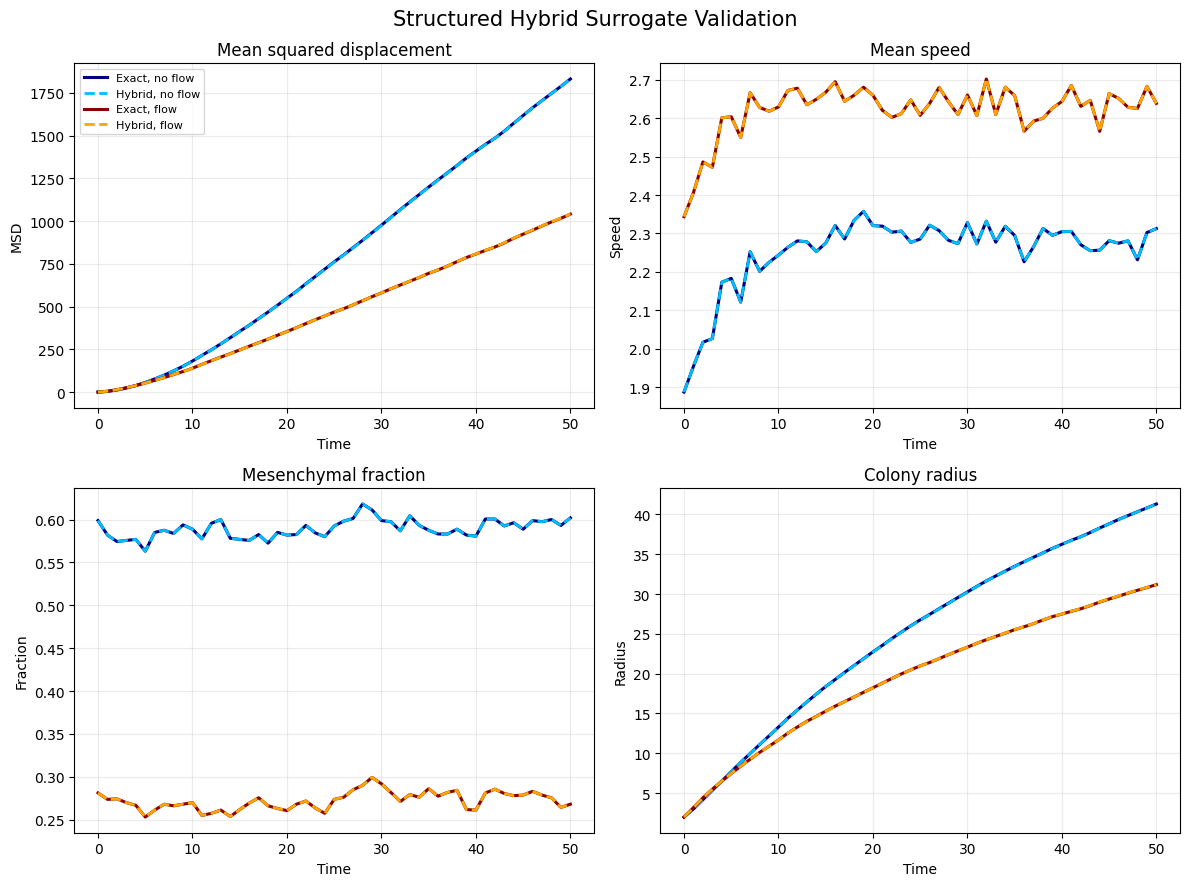

Validation table saved to: outputs/hybrid_colony_validation.csv
Summary saved to: outputs/hybrid_colony_validation.json
Figure saved to: outputs/hybrid_colony_validation.png


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import json


def rollout_time_series(rollout):
    positions = rollout["positions"]
    velocities = rollout["velocities"]
    phenotypes = rollout["phenotypes"]

    displacements = (
        positions
        - positions[0:1]
    )

    msd = np.mean(
        np.sum(
            displacements ** 2,
            axis=-1
        ),
        axis=(1, 2)
    )

    mean_speed = np.mean(
        np.linalg.norm(
            velocities,
            axis=-1
        ),
        axis=(1, 2)
    )

    mesenchymal_fraction = (
        phenotypes.mean(
            axis=(1, 2)
        )
    )

    centers = positions.mean(
        axis=2,
        keepdims=True
    )

    radius = np.sqrt(
        np.mean(
            np.sum(
                (
                    positions
                    - centers
                ) ** 2,
                axis=-1
            ),
            axis=(1, 2)
        )
    )

    return {
        "msd": msd,
        "mean_speed": mean_speed,
        "mesenchymal_fraction":
            mesenchymal_fraction,
        "radius": radius
    }


exact_no_flow_series = rollout_time_series(
    no_flow_exact_rollout
)

hybrid_no_flow_series = rollout_time_series(
    no_flow_surrogate_rollout
)

exact_flow_series = rollout_time_series(
    flow_exact_rollout
)

hybrid_flow_series = rollout_time_series(
    flow_surrogate_rollout
)


saved_frame_count = len(
    exact_no_flow_series["msd"]
)

saved_times = (
    np.arange(saved_frame_count)
    * 20
    * dt
)


# -----------------------------------------
# Save complete time-series table
# -----------------------------------------

validation_table = pd.DataFrame({
    "time": saved_times,

    "exact_no_flow_msd":
        exact_no_flow_series["msd"],

    "hybrid_no_flow_msd":
        hybrid_no_flow_series["msd"],

    "exact_flow_msd":
        exact_flow_series["msd"],

    "hybrid_flow_msd":
        hybrid_flow_series["msd"],

    "exact_no_flow_speed":
        exact_no_flow_series[
            "mean_speed"
        ],

    "hybrid_no_flow_speed":
        hybrid_no_flow_series[
            "mean_speed"
        ],

    "exact_flow_speed":
        exact_flow_series[
            "mean_speed"
        ],

    "hybrid_flow_speed":
        hybrid_flow_series[
            "mean_speed"
        ],

    "exact_no_flow_fraction":
        exact_no_flow_series[
            "mesenchymal_fraction"
        ],

    "hybrid_no_flow_fraction":
        hybrid_no_flow_series[
            "mesenchymal_fraction"
        ],

    "exact_flow_fraction":
        exact_flow_series[
            "mesenchymal_fraction"
        ],

    "hybrid_flow_fraction":
        hybrid_flow_series[
            "mesenchymal_fraction"
        ],

    "exact_no_flow_radius":
        exact_no_flow_series["radius"],

    "hybrid_no_flow_radius":
        hybrid_no_flow_series["radius"],

    "exact_flow_radius":
        exact_flow_series["radius"],

    "hybrid_flow_radius":
        hybrid_flow_series["radius"]
})


validation_csv_path = (
    output_directory
    / "hybrid_colony_validation.csv"
)

validation_table.to_csv(
    validation_csv_path,
    index=False
)


# -----------------------------------------
# Save summary metrics
# -----------------------------------------

final_hybrid_summary = {
    "exact_total_runtime_seconds":
        float(exact_total_runtime),

    "hybrid_total_runtime_seconds":
        float(hybrid_surrogate_runtime),

    "hybrid_to_exact_runtime_ratio":
        float(
            hybrid_surrogate_runtime
            / exact_total_runtime
        ),

    "no_flow": {
        "exact":
            no_flow_exact_summary,
        "hybrid":
            no_flow_surrogate_summary
    },

    "flow": {
        "exact":
            flow_exact_summary,
        "hybrid":
            flow_surrogate_summary
    }
}


summary_json_path = (
    output_directory
    / "hybrid_colony_validation.json"
)

with open(
    summary_json_path,
    "w"
) as summary_file:

    json.dump(
        final_hybrid_summary,
        summary_file,
        indent=2
    )


# -----------------------------------------
# Create the final validation figure
# -----------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)


# MSD
axes[0, 0].plot(
    saved_times,
    exact_no_flow_series["msd"],
    color="navy",
    linewidth=2.2,
    label="Exact, no flow"
)

axes[0, 0].plot(
    saved_times,
    hybrid_no_flow_series["msd"],
    "--",
    color="deepskyblue",
    linewidth=2.0,
    label="Hybrid, no flow"
)

axes[0, 0].plot(
    saved_times,
    exact_flow_series["msd"],
    color="darkred",
    linewidth=2.2,
    label="Exact, flow"
)

axes[0, 0].plot(
    saved_times,
    hybrid_flow_series["msd"],
    "--",
    color="orange",
    linewidth=2.0,
    label="Hybrid, flow"
)

axes[0, 0].set_title(
    "Mean squared displacement"
)

axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("MSD")
axes[0, 0].legend(fontsize=8)


# Speed
axes[0, 1].plot(
    saved_times,
    exact_no_flow_series[
        "mean_speed"
    ],
    color="navy",
    linewidth=2.2
)

axes[0, 1].plot(
    saved_times,
    hybrid_no_flow_series[
        "mean_speed"
    ],
    "--",
    color="deepskyblue",
    linewidth=2.0
)

axes[0, 1].plot(
    saved_times,
    exact_flow_series[
        "mean_speed"
    ],
    color="darkred",
    linewidth=2.2
)

axes[0, 1].plot(
    saved_times,
    hybrid_flow_series[
        "mean_speed"
    ],
    "--",
    color="orange",
    linewidth=2.0
)

axes[0, 1].set_title("Mean speed")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("Speed")


# Phenotype fraction
axes[1, 0].plot(
    saved_times,
    exact_no_flow_series[
        "mesenchymal_fraction"
    ],
    color="navy",
    linewidth=2.2
)

axes[1, 0].plot(
    saved_times,
    hybrid_no_flow_series[
        "mesenchymal_fraction"
    ],
    "--",
    color="deepskyblue",
    linewidth=2.0
)

axes[1, 0].plot(
    saved_times,
    exact_flow_series[
        "mesenchymal_fraction"
    ],
    color="darkred",
    linewidth=2.2
)

axes[1, 0].plot(
    saved_times,
    hybrid_flow_series[
        "mesenchymal_fraction"
    ],
    "--",
    color="orange",
    linewidth=2.0
)

axes[1, 0].set_title(
    "Mesenchymal fraction"
)

axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel("Fraction")


# Colony radius
axes[1, 1].plot(
    saved_times,
    exact_no_flow_series["radius"],
    color="navy",
    linewidth=2.2
)

axes[1, 1].plot(
    saved_times,
    hybrid_no_flow_series["radius"],
    "--",
    color="deepskyblue",
    linewidth=2.0
)

axes[1, 1].plot(
    saved_times,
    exact_flow_series["radius"],
    color="darkred",
    linewidth=2.2
)

axes[1, 1].plot(
    saved_times,
    hybrid_flow_series["radius"],
    "--",
    color="orange",
    linewidth=2.0
)

axes[1, 1].set_title("Colony radius")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Radius")


for axis in axes.ravel():
    axis.grid(
        alpha=0.25
    )

fig.suptitle(
    "Structured Hybrid Surrogate Validation",
    fontsize=15
)

fig.tight_layout()


validation_figure_path = (
    output_directory
    / "hybrid_colony_validation.png"
)

fig.savefig(
    validation_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Validation table saved to:",
    validation_csv_path
)

print(
    "Summary saved to:",
    summary_json_path
)

print(
    "Figure saved to:",
    validation_figure_path
)

In [19]:
# -----------------------------------------
# Final conclusions table
# -----------------------------------------

final_conclusions = pd.DataFrame([
    {
        "component":
            "Probabilistic MLP",

        "intended_use":
            "One-step displacement and velocity prediction",

        "main_result":
            "Accurate one-step prediction with calibrated uncertainty",

        "limitation":
            "Small velocity bias accumulates during recursive rollout",

        "final_status":
            "Retain for one-step prediction and assimilation"
    },

    {
        "component":
            "Structured phenotype head",

        "intended_use":
            "Amoeboid-mesenchymal transition probability",

        "main_result":
            "Reproduces learned no-flow and flow equilibrium fractions",

        "limitation":
            "Requires phenotype or motion information for experimental identification",

        "final_status":
            "Validated"
    },

    {
        "component":
            "Transformer",

        "intended_use":
            "History-based trajectory prediction",

        "main_result":
            "Improved displacement RMSE by about 24 percent and velocity RMSE by about 58 percent over the history baseline",

        "limitation":
            "More computationally expensive and phenotype inference is moderate",

        "final_status":
            "Retain as history-based forecasting model"
    },

    {
        "component":
            "Short-range pair-force MLP",

        "intended_use":
            "Phenotype-dependent cell-cell force approximation",

        "main_result":
            "R-squared 0.99974 with approximately 5 percent colony-force error",

        "limitation":
            "Slower than the optimized vectorized analytical force",

        "final_status":
            "Validated"
    },

    {
        "component":
            "Unconstrained recursive MLP",

        "intended_use":
            "Long multistep colony rollout",

        "main_result":
            "Stable but accumulated excessive speed and MSD",

        "limitation":
            "No-flow MSD error exceeded 100 percent",

        "final_status":
            "Do not use for long rollout"
    },

    {
        "component":
            "Structured hybrid surrogate",

        "intended_use":
            "Stable long-term colony rollout",

        "main_result":
            "Final MSD, speed, radius and phenotype fraction agree with the mechanistic reference within approximately 0.4 percent",

        "limitation":
            "Approximately 8.9 percent slower than the optimized exact vectorized model",

        "final_status":
            "Final recommended rollout model"
    }
])


conclusions_path = (
    output_directory
    / "surrogate_final_conclusions.csv"
)

final_conclusions.to_csv(
    conclusions_path,
    index=False
)


# -----------------------------------------
# Complete final model package
# -----------------------------------------

final_surrogate_package = {
    "package_description":
        (
            "Probabilistic and structured hybrid "
            "surrogate models for cell migration "
            "under interstitial flow"
        ),

    "surrogate_model_state":
        surrogate_model.state_dict(),

    "phenotype_transition_state":
        phenotype_transition_head.state_dict(),

    "transformer_model_state":
        transformer_model.state_dict(),

    "pair_force_model_state":
        pair_force_model.state_dict(),

    "velocity_input_mean":
        velocity_input_mean,

    "velocity_input_std":
        velocity_input_std,

    "target_mean":
        target_mean,

    "target_std":
        target_std,

    "velocity_variance_calibration":
        velocity_variance_calibration,

    "pair_input_mean":
        pair_input_mean,

    "pair_input_std":
        pair_input_std,

    "pair_target_mean":
        pair_target_mean,

    "pair_target_std":
        pair_target_std,

    "dt":
        dt,

    "D":
        D,

    "tau_amoeboid":
        tau_amoeboid,

    "tau_mesenchymal":
        tau_mesenchymal,

    "v_amoeboid":
        v_amoeboid,

    "v_mesenchymal":
        v_mesenchymal,

    "effective_cell_diameter":
        effective_cell_diameter,

    "interaction_range":
        interaction_range,

    "hard_core_stiffness":
        hard_core_stiffness,

    "contact_adhesion_stiffness":
        contact_adhesion_stiffness,

    "cell_mobility":
        surrogate_cell_mobility,

    "transformer_sequence_length":
        int(
            transformer_checkpoint[
                "sequence_length"
            ]
        ),

    "transformer_model_dimension":
        int(
            transformer_checkpoint[
                "model_dimension"
            ]
        ),

    "transformer_number_of_heads":
        int(
            transformer_checkpoint[
                "number_of_heads"
            ]
        ),

    "transformer_number_of_layers":
        int(
            transformer_checkpoint[
                "number_of_layers"
            ]
        ),

    "final_validation": {
        "no_flow_exact":
            no_flow_exact_summary,

        "no_flow_hybrid":
            no_flow_surrogate_summary,

        "flow_exact":
            flow_exact_summary,

        "flow_hybrid":
            flow_surrogate_summary,

        "exact_runtime_seconds":
            float(exact_total_runtime),

        "hybrid_runtime_seconds":
            float(hybrid_surrogate_runtime),

        "hybrid_to_exact_runtime_ratio":
            float(
                hybrid_surrogate_runtime
                / exact_total_runtime
            )
    },

    "recommended_usage": {
        "one_step_prediction":
            "ProbabilisticSurrogateMLP",

        "history_based_prediction":
            "ProbabilisticTransitionTransformer",

        "phenotype_transition":
            "StructuredPhenotypeTransitionHead",

        "pair_force":
            "ShortRangePairForceMLP",

        "long_rollout":
            "Structured hybrid physics plus learned pair force"
    }
}


final_checkpoint_path = (
    output_directory
    / "final_hybrid_surrogate_package.pt"
)

torch.save(
    final_surrogate_package,
    final_checkpoint_path
)


# -----------------------------------------
# Verify the saved package
# -----------------------------------------

reloaded_final_package = torch.load(
    final_checkpoint_path,
    map_location="cpu"
)

print(
    "Conclusions saved to:",
    conclusions_path
)

print(
    "Final checkpoint saved to:",
    final_checkpoint_path
)

print(
    "Saved package keys:",
    list(
        reloaded_final_package.keys()
    )
)

print(
    "Recommended long-rollout model:",
    reloaded_final_package[
        "recommended_usage"
    ]["long_rollout"]
)

print(
    "Checkpoint exists:",
    final_checkpoint_path.exists()
)

print(
    "Conclusions file exists:",
    conclusions_path.exists()
)

Conclusions saved to: outputs/surrogate_final_conclusions.csv
Final checkpoint saved to: outputs/final_hybrid_surrogate_package.pt
Saved package keys: ['package_description', 'surrogate_model_state', 'phenotype_transition_state', 'transformer_model_state', 'pair_force_model_state', 'velocity_input_mean', 'velocity_input_std', 'target_mean', 'target_std', 'velocity_variance_calibration', 'pair_input_mean', 'pair_input_std', 'pair_target_mean', 'pair_target_std', 'dt', 'D', 'tau_amoeboid', 'tau_mesenchymal', 'v_amoeboid', 'v_mesenchymal', 'effective_cell_diameter', 'interaction_range', 'hard_core_stiffness', 'contact_adhesion_stiffness', 'cell_mobility', 'transformer_sequence_length', 'transformer_model_dimension', 'transformer_number_of_heads', 'transformer_number_of_layers', 'final_validation', 'recommended_usage']
Recommended long-rollout model: Structured hybrid physics plus learned pair force
Checkpoint exists: True
Conclusions file exists: True


## Final conclusions

- The probabilistic MLP produced accurate one-step predictions and calibrated uncertainty, but small velocity bias accumulated in long recursive rollouts.
- The transformer improved displacement RMSE by about 24% and velocity RMSE by about 58% relative to a simple history baseline.
- The pair-force MLP achieved an R-squared of 0.99974 and approximately 5% relative cell-force error.
- The structured hybrid surrogate reproduced final phenotype fraction, speed, MSD, colony radius, nearest-neighbor distance, and excluded volume within approximately 0.4% of the mechanistic reference.
- The hybrid was approximately 8.9% slower than the optimized vectorized analytical solver for this small system. Its advantage is therefore structural flexibility and differentiability, not raw speed in the present benchmark.
- The principal methodological lesson is that strong one-step accuracy does not guarantee stable recursive simulation; known kinematic and stochastic structure should be retained when possible.
